# 📘 Session 2: Playing Style & Role Representations

## 🎯 Learning Objectives

By the end of this module, participants should be able to:

- Aggregate event + tracking data into possession-level features.

- Understand dimensionality reduction (PCA, t-SNE, UMAP) to create tactical embeddings.

- Perform clustering to identify team playing styles.

- Build player-level profiles (roles, heatmaps, embeddings).

- Link playing style analysis to defensive structure insights (Session 1).

In [2]:
import pandas as pd
import json
from pathlib import Path

BASE_DIR = Path("/Users/pegra441/Desktop/twelve-deep-learning/PremierLeague_data/2024")
DYNAMIC_DIR = BASE_DIR / "dynamic"
META_DIR = BASE_DIR / "meta"

records = []

# Loop through dynamic files
for fpath in DYNAMIC_DIR.glob("*.parquet"):
    match_id = int(fpath.stem)  # filename without extension

    # Try to load meta JSON for team names
    meta_path = META_DIR / f"{match_id}.json"
    if meta_path.exists():
        with open(meta_path, "r") as f:
            meta = json.load(f)
        home_team = meta["home_team"]["name"]
        away_team = meta["away_team"]["name"]
    else:
        home_team, away_team = None, None

    records.append({
        "id": match_id,
        "home_team": home_team,
        "away_team": away_team
    })

# Build DataFrame
df_matches = pd.DataFrame(records)

# Save as parquet
df_matches.to_parquet(BASE_DIR / "matches.parquet", index=False)

print("✅ matches.parquet created with shape:", df_matches.shape)
df_matches.head()


✅ matches.parquet created with shape: (378, 3)


,id,home_team,away_team
0,1986708,Crystal Palace,Brentford FC
1,1715920,Tottenham Hotspur,Arsenal Football Club
2,2015001,West Ham United,Tottenham Hotspur
3,1650385,Manchester United,Fulham
4,2007863,Leicester City,Manchester United


In [4]:
df_matches.shape

(378, 3)

In [155]:
import os, json
import pandas as pd
import numpy as np
from pathlib import Path

# --- Paths ---
BASE_DIR = Path("/Users/pegra441/Desktop/twelve-deep-learning/PremierLeague_data/2024")
DYNAMIC_DIR = BASE_DIR / "dynamic"
META_DIR = BASE_DIR / "meta"
TRACKING_DIR = BASE_DIR / "tracking"

# Pitch constants (SkillCorner → FIFA/mplsoccer scale)
X_MIN, X_MAX = -52, 52
Y_MIN, Y_MAX = -34, 34
PITCH_LENGTH, PITCH_WIDTH = 105, 68

# =====================================================
# Step 1. Build matches.parquet (if missing)
# =====================================================
matches_file = BASE_DIR / "matches.parquet"
if not matches_file.exists():
    records = []
    for fpath in DYNAMIC_DIR.glob("*.parquet"):
        match_id = int(fpath.stem)
        # Try to enrich with meta
        meta_path = META_DIR / f"{match_id}.json"
        if meta_path.exists():
            with open(meta_path, "r") as f:
                meta = json.load(f)
            home_team = meta["home_team"]["name"]
            away_team = meta["away_team"]["name"]
        else:
            home_team, away_team = None, None
        records.append({"id": match_id, "home_team": home_team, "away_team": away_team})
    df_matches = pd.DataFrame(records)
    df_matches.to_parquet(matches_file, index=False)
    print(f"✅ Built matches.parquet with {len(df_matches)} matches")
else:
    df_matches = pd.read_parquet(matches_file)
    print(f"✅ Loaded matches.parquet with {len(df_matches)} matches")

# =====================================================
# Step 2. Helper: rescale coords
# =====================================================
def rescale_to_pitch(df,
                     x_min=X_MIN, x_max=X_MAX,
                     y_min=Y_MIN, y_max=Y_MAX,
                     target_x=PITCH_LENGTH, target_y=PITCH_WIDTH):
    df = df.copy()
    df["x_rescaled"] = (df["x"] - x_min) / (x_max - x_min) * target_x
    df["y_rescaled"] = (df["y"] - y_min) / (y_max - y_min) * target_y
    if "x_end" in df.columns and "y_end" in df.columns:
        df["x_end_rescaled"] = (df["x_end"] - x_min) / (x_max - x_min) * target_x
        df["y_end_rescaled"] = (df["y_end"] - y_min) / (y_max - y_min) * target_y
    return df

# =====================================================
# Step 3. Helper: load meta mapping
# =====================================================
def load_meta_mapping(match_id: int):
    fpath = META_DIR / f"{match_id}.json"
    if not fpath.exists():
        return pd.DataFrame()

    with open(fpath, "r") as f:
        meta = json.load(f)

    home_team, away_team = meta["home_team"], meta["away_team"]
    records = []
    for p in meta.get("players", []):
        if "id" not in p:
            continue
        team_name = home_team["name"] if p["team_id"] == home_team["id"] else away_team["name"]
        team_shortname = home_team["short_name"] if p["team_id"] == home_team["id"] else away_team["short_name"]

        records.append({
            "match_id": meta["id"],
            "player_id_meta": p["id"],
            "player_short_name": p.get("short_name"),
            "player_team_id": p["team_id"],
            "player_team_name": team_name,
            "player_team_shortname": team_shortname,
            "player_position_group": p["player_role"]["position_group"] if p.get("player_role") else None,
            "player_role": p["player_role"]["name"] if p.get("player_role") else None
        })
    return pd.DataFrame(records)

# =====================================================
# Step 4. Build freeze frames for all matches
# =====================================================
all_freeze_frames = []

for match_id in df_matches["id"].values:
    # Load events
    try:
        df_events = pd.read_parquet(DYNAMIC_DIR / f"{match_id}.parquet")
    except:
        print(f"⚠️ No events for match {match_id}")
        continue

    # Only possession events
    df_events_pos = df_events[df_events["event_type"] == "player_possession"]

    # Event columns we care about
    df_events_end = df_events_pos[[
        "event_id","match_id","frame_start","frame_end",
        "time_start","time_end","team_id","attacking_side",
        "player_id","player_name","team_shortname",
        "start_type","end_type","x_start","y_start","x_end","y_end"
    ]]

    # Load tracking JSON
    fpath = TRACKING_DIR / f"{match_id}.json"
    if not fpath.exists():
        print(f"⚠️ No tracking for match {match_id}")
        continue
    with open(fpath, "r") as f:
        tracking_data = json.load(f)

    # Collect freeze frames
    frames = set(df_events_end["frame_start"].to_list() + df_events_end["frame_end"].to_list())
    custom_data = []
    for d in tracking_data:
        if d.get("frame") in frames and d.get("timestamp") is not None:
            for p in d["player_data"]:
                custom_data.append({
                    "match_id": match_id,
                    "time": d.get("timestamp"),
                    "frame": int(d.get("frame")),
                    "period": d.get("period"),
                    "player_id_tracking": p.get("player_id"),
                    "is_detected": p.get("is_detected"),
                    "is_ball": False,
                    "x": p.get("x"),
                    "y": p.get("y")
                })
            # Ball
            ball = d.get("ball_data")
            if ball and ball.get("is_detected") is not None:
                custom_data.append({
                    "match_id": match_id,
                    "time": d.get("timestamp"),
                    "frame": int(d.get("frame")),
                    "period": d.get("period"),
                    "player_id_tracking": -1,
                    "is_detected": ball.get("is_detected"),
                    "is_ball": True,
                    "x": ball.get("x"),
                    "y": ball.get("y")
                })

    df_frames = pd.DataFrame(custom_data)

    # Merge with events
    df_freeze = df_frames.merge(
        df_events_end,
        left_on=["match_id","frame"],
        right_on=["match_id","frame_end"],
        how="inner"
    ).rename(columns={"player_id": "player_id_event"})

    # Merge with meta
    df_meta = load_meta_mapping(match_id)
    if not df_meta.empty:
        df_freeze = df_freeze.merge(
            df_meta,
            left_on=["match_id","player_id_tracking"],
            right_on=["match_id","player_id_meta"],
            how="left"
        )

    # Rescale
    df_freeze = rescale_to_pitch(df_freeze)

    all_freeze_frames.append(df_freeze)

# =====================================================
# Step 5. Final dataset
# =====================================================
if all_freeze_frames:
    df_freeze_start_enriched = pd.concat(all_freeze_frames, ignore_index=True)
else:
    df_freeze_start_enriched = pd.DataFrame()

print("✅ Final freeze-frame shape:", df_freeze_start_enriched.shape)
df_freeze_start_enriched.head()


✅ Loaded matches.parquet with 378 matches
✅ Final freeze-frame shape: (8329949, 36)


,match_id,time,frame,period,player_id_tracking,is_detected,is_ball,x,y,event_id,...,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled
0,1986708,00:00:00.10,11,1,18526,False,False,-37.88,-0.79,8_0,...,D. Henderson,60.0,Crystal Palace,Crystal Palace,Other,Goalkeeper,14.255769,33.21,52.681731,34.21
1,1986708,00:00:00.10,11,1,12993,True,False,-16.39,-7.28,8_0,...,M. Lacroix,60.0,Crystal Palace,Crystal Palace,Central Defender,Center Back,35.952404,26.72,52.681731,34.21
2,1986708,00:00:00.10,11,1,25828,True,False,-7.98,-14.18,8_0,...,C. Richards,60.0,Crystal Palace,Crystal Palace,Central Defender,Right Center Back,44.443269,19.82,52.681731,34.21
3,1986708,00:00:00.10,11,1,23841,True,False,-12.22,5.27,8_0,...,M. Guéhi,60.0,Crystal Palace,Crystal Palace,Central Defender,Left Center Back,40.162500,39.27,52.681731,34.21
4,1986708,00:00:00.10,11,1,32267,True,False,-3.57,-24.64,8_0,...,D. Muñoz,60.0,Crystal Palace,Crystal Palace,Full Back,Right Wing Back,48.895673,9.36,52.681731,34.21


In [3]:
df_freeze_start_enriched.to_parquet('/Users/pegra441/Desktop/twelve-deep-learning/PremierLeague_data/Pl_freeze_frames.parquet')

In [4]:
df_freeze_start_enriched.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id_tracking',
       'is_detected', 'is_ball', 'x', 'y', 'event_id', 'frame_start',
       'frame_end', 'time_start', 'time_end', 'team_id', 'attacking_side',
       'player_id_event', 'player_name', 'team_shortname', 'start_type',
       'end_type', 'x_start', 'y_start', 'x_end', 'y_end', 'player_id_meta',
       'player_short_name', 'player_team_id', 'player_team_name',
       'player_team_shortname', 'player_position_group', 'player_role',
       'x_rescaled', 'y_rescaled', 'x_end_rescaled', 'y_end_rescaled'],
      dtype='object')

In [5]:
df_freeze_start_enriched.team_shortname.value_counts()

team_shortname
Manchester City    551923
Liverpool          492817
Chelsea            483003
Manchester U       463979
Arsenal            463354
Fulham             448253
Tottenham          445795
Brighton           435846
Newcastle          423659
Southampton        420027
West Ham           415915
Aston Villa        403989
Wolverhampton      390134
Leicester          387762
Brentford FC       385502
Bournemouth        363189
Crystal Palace     359219
Everton            340576
Ipswich Town       336536
Nottingham         318471
Name: count, dtype: int64

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [7]:
# Load the dataset built in Session 1
df = df_freeze_start_enriched.copy()

print("Shape:", df.shape)
df.head()


Shape: (8329949, 36)


,match_id,time,frame,period,player_id_tracking,is_detected,is_ball,x,y,event_id,...,player_short_name,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled
0,1986708,00:00:00.10,11,1,18526,False,False,-37.88,-0.79,8_0,...,D. Henderson,60.0,Crystal Palace,Crystal Palace,Other,Goalkeeper,14.255769,33.21,52.681731,34.21
1,1986708,00:00:00.10,11,1,12993,True,False,-16.39,-7.28,8_0,...,M. Lacroix,60.0,Crystal Palace,Crystal Palace,Central Defender,Center Back,35.952404,26.72,52.681731,34.21
2,1986708,00:00:00.10,11,1,25828,True,False,-7.98,-14.18,8_0,...,C. Richards,60.0,Crystal Palace,Crystal Palace,Central Defender,Right Center Back,44.443269,19.82,52.681731,34.21
3,1986708,00:00:00.10,11,1,23841,True,False,-12.22,5.27,8_0,...,M. Guéhi,60.0,Crystal Palace,Crystal Palace,Central Defender,Left Center Back,40.162500,39.27,52.681731,34.21
4,1986708,00:00:00.10,11,1,32267,True,False,-3.57,-24.64,8_0,...,D. Muñoz,60.0,Crystal Palace,Crystal Palace,Full Back,Right Wing Back,48.895673,9.36,52.681731,34.21


In [8]:
# Group events by possession_id
# (if you don’t have possession_id, you can reconstruct from event sequence)
if "possession_id" in df.columns:
    df_possessions = df.groupby(["match_id", "possession_id"]).agg({
        "event_id": "count",
        "x_start": "first",
        "y_start": "first",
        "x_end": "last",
        "y_end": "last",
        "frame_start": "min",
        "frame_end": "max",
        "team_id": "first",
        "player_team_name": "first"
    }).reset_index()
else:
    print("⚠️ possession_id not found — use event grouping rules instead")


⚠️ possession_id not found — use event grouping rules instead


## ⚽️ Tutorial: Building Possessions from Events

We’ll work on the events table, not freeze-frames, because possession boundaries are event-based.

👉 The general rule you suggested:

A possession continues until the opponent team performs ≥2 consecutive actions.

That break → a new possession starts.


In [9]:
import pandas as pd
from pathlib import Path

DYNAMIC_DIR = Path("/Users/pegra441/Desktop/twelve-deep-learning/PremierLeague_data/2024/dynamic")

# Example: load all events into one big DataFrame
all_events = []
for f in DYNAMIC_DIR.glob("*.parquet"):
    df = pd.read_parquet(f)
    df["match_id"] = int(f.stem)
    all_events.append(df)

df_events_all = pd.concat(all_events, ignore_index=True)
print("All events:", df_events_all.shape)


All events: (1811078, 294)


In [10]:
# Step 2. Sort Events in Time
df_events_all = df_events_all.sort_values(
    ["match_id", "period", "frame_start"]
).reset_index(drop=True)


# Step 3. Construct Possession IDs
def assign_possessions(events_df):
    events_df = events_df.copy()
    possession_ids = []
    current_possession = 0
    last_team = None
    opponent_count = 0

    for idx, row in events_df.iterrows():
        team = row["team_id"]

        if last_team is None:
            # Start first possession
            current_possession += 1
            possession_ids.append(current_possession)
            last_team = team
            opponent_count = 0
            continue

        if team == last_team:
            # Same team continues possession
            possession_ids.append(current_possession)
            opponent_count = 0
        else:
            # Opponent action
            opponent_count += 1
            if opponent_count >= 2:
                # Switch possession
                current_possession += 1
                possession_ids.append(current_possession)
                last_team = team
                opponent_count = 0
            else:
                # Still count as previous possession
                possession_ids.append(current_possession)

    events_df["possession_id"] = possession_ids
    return events_df

df_events_all = df_events_all.groupby("match_id", group_keys=False).apply(assign_possessions)


/var/folders/3f/yft_5njd2yg67wbblcdlff800000gn/T/ipykernel_93121/3007072774.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_events_all = df_events_all.groupby("match_id", group_keys=False).apply(assign_possessions)


In [12]:
df_events_all[["match_id","period","frame_start","team_id","team_shortname","event_type","possession_id"]].head(30)


,match_id,period,frame_start,team_id,team_shortname,event_type,possession_id
0,1650385,1,52,48,Fulham,player_possession,1
1,1650385,1,59,48,Fulham,off_ball_run,1
2,1650385,1,62,48,Fulham,player_possession,1
3,1650385,1,62,48,Fulham,passing_option,1
4,1650385,1,62,31,Manchester U,on_ball_engagement,1
5,1650385,1,66,48,Fulham,passing_option,1
6,1650385,1,69,48,Fulham,passing_option,1
7,1650385,1,71,48,Fulham,passing_option,1
8,1650385,1,87,48,Fulham,player_possession,1
9,1650385,1,87,48,Fulham,passing_option,1


In [13]:
df_freeze_start_enriched = df_freeze_start_enriched.merge(
    df_events_all[["match_id","event_id","possession_id"]],
    on=["match_id","event_id"], how="left"
)



# 📘 Tutorial Notebook: Playing Style & Role Representations

In [27]:
# 0. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

In [28]:
# 1. Load Freeze-Frame Data with Possession IDs
# Suppose df_freeze_start_enriched is already built from Session 1
# and now includes a possession_id column.
df = df_freeze_start_enriched.copy()

print("Shape:", df.shape)
df.head()

Shape: (8329949, 37)


,match_id,time,frame,period,player_id_tracking,is_detected,is_ball,x,y,event_id,...,player_team_id,player_team_name,player_team_shortname,player_position_group,player_role,x_rescaled,y_rescaled,x_end_rescaled,y_end_rescaled,possession_id
0,1986708,00:00:00.10,11,1,18526,False,False,-37.88,-0.79,8_0,...,60.0,Crystal Palace,Crystal Palace,Other,Goalkeeper,14.255769,33.21,52.681731,34.21,1
1,1986708,00:00:00.10,11,1,12993,True,False,-16.39,-7.28,8_0,...,60.0,Crystal Palace,Crystal Palace,Central Defender,Center Back,35.952404,26.72,52.681731,34.21,1
2,1986708,00:00:00.10,11,1,25828,True,False,-7.98,-14.18,8_0,...,60.0,Crystal Palace,Crystal Palace,Central Defender,Right Center Back,44.443269,19.82,52.681731,34.21,1
3,1986708,00:00:00.10,11,1,23841,True,False,-12.22,5.27,8_0,...,60.0,Crystal Palace,Crystal Palace,Central Defender,Left Center Back,40.162500,39.27,52.681731,34.21,1
4,1986708,00:00:00.10,11,1,32267,True,False,-3.57,-24.64,8_0,...,60.0,Crystal Palace,Crystal Palace,Full Back,Right Wing Back,48.895673,9.36,52.681731,34.21,1


In [29]:
#2. Build Possession-Level Table

#Each possession = sequence of events until ball lost (we already computed possession_id).
#Now we aggregate possession features.

# Aggregate to possession level
df_possessions = (
    df.groupby(["match_id","possession_id","player_team_name"])
    .agg({
        "frame_start": "min",
        "frame_end": "max",
        "time_start": "min",
        "time_end": "max",
        "x_start": "first",
        "y_start": "first",
        "x_end": "last",
        "y_end": "last",
        "event_id": "count"  # number of events in possession
    })
    .reset_index()
)

# Basic possession features
df_possessions["duration_frames"] = df_possessions["frame_end"] - df_possessions["frame_start"]
df_possessions["net_progress_x"] = df_possessions["x_end"] - df_possessions["x_start"]
df_possessions["net_progress_y"] = df_possessions["y_end"] - df_possessions["y_start"]
df_possessions["progress_distance"] = np.sqrt(
    df_possessions["net_progress_x"]**2 + df_possessions["net_progress_y"]**2
)

print("Possessions:", df_possessions.shape)
df_possessions.head()

Possessions: (231146, 16)


,match_id,possession_id,player_team_name,frame_start,frame_end,time_start,time_end,x_start,y_start,x_end,y_end,event_id,duration_frames,net_progress_x,net_progress_y,progress_distance
0,1650385,1,Fulham,52,182,00:04.2,00:17.2,0.37,-0.51,-13.67,32.22,55,130,-14.04,32.73,35.614246
1,1650385,1,Manchester United,52,182,00:04.2,00:17.2,0.37,-0.51,-13.67,32.22,55,130,-14.04,32.73,35.614246
2,1650385,3,Fulham,189,196,00:17.9,00:18.6,-5.78,33.63,-3.84,34.11,11,7,1.94,0.48,1.998499
3,1650385,3,Manchester United,189,196,00:17.9,00:18.6,-5.78,33.63,-3.84,34.11,11,7,1.94,0.48,1.998499
4,1650385,4,Fulham,222,968,00:21.2,01:35.8,-9.24,18.66,2.38,32.24,121,746,11.62,13.58,17.872907


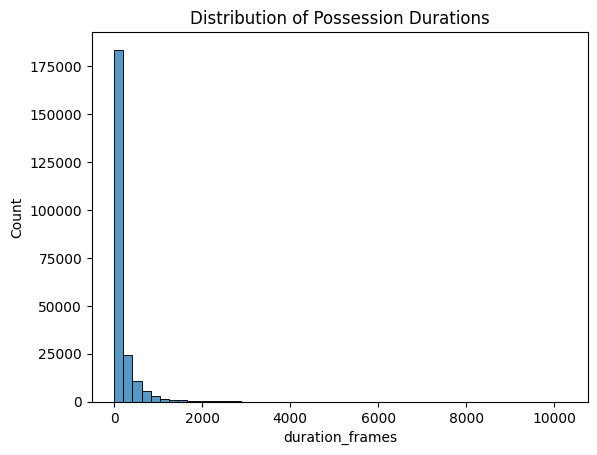

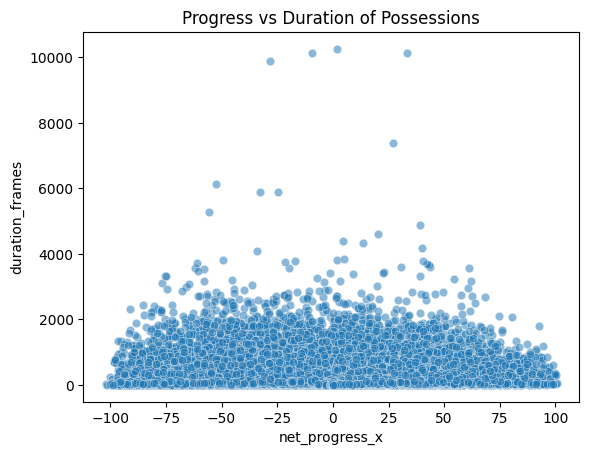

In [30]:
#3. Explore Possession Features
sns.histplot(df_possessions["duration_frames"], bins=50)
plt.title("Distribution of Possession Durations")
plt.show()

sns.scatterplot(data=df_possessions, x="net_progress_x", y="duration_frames", alpha=0.3)
plt.title("Progress vs Duration of Possessions")
plt.show()

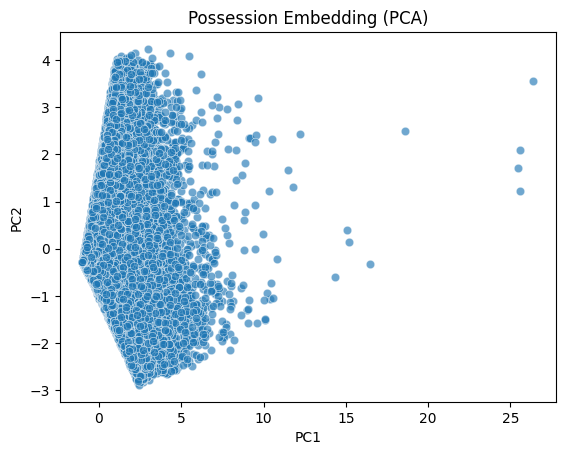

In [31]:
# 4. Dimensionality Reduction (PCA)
features = ["duration_frames","progress_distance","net_progress_x"]
X = df_possessions[features].fillna(0)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_possessions["PC1"] = X_pca[:,0]
df_possessions["PC2"] = X_pca[:,1]

sns.scatterplot(data=df_possessions, x="PC1", y="PC2", alpha=0.4)
plt.title("Possession Embedding (PCA)")
plt.show()

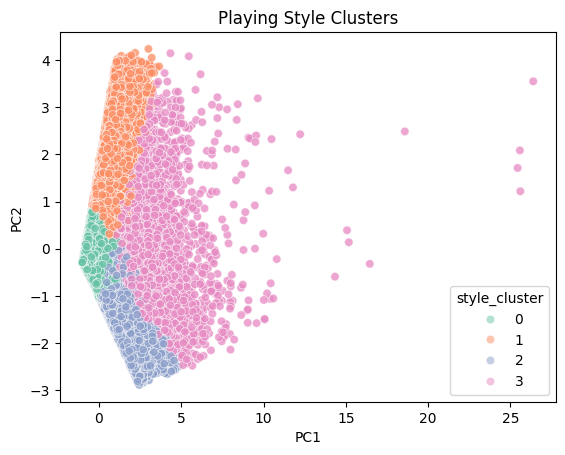

In [32]:
# 5. Cluster Playing Styles
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
df_possessions["style_cluster"] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=df_possessions, x="PC1", y="PC2", hue="style_cluster", palette="Set2", alpha=0.5)
plt.title("Playing Style Clusters")
plt.show()

## 👉 At this point, we see distinct possession clusters.

- Cluster 0 → Direct transitions

- Cluster 1 → Tiki-taka buildup

- Cluster 2 → High press recoveries

- Cluster 3 → Chaotic turnovers

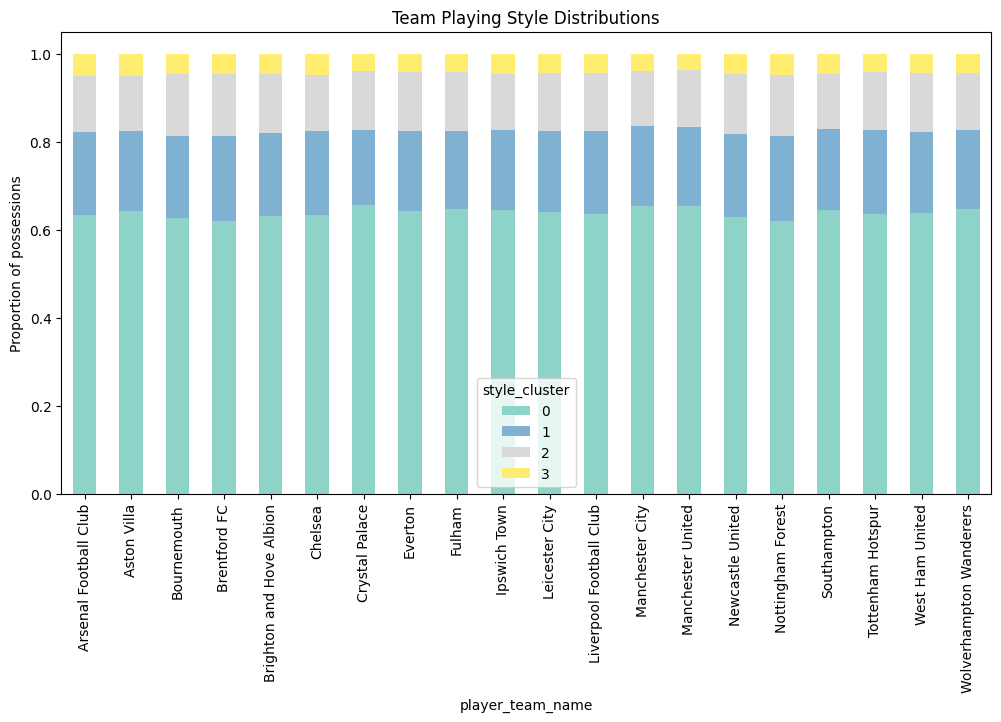

In [33]:
# 6. Team-Level Style Fingerprints
team_styles = (
    df_possessions.groupby("player_team_name")["style_cluster"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

team_styles.plot(kind="bar", stacked=True, figsize=(12,6), colormap="Set3")
plt.title("Team Playing Style Distributions")
plt.ylabel("Proportion of possessions")
plt.show()

## 👉 Compare how Arsenal vs Newcastle vs Man City differ in style mix.

In [35]:
df_possessions

,match_id,possession_id,player_team_name,frame_start,frame_end,time_start,time_end,x_start,y_start,x_end,y_end,event_id,duration_frames,net_progress_x,net_progress_y,progress_distance,PC1,PC2,style_cluster
0,1650385,1,Fulham,52,182,00:04.2,00:17.2,0.37,-0.51,-13.67,32.22,55,130,-14.04,32.73,35.614246,0.375903,-0.435017,0
1,1650385,1,Manchester United,52,182,00:04.2,00:17.2,0.37,-0.51,-13.67,32.22,55,130,-14.04,32.73,35.614246,0.375903,-0.435017,0
2,1650385,3,Fulham,189,196,00:17.9,00:18.6,-5.78,33.63,-3.84,34.11,11,7,1.94,0.48,1.998499,-0.954003,-0.202699,0
3,1650385,3,Manchester United,189,196,00:17.9,00:18.6,-5.78,33.63,-3.84,34.11,11,7,1.94,0.48,1.998499,-0.954003,-0.202699,0
4,1650385,4,Fulham,222,968,00:21.2,01:35.8,-9.24,18.66,2.38,32.24,121,746,11.62,13.58,17.872907,1.294684,0.421718,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231141,2018580,383,Wolverhampton Wanderers,57042,57073,93:30.2,93:33.3,-47.64,0.51,-42.01,-3.85,11,31,5.63,-4.36,7.120850,-0.780019,-0.027383,0
231142,2018580,384,Brentford FC,57090,57115,93:35.0,93:37.5,25.80,18.03,32.97,24.20,11,25,7.17,6.17,9.459271,-0.742906,0.044103,0
231143,2018580,384,Wolverhampton Wanderers,57090,57115,93:35.0,93:37.5,25.80,18.03,32.97,24.20,11,25,7.17,6.17,9.459271,-0.742906,0.044103,0
231144,2018580,385,Brentford FC,57536,57540,94:19.6,94:20.0,48.52,-7.48,-50.05,1.47,22,4,-98.57,8.95,98.975489,2.342612,-2.810831,2


Guarantee Player-Level Info in df_possessions
Step 1. When aggregating possessions, include player info

Instead of only aggregating numeric features, also grab the player columns (player_id_event, player_name, team_shortname).

In [37]:
# Aggregate possessions with possessor info
df_possessions = (
    df.groupby(["match_id","possession_id"])
    .agg({
        "frame_start": "min",
        "frame_end": "max",
        "time_start": "min",
        "time_end": "max",
        "x_start": "first",
        "y_start": "first",
        "x_end": "last",
        "y_end": "last",
        "event_id": "count",
        # possessor info (take first event of possession)
        "player_id_event": "first",
        "player_name": "first",
        "team_shortname": "first",
        "player_team_name": "first"
    })
    .reset_index()
)

# Features
df_possessions["duration_frames"] = df_possessions["frame_end"] - df_possessions["frame_start"]
df_possessions["net_progress_x"] = df_possessions["x_end"] - df_possessions["x_start"]
df_possessions["net_progress_y"] = df_possessions["y_end"] - df_possessions["y_start"]
df_possessions["progress_distance"] = np.sqrt(
    df_possessions["net_progress_x"]**2 + df_possessions["net_progress_y"]**2
)

print("Possessions:", df_possessions.shape)
df_possessions.head()



Possessions: (115573, 19)


,match_id,possession_id,frame_start,frame_end,time_start,time_end,x_start,y_start,x_end,y_end,event_id,player_id_event,player_name,team_shortname,player_team_name,duration_frames,net_progress_x,net_progress_y,progress_distance
0,1650385,1,52,182,00:04.2,00:17.2,0.37,-0.51,-13.67,32.22,115,11438,Andreas Pereira,Fulham,Manchester United,130,-14.04,32.73,35.614246
1,1650385,3,189,196,00:17.9,00:18.6,-5.78,33.63,-3.84,34.11,23,6847,M. Rashford,Manchester U,Manchester United,7,1.94,0.48,1.998499
2,1650385,4,222,968,00:21.2,01:35.8,-9.24,18.66,2.38,32.24,253,1674,Casemiro,Manchester U,Manchester United,746,11.62,13.58,17.872907
3,1650385,5,981,981,01:37.1,01:37.1,0.87,24.34,0.87,24.34,23,70672,K. Mainoo,Manchester U,Manchester United,0,0.00,0.00,0.000000
4,1650385,6,991,1692,01:38.1,02:48.2,-2.87,31.57,19.05,-9.08,414,6847,M. Rashford,Manchester U,Manchester United,701,21.92,-40.65,46.183427


In [38]:
#Step 2. Player Role Embeddings

#We can now group by player_name safely:

# Features to describe playing style
features = ["duration_frames", "progress_distance", "net_progress_x"]

player_roles = (
    df_possessions.groupby("player_name")[features]
    .mean()
    .fillna(0)
)

print("Player embeddings:", player_roles.shape)
player_roles.head()

Player embeddings: (548, 3)


,duration_frames,progress_distance,net_progress_x
player_name,,,
A. Agbinone,92.400000,20.258649,-6.698000
A. Armstrong,118.652174,18.687584,-1.630696
A. Aréola,194.298507,32.826605,25.434080
A. Bayındır,184.741935,43.428301,38.129032
A. Bella-Kotchap,159.467742,27.447237,8.634677


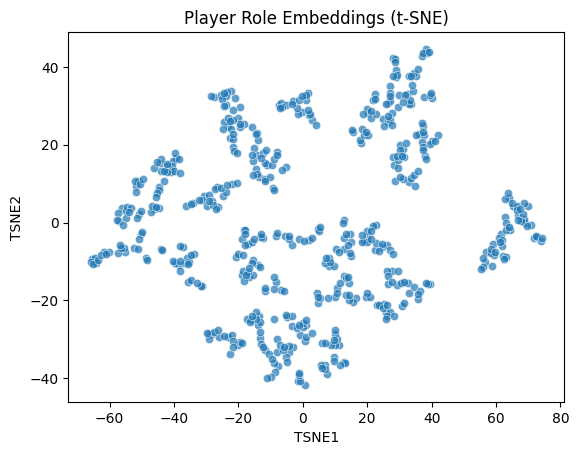

In [39]:
# Step 3. Proceed with Role Embedding & Similarity

# Now you can continue with PCA, t-SNE, cosine similarity, etc., exactly as in the tutorial:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

# Scale
X_scaled = StandardScaler().fit_transform(player_roles)

# t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
X_tsne = tsne.fit_transform(X_scaled)

player_roles["TSNE1"] = X_tsne[:,0]
player_roles["TSNE2"] = X_tsne[:,1]

sns.scatterplot(data=player_roles, x="TSNE1", y="TSNE2", alpha=0.7)
plt.title("Player Role Embeddings (t-SNE)")
plt.show()

👉 Each dot = player → clusters of similar roles.

In [40]:
# And the similarity search stays the same:

sim_matrix = cosine_similarity(X_scaled)
sim_df = pd.DataFrame(sim_matrix, index=player_roles.index, columns=player_roles.index)

def find_similar_players(player_name, top_n=5):
    if player_name not in sim_df.index:
        print(f"⚠️ {player_name} not found")
        return
    return sim_df[player_name].sort_values(ascending=False).iloc[1:top_n+1]

In [43]:
# 9. Similarity Search (Scouting Example)
sim_matrix = cosine_similarity(X_scaled)
sim_df = pd.DataFrame(sim_matrix, index=player_roles.index, columns=player_roles.index)

def find_similar_players(player_name, top_n=5):
    if player_name not in sim_df.index:
        print(f"⚠️ {player_name} not found")
        return
    sims = sim_df[player_name].sort_values(ascending=False).iloc[1:top_n+1]
    return sims

In [ ]:
# 10. Example: Find Similar Players to Rodri
similar_to_rodri = find_similar_players("Rodri", top_n=5)
print("Most similar players to Rodri:")
print(similar_to_rodri)


Most similar players to Rodri:
player_name
M. Harness     0.996872
D. Scarlett    0.994411
J. Monga       0.990974
Y. Konak       0.987590
C. Obi         0.984706
Name: Rodri, dtype: float64


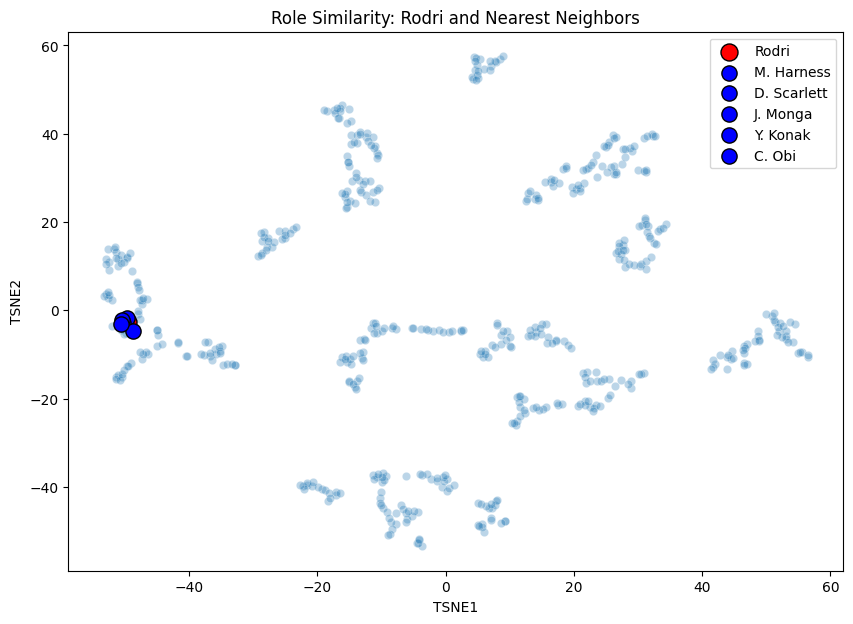

In [45]:
# 11. Visualization of Player + Neighbors
target = "Rodri"
neighbors = list(similar_to_rodri.index)

plt.figure(figsize=(10,7))
sns.scatterplot(data=player_roles, x="TSNE1", y="TSNE2", alpha=0.3)

# Highlight target
plt.scatter(player_roles.loc[target,"TSNE1"], player_roles.loc[target,"TSNE2"],
            color="red", s=150, edgecolors="k", label=target)

# Highlight neighbors
for n in neighbors:
    plt.scatter(player_roles.loc[n,"TSNE1"], player_roles.loc[n,"TSNE2"],
                color="blue", s=120, edgecolors="k", label=n)

plt.title(f"Role Similarity: {target} and Nearest Neighbors")
plt.legend()
plt.show()


12. Wrap-Up

Possessions → Playing Styles → Team Style Mix → Player Roles.

Similarity search = data-driven scouting.

Next steps:

Define role archetypes (playmaker, destroyer, winger, striker).

Track role changes across matches/seasons.

Compare opponent-specific adjustments.

# 🔥 Extension: Role Archetype Clustering

In [46]:
# 13. Clustering Players into Role Archetypes

# We use the same player_roles table (averaged possession features per player).

from sklearn.cluster import KMeans

# Features only (exclude TSNE coords)
role_features = ["duration_frames", "progress_distance", "net_progress_x"]

X_scaled = StandardScaler().fit_transform(player_roles[role_features])

# KMeans clustering
kmeans_roles = KMeans(n_clusters=6, random_state=42, n_init="auto")
player_roles["role_cluster"] = kmeans_roles.fit_predict(X_scaled)

In [47]:
# 14. Inspect Role Archetypes
role_summary = player_roles.groupby("role_cluster")[role_features].mean().round(2)
print(role_summary)

              duration_frames  progress_distance  net_progress_x
role_cluster                                                    
0                      120.76              21.72           -2.73
1                      279.47              55.65          -50.50
2                      212.99              37.01           28.56
3                       39.18               9.97            0.49
4                      461.49              39.61            9.33
5                      162.68              27.10            3.51


## 👉 Each row = archetype.
Example interpretations (to discuss with participants):

Cluster 0 → short-duration, big forward progress → “Direct transition players”

Cluster 1 → long-duration, small progress → “Tiki-taka playmakers”

Cluster 2 → very high progress_x → “Target strikers / long-ball outlets”

Cluster 3 → short duration, defensive recoveries → “Destroyers”

etc.

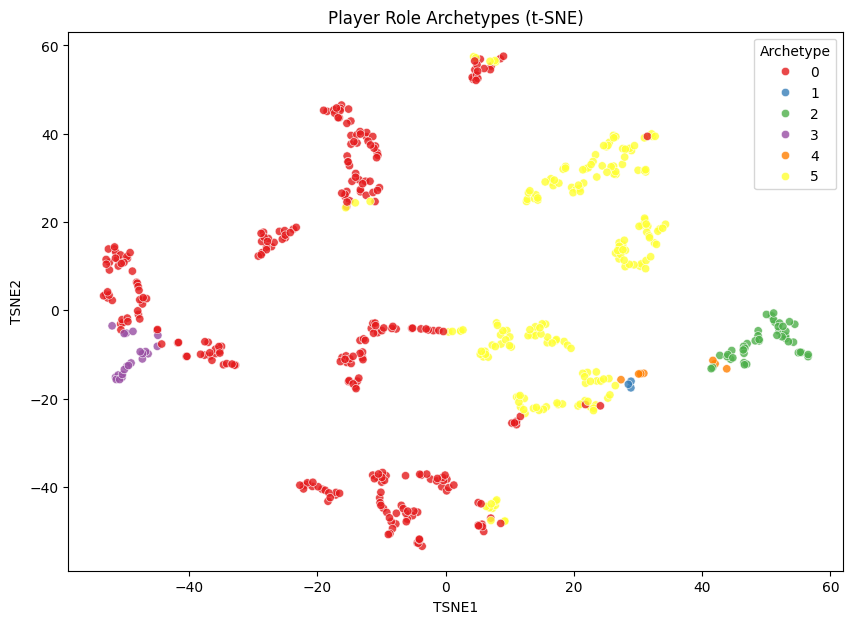

In [48]:
# 15. Visualize Archetypes in Embedding Space
plt.figure(figsize=(10,7))
sns.scatterplot(data=player_roles, x="TSNE1", y="TSNE2",
                hue="role_cluster", palette="Set1", alpha=0.8)
plt.title("Player Role Archetypes (t-SNE)")
plt.legend(title="Archetype")
plt.show()

In [49]:
# 16. List Players by Archetype
for cluster_id, group in player_roles.groupby("role_cluster"):
    print(f"\nRole Archetype {cluster_id}:")
    print(group.index.to_list()[:10])  # show 10 players as sample


Role Archetype 0:
['A. Agbinone', 'A. Armstrong', 'A. Cresswell', 'A. Diallo', 'A. Doucouré', 'A. Elanga', 'A. Garnacho', 'A. Gordon', 'A. Grønbæk', 'A. Irving']

Role Archetype 1:
['S. Mheuka', 'Vitor Reis', 'Youssef Chermiti']

Role Archetype 2:
['A. Aréola', 'A. Bayındır', 'A. Kinský', 'A. McCarthy', 'A. Murić', 'A. Palmer', 'A. Ramsdale', 'Alisson', 'B. Austin', 'B. Leno']

Role Archetype 3:
['B. Gilmour', 'C. Echeverri', 'D. Mubama', 'Daniel Podence', 'E. Buendía', 'F. Onyeka', 'Gustavo Nunes', 'H. Howell', 'H. Reed', 'J. Danns']

Role Archetype 4:
['A. Dorrington', 'E. Cashin', 'J. Sanda', 'M. Amougou', 'M. Mane', 'Pedro Lima', 'Z. Silcott-Duberry']

Role Archetype 5:
['A. Bella-Kotchap', 'A. Broja', 'A. Disasi', 'A. Fatawu', 'A. Gray', 'A. Heaven', 'A. Khusanov', 'A. Onana', 'A. Robertson', 'A. Robinson']


👉 Now we can see which players fall into each role family.

In [50]:
# 17. Combine Archetypes + Similarity

#Finally, you can combine the two ideas:

#First find a player’s archetype (role family).

#Then within that archetype, find the closest players by similarity.

def find_similar_in_role(player_name, top_n=5):
    if player_name not in player_roles.index:
        print(f"⚠️ {player_name} not found")
        return
    
    role_id = player_roles.loc[player_name, "role_cluster"]
    peers = player_roles[player_roles["role_cluster"] == role_id]
    
    sims = sim_df.loc[player_name, peers.index].sort_values(ascending=False).iloc[1:top_n+1]
    return role_id, sims

role_id, peers = find_similar_in_role("Rodri", top_n=5)
print(f"Rodri belongs to Role Archetype {role_id}. Similar players in this archetype:")
print(peers)


Rodri belongs to Role Archetype 0. Similar players in this archetype:
player_name
M. Harness     0.996872
D. Scarlett    0.994411
J. Monga       0.990974
C. Obi         0.984706
Antony         0.983384
Name: Rodri, dtype: float64


# ✅ Wrap-Up for Session 2

By the end of this module, we can:

- Build possessions and extract features.

- Embed possessions → playing styles (direct, tiki-taka, press).

- Aggregate to teams → fingerprints.

- Aggregate to players → embeddings.

- Find similar players (scouting use case).

- Cluster into role archetypes → destroyer, playmaker, winger, striker

# 1) Load + tidy: tracking, events, meta (full timeline)

In [1]:
# Cell 0: imports & constants

import os, json
from pathlib import Path
import pandas as pd
import numpy as np

# --- Paths (yours) ---
BASE_DIR = Path("/Users/pegra441/Desktop/twelve-deep-learning/PremierLeague_data/2024")
DYNAMIC_DIR = BASE_DIR / "dynamic"
META_DIR = BASE_DIR / "meta"
TRACKING_DIR = BASE_DIR / "tracking"
PROCESSED_DIR = BASE_DIR / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

# Pitch constants (SkillCorner → 105x68, origin at left-bottom after rescale)
X_MIN, X_MAX = -52, 52
Y_MIN, Y_MAX = -34, 34
PITCH_LENGTH, PITCH_WIDTH = 105.0, 68.0


In [2]:
# Cell 1: build/refresh matches index (id, home_team, away_team)

matches_file = BASE_DIR / "matches.parquet"
if not matches_file.exists():
    rows = []
    for fpath in DYNAMIC_DIR.glob("*.parquet"):
        match_id = int(fpath.stem)
        meta_path = META_DIR / f"{match_id}.json"
        home_team = away_team = None
        if meta_path.exists():
            with open(meta_path, "r") as f:
                meta = json.load(f)
            home_team = meta["home_team"]["name"]
            away_team = meta["away_team"]["name"]
        rows.append({"id": match_id, "home_team": home_team, "away_team": away_team})
    df_matches = pd.DataFrame(rows)
    df_matches.to_parquet(matches_file, index=False)
else:
    df_matches = pd.read_parquet(matches_file)

print(f"✅ Matches loaded: {len(df_matches)}")
df_matches.head()


✅ Matches loaded: 378


,id,home_team,away_team
0,1986708,Crystal Palace,Brentford FC
1,1715920,Tottenham Hotspur,Arsenal Football Club
2,2015001,West Ham United,Tottenham Hotspur
3,1650385,Manchester United,Fulham
4,2007863,Leicester City,Manchester United


In [3]:
# Cell 2: load helpers (meta, events, tracking) and rescale

def rescale_to_pitch_xy(x, y):
    """Map SkillCorner [-52..52, -34..34] to 105x68 meters."""
    xr = (x - X_MIN) / (X_MAX - X_MIN) * PITCH_LENGTH
    yr = (y - Y_MIN) / (Y_MAX - Y_MIN) * PITCH_WIDTH
    return xr, yr

def load_meta_mapping(match_id: int) -> pd.DataFrame:
    fpath = META_DIR / f"{match_id}.json"
    if not fpath.exists():
        return pd.DataFrame()
    with open(fpath, "r") as f:
        meta = json.load(f)

    home_team, away_team = meta["home_team"], meta["away_team"]
    rows = []
    for p in meta.get("players", []):
        if "id" not in p:
            continue
        team = home_team if p["team_id"] == home_team["id"] else away_team
        rows.append({
            "match_id": meta["id"],
            "player_id": p["id"],                      # aligns to tracking 'player_id'
            "team_id": p["team_id"],
            "team_name": team["name"],
            "team_short": team["short_name"],
            "player_short_name": p.get("short_name"),
            "player_role": p.get("player_role", {}).get("name"),
            "position_group": p.get("player_role", {}).get("position_group"),
            "home_team_id": home_team["id"],
            "away_team_id": away_team["id"],
        })
    return pd.DataFrame(rows)

def load_events_basic(match_id: int) -> pd.DataFrame:
    fpath = DYNAMIC_DIR / f"{match_id}.parquet"
    if not fpath.exists():
        return pd.DataFrame()
    df = pd.read_parquet(fpath)
    keep = [
        "event_id","match_id","event_type","team_id","player_id",
        "time_start","time_end","frame_start","frame_end",
        "attacking_side","start_type","end_type","x_start","y_start","x_end","y_end",
        "period"
    ]
    keep = [c for c in keep if c in df.columns]
    return df[keep].copy()

def load_tracking_full(match_id: int, sort_rows: bool = False, require_ball_detected: bool = True) -> pd.DataFrame:
    fpath = TRACKING_DIR / f"{match_id}.json"
    if not fpath.exists():
        raise FileNotFoundError(f"No tracking for match {match_id}")
    with open(fpath, "r") as f:
        raw = json.load(f)

    rows = []
    for d in raw:
        frame = int(d.get("frame"))
        ts = d.get("timestamp")
        period = d.get("period")

        # Players (be robust if key is missing or None)
        players = d.get("player_data") or []
        for p in players:
            pid = p.get("player_id")
            rows.append({
                "match_id": match_id,
                "time": ts,
                "frame": frame,
                "period": period,
                "player_id": pid,
                "is_detected": bool(p.get("is_detected", False)),
                "is_ball": False,
                "x": p.get("x"),
                "y": p.get("y"),
            })

        # Ball (only append if we actually have a meaningful record)
        ball = d.get("ball_data")
        if ball is not None:
            if (not require_ball_detected) or (ball.get("is_detected") is not None):
                rows.append({
                    "match_id": match_id,
                    "time": ts,
                    "frame": frame,
                    "period": period,
                    "player_id": -1,
                    "is_detected": bool(ball.get("is_detected", False)),
                    "is_ball": True,
                    "x": ball.get("x"),
                    "y": ball.get("y"),
                })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # Enforce dtypes
    df["is_ball"] = df["is_ball"].astype(bool)
    df["is_detected"] = df["is_detected"].astype(bool)
    df["frame"] = df["frame"].astype(int)

    # Rescale (105x68)
    def _rescale_row(r):
        xr = (r["x"] - X_MIN) / (X_MAX - X_MIN) * PITCH_LENGTH if pd.notna(r["x"]) else np.nan
        yr = (r["y"] - Y_MIN) / (Y_MAX - Y_MIN) * PITCH_WIDTH  if pd.notna(r["y"]) else np.nan
        return pd.Series((xr, yr))
    #df[["x_rescaled","y_rescaled"]] = df.apply(_rescale_row, axis=1)
    den_x = (X_MAX - X_MIN); den_y = (Y_MAX - Y_MIN)
    valid_xy = df[["x","y"]].notna().all(axis=1)
    df["x_rescaled"] = np.where(valid_xy, (df["x"] - X_MIN) / den_x * PITCH_LENGTH, np.nan)
    df["y_rescaled"] = np.where(valid_xy, (df["y"] - Y_MIN) / den_y * PITCH_WIDTH, np.nan)


    # Optional sort (avoid putting the ball first if you're just inspecting head())
    if sort_rows:
        df = df.sort_values(["frame","is_ball","player_id"]).reset_index(drop=True)
        # Note: sorting by is_ball puts players (False) before ball (True)
    else:
        df = df.sort_values(["frame"]).reset_index(drop=True)

    # --- Quick debug summary (remove if noisy) ---
    n_ball = int(df["is_ball"].sum())
    n_player = int((~df["is_ball"]).sum())
    print(f"[match {match_id}] rows: {len(df)}, players: {n_player}, ball: {n_ball}")

    return df


In [4]:
# Cell 2b: example load
example_match = int(df_matches["id"].iloc[1])
meta_ex = load_meta_mapping(example_match)
ev_ex   = load_events_basic(example_match)
tr_ex   = load_tracking_full(example_match)
print(example_match, meta_ex.shape, ev_ex.shape, tr_ex.shape)
tr_ex.head(20)


[match 1715920] rows: 963953, players: 922042, ball: 41911
1715920 (40, 10) (4329, 17) (963953, 11)


,match_id,time,frame,period,player_id,is_detected,is_ball,x,y,x_rescaled,y_rescaled
0,1715920,00:00:00.00,10,1,18544,False,False,-31.68,-0.77,20.515385,33.23
1,1715920,00:00:00.00,10,1,-1,True,True,0.41,0.82,52.913942,34.82
2,1715920,00:00:00.00,10,1,2816,True,False,1.03,9.46,53.539904,43.46
3,1715920,00:00:00.00,10,1,4314,True,False,0.45,-20.44,52.954327,13.56
4,1715920,00:00:00.00,10,1,26671,True,False,4.43,15.64,56.972596,49.64
5,1715920,00:00:00.00,10,1,24053,True,False,6.99,6.13,59.557212,40.13
6,1715920,00:00:00.00,10,1,12115,True,False,2.92,-11.02,55.448077,22.98
7,1715920,00:00:00.00,10,1,32071,True,False,10.73,-24.59,63.333173,9.41
8,1715920,00:00:00.00,10,1,13985,True,False,12.61,12.19,65.231250,46.19
9,1715920,00:00:00.00,10,1,38008,True,False,11.66,-17.03,64.272115,16.97


In [5]:
import pandas as pd
import numpy as np

def to_seconds(series: pd.Series) -> pd.Series:
    """
    Convert time to seconds.
    Handles strings like 'HH:MM:SS.ff' (e.g., '00:00:00.10'),
    numeric seconds, and large integers/floats in ms.
    Returns a float Series.
    """
    # if already numeric-ish, start there
    s_num = pd.to_numeric(series, errors="coerce")

    # try timedelta parsing for strings like HH:MM:SS.ff
    s_td = pd.to_timedelta(series.astype(str).str.strip().str.replace(",", ".", regex=False),
                           errors="coerce")
    s_sec_td = s_td.dt.total_seconds()

    # prefer timedelta parse when available, else numeric
    s = s_sec_td.fillna(s_num)

    # if values look like milliseconds (very large), convert to seconds
    if s.notna().any():
        median_val = s.dropna().median()
        # heuristic: median > 1e6 suggests ms ticks (e.g., 1,650,000,000)
        if median_val is not None and median_val > 1e6:
            s = s / 1000.0

    return s.astype(float)


In [6]:
def estimate_fps_from_time_df(df: pd.DataFrame, group_cols=("match_id",)) -> float:
    """
    Estimate frames-per-second from median time delta.
    Works even if you pass only ball rows or all rows.
    """
    t = to_seconds(df["time"])
    # compute dt within each group (match)
    if not isinstance(group_cols, (list, tuple)):
        group_cols = (group_cols,)
    dt = t.groupby([df[c] for c in group_cols]).diff().astype(float)
    dt = dt[(dt > 0) & dt.notna()]
    if dt.empty:
        return 25.0
    fps = 1.0 / float(dt.median())
    return float(np.clip(fps, 5, 120))


In [7]:
# Prefer ball rows (usually present in every frame)
ball_rows = tr_ex[tr_ex["is_ball"]]
fps = estimate_fps_from_time_df(ball_rows, group_cols=("match_id",))
print("Estimated FPS:", fps)


Estimated FPS: 10.000000000009095


# 📘 Ball Speed Calculation – Step by Step
1. Why do we clean the data?

Tracking data is noisy. If we use it raw:

Missing frames → fake zero speeds

Camera jitter → fake speed spikes

Wrong units → meaningless numbers

So we:

Parse time → convert "00:00:00.10" into seconds

Estimate FPS → how many frames per second (≈25 Hz)

Interpolate short gaps → connect missing dots (≤ 0.3–0.5s)

Smooth → remove jitter (≈ 0.6–1.0s window)

Compute speed = sqrt(vx² + vy²) in m/s

Clip unrealistic spikes (e.g. > 40 m/s)

2. Intuition (explain like I’m 10)

Interpolation: connect missing pages in a flipbook so the ball doesn’t disappear

Smoothing: trace over a wiggly line with a thicker pencil

Velocity: how much the dot moved since the last page

Speed: how fast the dot is moving (m/s)

Clip: ignore superhero glitches

3. Recommended defaults

interp_gap_s = 0.4 seconds

smooth_window_s = 0.7 seconds

clip_speed_mps = 40 m/s (~144 km/h)

Ball-in-play threshold = speed ≥ 1.0 m/s, with ±1s dilation

In [8]:
def compute_ball_kinematics(tr_df: pd.DataFrame,
                            interp_gap_s: float = 0.40,
                            smooth_window_s: float = 0.70,
                            clip_speed_mps: float = 40.0) -> pd.DataFrame:
    """
    Returns one row per ball frame with columns:
      match_id, frame, time_s, x_s, y_s, vx_mps, vy_mps, speed_mps, fps_used
    """
    ball = tr_df[tr_df["is_ball"]].copy()
    # parse time
    ball["time_s"] = to_seconds(ball["time"])
    # numeric positions
    ball["x_rescaled"] = pd.to_numeric(ball["x_rescaled"], errors="coerce")
    ball["y_rescaled"] = pd.to_numeric(ball["y_rescaled"], errors="coerce")
    ball["frame"] = pd.to_numeric(ball["frame"], errors="coerce")

    # sort per match/frame
    ball = ball.sort_values(["match_id", "frame"]).reset_index(drop=True)

    # fps & dt
    fps = estimate_fps_from_time_df(ball, group_cols=("match_id",))
    dt = 1.0 / fps

    # convert seconds -> frames for parameters
    max_gap_frames = max(1, int(round(interp_gap_s * fps)))
    window_frames  = max(3, int(round(smooth_window_s * fps)))
    if window_frames % 2 == 0:  # make odd for centered window
        window_frames += 1

    # interpolate short gaps only
    x = ball["x_rescaled"]
    y = ball["y_rescaled"]
    x_i = x.interpolate(limit=max_gap_frames, limit_direction="both")
    y_i = y.interpolate(limit=max_gap_frames, limit_direction="both")

    # smooth with centered rolling median
    x_s = x_i.rolling(window_frames, center=True, min_periods=max(1, window_frames//2)).median()
    y_s = y_i.rolling(window_frames, center=True, min_periods=max(1, window_frames//2)).median()


    #x_s, y_s are the smoothed/interpolated positions used to compute speed.

    # central differences for velocity
    vx = (x_s.shift(-1) - x_s.shift(1)) / (2*dt)
    vy = (y_s.shift(-1) - y_s.shift(1)) / (2*dt)

    speed = np.sqrt(vx**2 + vy**2).clip(lower=0, upper=clip_speed_mps)

    kin = pd.DataFrame({
        "match_id": ball["match_id"].values,
        "frame":    ball["frame"].astype("Int64").values,
        "time_s":   ball["time_s"].values,
        "x_s":      x_s.values,
        "y_s":      y_s.values,
        "vx_mps":   vx.values,
        "vy_mps":   vy.values,
        "speed_mps": speed.values,
        "fps_used": fps
    })
    return kin


In [9]:
kin = compute_ball_kinematics(tr_ex, interp_gap_s=0.40, smooth_window_s=0.70)
kin.head(12)


,match_id,frame,time_s,x_s,y_s,vx_mps,vy_mps,speed_mps,fps_used
0,1715920,10,0.0,52.777644,35.275,NaN,NaN,NaN,10.0
1,1715920,11,0.1,52.732212,35.500,-0.378606,0.900,0.976393,10.0
2,1715920,12,0.2,52.701923,35.455,-0.302885,-0.450,0.542438,10.0
3,1715920,13,0.3,52.671635,35.410,-0.151442,-0.225,0.271219,10.0
4,1715920,14,0.4,52.671635,35.410,0.000000,0.000,0.000000,10.0
5,1715920,15,0.5,52.671635,35.410,0.000000,-1.400,1.400000,10.0
6,1715920,16,0.6,52.671635,35.130,0.000000,-2.550,2.550000,10.0
7,1715920,17,0.7,52.671635,34.900,0.000000,-1.750,1.750000,10.0
8,1715920,18,0.8,52.671635,34.780,0.151442,-0.600,0.618817,10.0
9,1715920,19,0.9,52.701923,34.780,0.151442,-0.050,0.159483,10.0


In [10]:
print("Speed stats (m/s):")
print(kin["speed_mps"].describe(percentiles=[0.5, 0.9, 0.99]).round(2))

Speed stats (m/s):
count    41909.00
mean         5.38
std          5.36
min          0.00
50%          3.72
90%         12.96
99%         22.50
max         40.00
Name: speed_mps, dtype: float64


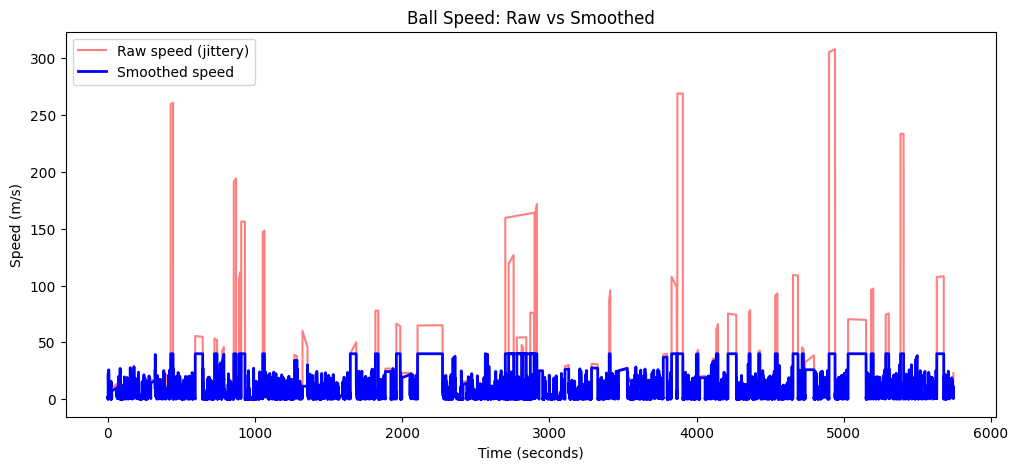

In [11]:
import matplotlib.pyplot as plt

# Take a slice of ball data
ball = tr_ex[tr_ex["is_ball"]].copy()
ball["time_s"] = to_seconds(ball["time"])

# Raw speed (no interp, no smoothing)
fps = estimate_fps_from_time_df(ball)
dt = 1.0 / fps
x_raw = ball["x_rescaled"].astype(float)
y_raw = ball["y_rescaled"].astype(float)
vx_raw = (x_raw.shift(-1) - x_raw.shift(1)) / (2*dt)
vy_raw = (y_raw.shift(-1) - y_raw.shift(1)) / (2*dt)
speed_raw = np.sqrt(vx_raw**2 + vy_raw**2)

# Cleaned speed
kin = compute_ball_kinematics(tr_ex, interp_gap_s=0.4, smooth_window_s=0.7)
speed_clean = kin.set_index("frame")["speed_mps"]

# Align by frame
df_plot = pd.DataFrame({
    "time_s": ball["time_s"].values,
    "speed_raw": speed_raw.values,
    "speed_clean": speed_clean.reindex(ball["frame"].values).values
})

# Plot
plt.figure(figsize=(12,5))
plt.plot(df_plot["time_s"], df_plot["speed_raw"], alpha=0.5, label="Raw speed (jittery)", color="red")
plt.plot(df_plot["time_s"], df_plot["speed_clean"], label="Smoothed speed", color="blue", linewidth=2)
plt.xlabel("Time (seconds)")
plt.ylabel("Speed (m/s)")
plt.title("Ball Speed: Raw vs Smoothed")
plt.legend()
plt.show()


# 🟢 What is the Ball-in-Play mask?

It’s a flag for each frame: True if the game is live, False if the ball is out, in set-piece prep, halftime, etc.

We detect it from ball movement: when the ball is moving above a small threshold, we assume the game is live.

To avoid flickering:

we dilate (expand) the in-play signal a bit forward/backward in time (≈1s)

we can also add a fallback check for player movement, in case the ball disappears in tracking.



1. Pick a speed threshold

Ball rolling ≈ 0.5–1.0 m/s

Safe default: speed_threshold = 1.0 m/s

2. Dilate the mask

Sometimes the ball slows briefly (trap, bounce).

Expand the in-play window ±1 second (so you don’t break continuity).

3. Merge back into tracking

Create a boolean column ball_in_play for every frame in tr_df.

That way, you can filter tracking like:

In [12]:
def make_ball_in_play_mask(tr_df: pd.DataFrame,
                           kin: pd.DataFrame,
                           speed_threshold_mps: float = 1.0,
                           dilate_seconds: float = 1.0) -> pd.DataFrame:
    """
    Add a 'ball_in_play' column to tr_df using ball speed.
    - tr_df: full tracking DataFrame (players + ball)
    - kin: ball kinematics DataFrame (from compute_ball_kinematics)
    """
    out = tr_df.copy()
    fps = kin["fps_used"].iloc[0] if not kin.empty else 10.0
    pad_frames = int(round(dilate_seconds * fps))

    # Step 1: build raw mask from speed
    kin_mask = (kin["speed_mps"] >= speed_threshold_mps).astype(int)

    # Step 2: dilate with rolling max
    dilated = kin_mask.rolling(2*pad_frames+1, center=True, min_periods=1).max().astype(bool)

    # Step 3: assign back to frames
    mask_df = kin[["match_id", "frame"]].copy()
    mask_df["ball_in_play"] = dilated.values

    out = out.merge(mask_df, on=["match_id","frame"], how="left")
    out["ball_in_play"] = out["ball_in_play"].fillna(False)

    return out


In [13]:
kin = compute_ball_kinematics(tr_ex, interp_gap_s=0.4, smooth_window_s=0.7)
tr_with_bip = make_ball_in_play_mask(tr_ex, kin,
                                     speed_threshold_mps=1.0,
                                     dilate_seconds=1.0)

print(tr_with_bip["ball_in_play"].value_counts(normalize=True))


ball_in_play
True     0.937868
False    0.062132
Name: proportion, dtype: float64


### Step 0. Merge Tracking with Meta (Team + Role Info)

Our tracking dataframe `tr_with_bip` only has `player_id`.  
To know which team each player belongs to, we merge with the **meta JSON** mapping.

This will give us:
- `player_team_id`  
- `player_team_name`  
- `player_role` (if available)  

These are necessary for filtering 11v11 and later role analysis.


In [14]:
def enrich_tracking_with_meta(tr_df: pd.DataFrame, match_id: int, meta_dir=META_DIR) -> pd.DataFrame:
    """
    Merge tracking with meta info (team and role for each player).
    """
    df_meta = load_meta_mapping(match_id)
    if df_meta.empty:
        return tr_df

    df = tr_df.merge(
        df_meta[[
            "match_id","player_id",
            "team_id","team_name","team_short",
            "position_group","player_role","player_short_name"
        ]],
        on=["match_id","player_id"], how="left"
    )

    return df


# Example usage:
tr_with_meta = enrich_tracking_with_meta(tr_with_bip, match_id=1715920)
tr_with_meta.head()


,match_id,time,frame,period,player_id,is_detected,is_ball,x,y,x_rescaled,y_rescaled,ball_in_play,team_id,team_name,team_short,position_group,player_role,player_short_name
0,1715920,00:00:00.00,10,1,18544,False,False,-31.68,-0.77,20.515385,33.23,True,3.0,Arsenal Football Club,Arsenal,Other,Goalkeeper,David Raya
1,1715920,00:00:00.00,10,1,-1,True,True,0.41,0.82,52.913942,34.82,True,NaN,NaN,NaN,NaN,NaN,NaN
2,1715920,00:00:00.00,10,1,2816,True,False,1.03,9.46,53.539904,43.46,True,44.0,Tottenham Hotspur,Tottenham,Center Forward,Center Forward,D. Solanke
3,1715920,00:00:00.00,10,1,4314,True,False,0.45,-20.44,52.954327,13.56,True,44.0,Tottenham Hotspur,Tottenham,Wide Attacker,Left Forward,Son Heung-Min
4,1715920,00:00:00.00,10,1,26671,True,False,4.43,15.64,56.972596,49.64,True,44.0,Tottenham Hotspur,Tottenham,Wide Attacker,Right Forward,B. Johnson


In [15]:
tr_with_meta.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id', 'is_detected',
       'is_ball', 'x', 'y', 'x_rescaled', 'y_rescaled', 'ball_in_play',
       'team_id', 'team_name', 'team_short', 'position_group', 'player_role',
       'player_short_name'],
      dtype='object')

### Step 1. Filter to Ball-in-Play & 11v11

Now that tracking has team info from meta:
- Keep only frames where `ball_in_play=True`
- Keep only frames where **each team has 11 detected players**


In [16]:
def filter_bip_and_11v11(tr_df: pd.DataFrame) -> pd.DataFrame:
    """
    Keep only ball-in-play frames with 11 players per team.
    Requires `player_team_id`.
    """
    df = tr_df.copy()

    # keep only ball-in-play
    df = df[df["ball_in_play"]].copy()

    # count players per team per frame
    #players = df[~df["is_ball"] & df["is_detected"]]
    players = df[~df["is_ball"] & df[["x","y"]].notna().all(axis=1)]

    counts = players.groupby(["match_id","frame","period","team_id"]).size().reset_index(name="n_players")

    # keep only frames where all teams have at least 11 players
    valid_frames = counts.groupby(["match_id","frame"])["n_players"].min()
    valid_frames = valid_frames[valid_frames >= 11].reset_index()[["match_id","frame"]]

    # join back
    df = df.merge(valid_frames, on=["match_id","frame"], how="inner")
    return df

# Example usage:
tr_clean = filter_bip_and_11v11(tr_with_meta)
print("Frames after filtering:", tr_clean["frame"].nunique())


Frames after filtering: 39307


### Step 4. Normalize Attack Direction (using events)

- Problem:  
  Teams switch halves → 1st half left→right, 2nd half right→left.  
  If we don’t normalize, average formations will look mirrored.  

- Source:  
  `attacking_side` is stored in **events data** (not meta).  
  It tells us, for each `team_id` and `period`, whether that team attacks `"left_to_right"` or `"right_to_left"`.

- Solution:  
  For every frame in tracking:  
  1. Look up the team’s attacking side from events.  
  2. If `"right_to_left"`, flip `x` → `-x`.  
  3. Keep `y` the same.



In [17]:
PITCH_LENGTH = 105  # in meters

def normalize_direction(tr_df: pd.DataFrame, ev_df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize attack direction so all teams attack left-to-right.
    Works with FIFA-style pitch coordinates (0–105).
    """
    df = tr_df.copy()

    # Extract mapping from events: (match_id, period, team_id) -> attacking_side
    sides = ev_df.dropna(subset=["attacking_side"]).drop_duplicates(
        ["match_id","period","team_id"]
    )[["match_id","period","team_id","attacking_side"]]

    df = df.merge(sides, on=["match_id","period","team_id"], how="left")

    # Flip x if right-to-left
    df["x_norm"] = np.where(
        df["attacking_side"] == "right_to_left",
        PITCH_LENGTH - df["x_rescaled"],
        df["x_rescaled"]
    )
    df["y_norm"] = df["y_rescaled"]

    return df



In [18]:
# Load one match events
ev_ex = load_events_basic(match_id= 1715920)

# Normalize tracking directions
tr_norm = normalize_direction(tr_clean, ev_ex)

tr_norm[["team_id","period","attacking_side","x_rescaled","x_norm"]].sample(10)



,team_id,period,attacking_side,x_rescaled,x_norm
893572,44.0,2,left_to_right,37.981731,37.981731
726427,44.0,2,left_to_right,81.637500,81.637500
485648,3.0,2,right_to_left,47.401442,57.598558
708119,44.0,2,left_to_right,74.701442,74.701442
757933,44.0,2,left_to_right,30.116827,30.116827
88618,3.0,1,left_to_right,80.627885,80.627885
217418,3.0,1,left_to_right,19.667308,19.667308
91965,NaN,1,NaN,91.097596,91.097596
610777,44.0,2,left_to_right,6.946154,6.946154
839205,3.0,2,right_to_left,87.957692,17.042308


### Step 5. Average Formation

Goal:
- Summarize thousands of frames into a clear "formation picture".
- For each team, compute the **average (x,y) position** of players across all frames.
- This shows the team's "default shape" during live play.

Steps:
1. Drop the ball rows (`is_ball=True`).
2. Group by `match_id`, `team_id`, `player_id`.
3. Compute the mean `x_norm`, `y_norm` (normalized coordinates).
4. Optionally: also compute spread (std) to measure variability.
5. Plot players on a pitch.


In [19]:
def compute_average_formation(tr_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute average formation (mean x,y per player) for a single match.
    Assumes tr_df has been filtered (ball-in-play, 11v11, normalized).
    """
    players = tr_df[~tr_df["is_ball"] & tr_df[["x_norm","y_norm"]].notna().all(axis=1)]
    cols_id = ["match_id","team_id","team_name","team_short",
               "player_id","player_short_name","player_role","position_group"]
    cols_id = [c for c in cols_id if c in players.columns]  # keep existing


    avg = (players
           .groupby(cols_id, dropna=False)[["x_norm","y_norm"]]
           .mean()
           .reset_index())
    return avg


In [20]:
tr_norm

,match_id,time,frame,period,player_id,is_detected,is_ball,x,y,x_rescaled,...,ball_in_play,team_id,team_name,team_short,position_group,player_role,player_short_name,attacking_side,x_norm,y_norm
0,1715920,00:00:00.00,10,1,18544,False,False,-31.68,-0.77,20.515385,...,True,3.0,Arsenal Football Club,Arsenal,Other,Goalkeeper,David Raya,left_to_right,20.515385,33.23
1,1715920,00:00:00.00,10,1,-1,True,True,0.41,0.82,52.913942,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.913942,34.82
2,1715920,00:00:00.00,10,1,2816,True,False,1.03,9.46,53.539904,...,True,44.0,Tottenham Hotspur,Tottenham,Center Forward,Center Forward,D. Solanke,right_to_left,51.460096,43.46
3,1715920,00:00:00.00,10,1,4314,True,False,0.45,-20.44,52.954327,...,True,44.0,Tottenham Hotspur,Tottenham,Wide Attacker,Left Forward,Son Heung-Min,right_to_left,52.045673,13.56
4,1715920,00:00:00.00,10,1,26671,True,False,4.43,15.64,56.972596,...,True,44.0,Tottenham Hotspur,Tottenham,Wide Attacker,Right Forward,B. Johnson,right_to_left,48.027404,49.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904056,1715920,01:35:44.90,59459,2,14155,True,False,37.33,5.64,90.188942,...,True,44.0,Tottenham Hotspur,Tottenham,Central Defender,Right Center Back,C. Romero,left_to_right,90.188942,39.64
904057,1715920,01:35:44.90,59459,2,19584,False,False,-14.07,4.29,38.294712,...,True,44.0,Tottenham Hotspur,Tottenham,Other,Goalkeeper,G. Vicario,left_to_right,38.294712,38.29
904058,1715920,01:35:44.90,59459,2,12485,True,False,24.74,3.31,77.477885,...,True,3.0,Arsenal Football Club,Arsenal,Center Forward,Center Forward,K. Havertz,right_to_left,27.522115,37.31
904059,1715920,01:35:44.90,59459,2,2816,True,False,43.87,1.35,96.791827,...,True,44.0,Tottenham Hotspur,Tottenham,Center Forward,Center Forward,D. Solanke,left_to_right,96.791827,35.35


In [21]:
avg_form = compute_average_formation(tr_norm)
avg_form


,match_id,team_id,team_name,team_short,player_id,player_short_name,player_role,position_group,x_norm,y_norm
0,1715920,3.0,Arsenal Football Club,Arsenal,5365,Jorginho,Defensive Midfield,Midfield,42.835541,32.338406
1,1715920,3.0,Arsenal Football Club,Arsenal,6109,L. Trossard,Left Forward,Wide Attacker,54.208328,32.620662
2,1715920,3.0,Arsenal Football Club,Arsenal,8846,R. Sterling,Left Midfield,Midfield,40.475427,26.283716
3,1715920,3.0,Arsenal Football Club,Arsenal,10324,T. Partey,Right Midfield,Midfield,40.810614,32.211776
4,1715920,3.0,Arsenal Football Club,Arsenal,11500,Gabriel Jesus,Left Forward,Wide Attacker,42.872580,37.734812
5,1715920,3.0,Arsenal Football Club,Arsenal,12286,W. Saliba,Right Center Back,Central Defender,33.080748,33.400860
6,1715920,3.0,Arsenal Football Club,Arsenal,12485,K. Havertz,Center Forward,Center Forward,55.169428,31.741120
7,1715920,3.0,Arsenal Football Club,Arsenal,12841,Gabriel Magalhaes,Left Center Back,Central Defender,33.238491,32.762942
8,1715920,3.0,Arsenal Football Club,Arsenal,18544,David Raya,Goalkeeper,Other,12.212632,33.503189
9,1715920,3.0,Arsenal Football Club,Arsenal,20208,B. Saka,Right Forward,Wide Attacker,52.392144,31.110455


   match_id  team_id              team_name team_short  player_id  \
0   1715920      3.0  Arsenal Football Club    Arsenal       5365   
1   1715920      3.0  Arsenal Football Club    Arsenal       6109   
2   1715920      3.0  Arsenal Football Club    Arsenal       8846   
3   1715920      3.0  Arsenal Football Club    Arsenal      10324   
4   1715920      3.0  Arsenal Football Club    Arsenal      11500   

  player_short_name         player_role position_group     x_norm     y_norm  
0          Jorginho  Defensive Midfield       Midfield  42.835541  32.338406  
1       L. Trossard        Left Forward  Wide Attacker  54.208328  32.620662  
2       R. Sterling       Left Midfield       Midfield  40.475427  26.283716  
3         T. Partey      Right Midfield       Midfield  40.810614  32.211776  
4     Gabriel Jesus        Left Forward  Wide Attacker  42.872580  37.734812  


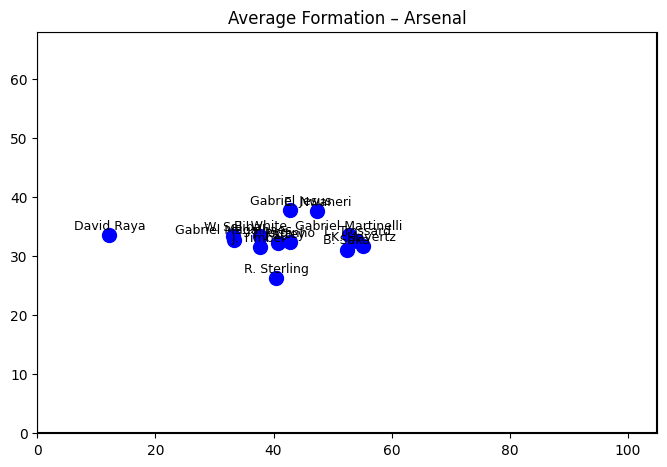

In [22]:
# For one match
avg_form = compute_average_formation(tr_norm)

print(avg_form.head())

# Example: plot Real Madrid formation
team_form = avg_form[avg_form["team_name"]=="Arsenal Football Club"]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,6))
ax.set_xlim(0,105); ax.set_ylim(0,68)
ax.set_aspect('equal')

# draw pitch outline (simplified)
ax.plot([0,105,105,0,0],[0,0,68,68,0], color="black")

ax.scatter(team_form["x_norm"], team_form["y_norm"], color="blue", s=100)
for _, row in team_form.iterrows():
    ax.text(row["x_norm"], row["y_norm"]+1, row["player_short_name"], ha="center", fontsize=9)

ax.set_title("Average Formation – Arsenal")
plt.show()


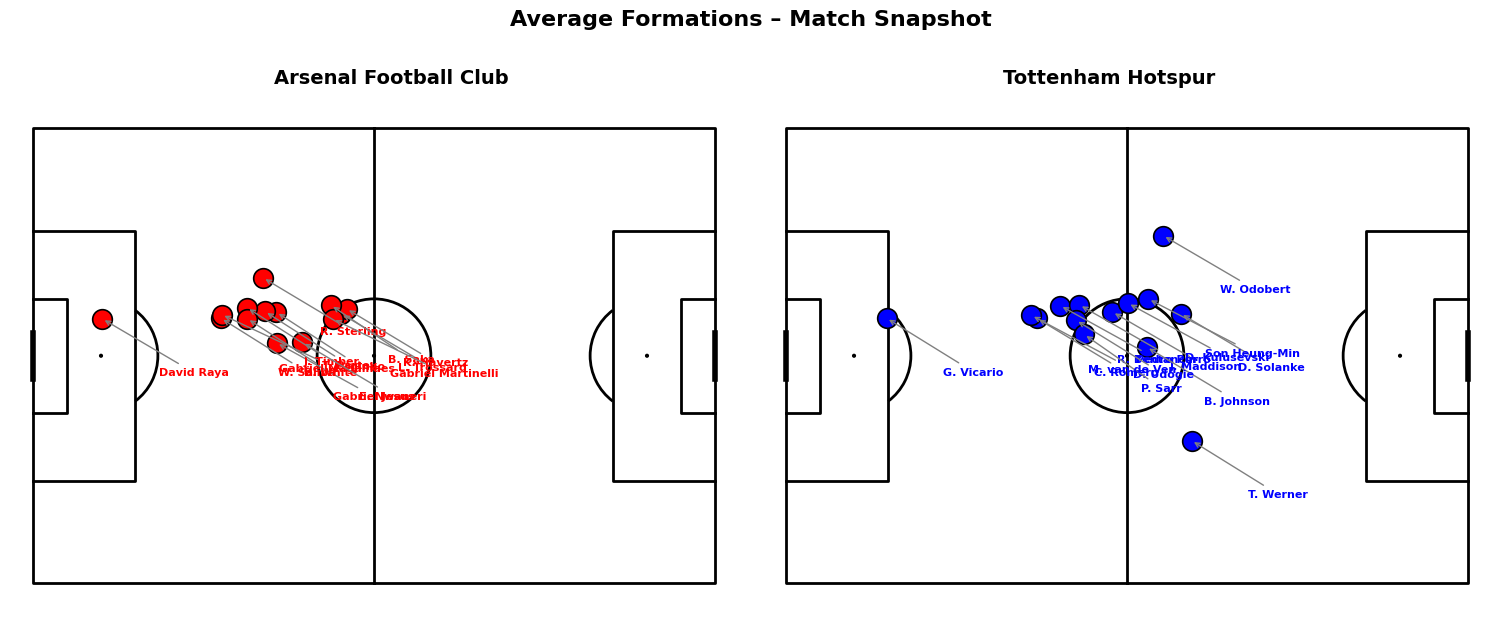

In [23]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

def plot_formations_with_arrows(avg_form, team1="Arsenal Football Club", team2="Tottenham Hotspur"):
    """
    Plot average formations of two teams side by side using mplsoccer.
    Player names are shown with arrows to reduce overlap.
    """
    # filter teams
    team1_form = avg_form[avg_form["team_name"]==team1]
    team2_form = avg_form[avg_form["team_name"]==team2]

    # create pitch
    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  line_zorder=2, pitch_color='white', line_color='black')
    fig, axs = pitch.grid(nrows=1, ncols=2, figheight=7,
                          title_height=0.06, endnote_height=0.03,
                          axis=False, grid_width=0.9)

    # --- Helper to plot one team ---
    def plot_team(team_form, ax, color):
        pitch.scatter(team_form["x_norm"], team_form["y_norm"],
                      s=200, c=color, edgecolors="black", linewidth=1.2,
                      ax=ax, zorder=3)
        for i, row in team_form.iterrows():
            ax.annotate(
                row["player_short_name"],
                xy=(row["x_norm"], row["y_norm"]),
                xytext=(row["x_norm"]+10, row["y_norm"]+10),   # offset label
                arrowprops=dict(arrowstyle="->", color="gray", lw=1),
                fontsize=8, weight="bold", color=color
            )

    # --- Plot both teams ---
    plot_team(team1_form, axs['pitch'][0], color="red")
    axs['title'].text(0.25, 0.5, team1, ha="center", va="center", fontsize=14, weight="bold")

    plot_team(team2_form, axs['pitch'][1], color="blue")
    axs['title'].text(0.75, 0.5, team2, ha="center", va="center", fontsize=14, weight="bold")

    fig.suptitle("Average Formations – Match Snapshot", fontsize=16, weight="bold")
    plt.show()


# Example usage
avg_form = compute_average_formation(tr_norm)
plot_formations_with_arrows(avg_form,
                            team1="Arsenal Football Club",
                            team2="Tottenham Hotspur")


In [24]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_formations_with_roles(avg_form: pd.DataFrame,
                               team1: str = "Arsenal Football Club",
                               team2: str = "Tottenham Hotspur",
                               dot_size: int = 180):
    """
    Side-by-side average formations using mplsoccer.
    - Colors & label offsets are driven by `position_group`.
    - Names are offset with arrows to reduce overlap.
    - Adds legend for role groups.
    """

    # Role-based label offsets (dx, dy in meters)
    role_offsets = {
        "Goalkeeper":       (-9, 0),
        "Central Defender": (0, -8),
        "Full Back":        (-6, -5),
        "Midfield":         (8, 0),
        "Wide Attacker":    (6, 6),
        "Center Forward":   (0, 9),
        "Other":            (6, 6),
    }

    # Role-based colors
    role_colors = {
        "Goalkeeper":       "#7f7f7f",  # gray
        "Central Defender": "#2ca02c",  # green
        "Full Back":        "#1b7d1b",  # darker green
        "Midfield":         "#ff7f0e",  # orange
        "Wide Attacker":    "#9467bd",  # purple
        "Center Forward":   "#d62728",  # red
        "Other":            "#444444",
    }

    # Filter the two teams
    t1 = avg_form[avg_form["team_name"] == team1].copy()
    t2 = avg_form[avg_form["team_name"] == team2].copy()

    # Create pitch
    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black', line_zorder=2)
    fig, axs = pitch.grid(nrows=1, ncols=2, figheight=7,
                          title_height=0.06, endnote_height=0.03,
                          axis=False, grid_width=0.9)

    def _plot_team(team_df, ax, fallback_color="#333333"):
        # Draw dots
        for _, row in team_df.iterrows():
            role = row.get("position_group", "Other")
            color = role_colors.get(role, fallback_color)

            pitch.scatter(row["x_norm"], row["y_norm"],
                          s=dot_size, c=color, edgecolors="black", linewidth=1.0,
                          ax=ax, zorder=3)

        # Annotate names with arrows (role-based offsets)
        for _, row in team_df.iterrows():
            role = row.get("position_group", "Other")
            dx, dy = role_offsets.get(role, (6, 6))
            jitter = np.random.uniform(-1.0, 1.0, size=2)  # avoid collisions
            tx = row["x_norm"] + dx + jitter[0]
            ty = row["y_norm"] + dy + jitter[1]

            ax.annotate(
                row["player_short_name"],
                xy=(row["x_norm"], row["y_norm"]),
                xytext=(tx, ty),
                arrowprops=dict(arrowstyle="->", color="#6e6e6e", lw=1),
                fontsize=8, weight="bold", color=role_colors.get(role, fallback_color),
            )

    _plot_team(t1, axs['pitch'][0])
    _plot_team(t2, axs['pitch'][1])

    # Titles
    t1_title = (t1["team_short"].iloc[0] if "team_short" in t1.columns and len(t1) else team1)
    t2_title = (t2["team_short"].iloc[0] if "team_short" in t2.columns and len(t2) else team2)
    axs['title'].text(0.25, 0.5, t1_title, ha="center", va="center", fontsize=14, weight="bold")
    axs['title'].text(0.75, 0.5, t2_title, ha="center", va="center", fontsize=14, weight="bold")

    # --- Legend ---
    handles = [mpatches.Patch(color=color, label=role)
               for role, color in role_colors.items()]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle("Average Formations – Match Snapshot", fontsize=16, weight="bold")
    plt.show()


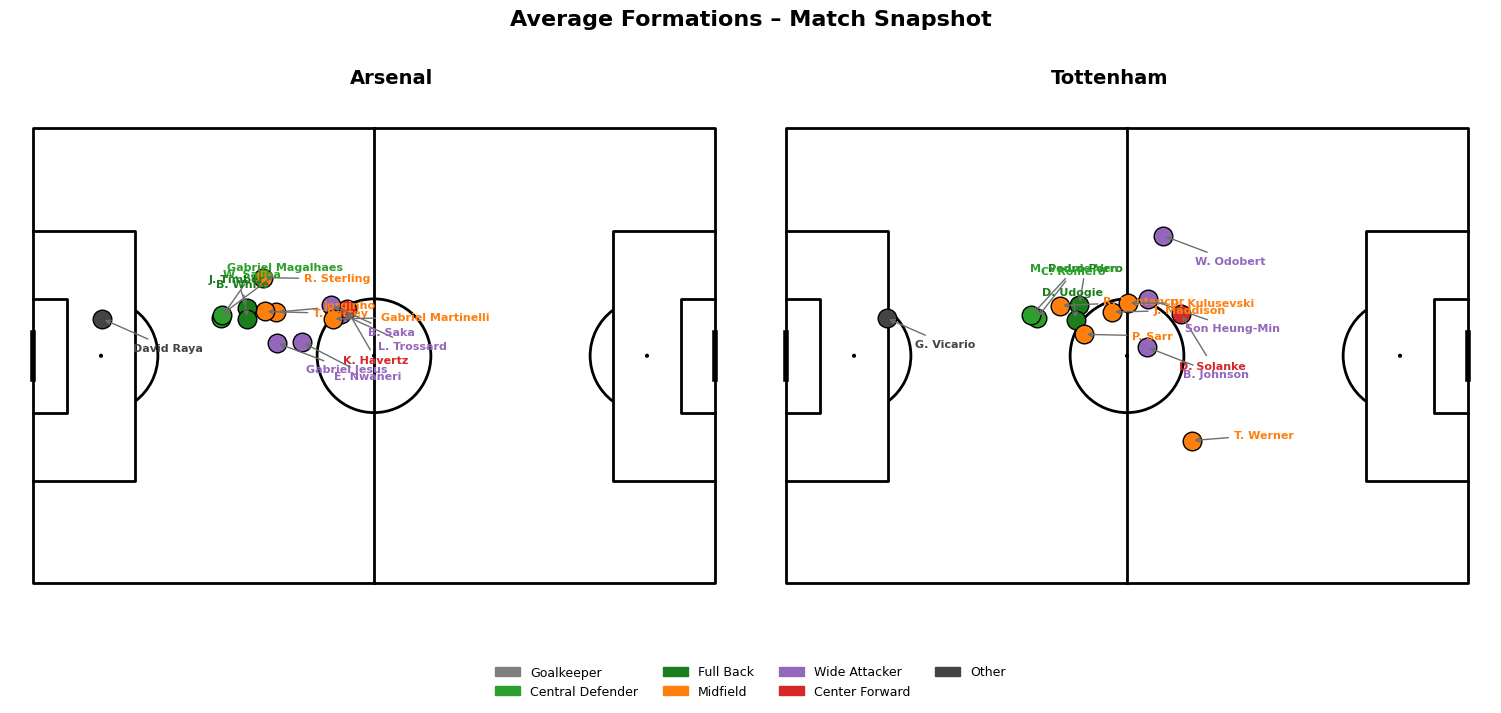

In [25]:
avg_form = compute_average_formation(tr_norm)  # updated to include position_group
plot_formations_with_roles(avg_form,
                           team1="Arsenal Football Club",
                           team2="Tottenham Hotspur")


In [26]:
# 📘 Step 1. Compute Average Formation per Half

def compute_average_formation_by_half(tr_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute average (x,y) per player split by half (period).
    Requires normalized coordinates (x_norm, y_norm).
    """
    players = tr_df[(~tr_df["is_ball"]) & tr_df[["x_norm","y_norm"]].notna().all(axis=1)].copy()

    cols_id = ["match_id","team_id","team_name","team_short",
               "player_id","player_short_name","player_role","position_group","period"]
    cols_id = [c for c in cols_id if c in players.columns]  

    avg = (players
           .groupby(cols_id, dropna=False)[["x_norm","y_norm"]]
           .mean()
           .reset_index())
    return avg


In [27]:
# 📘 Step 2. Plot Formations Side by Side (1st vs 2nd Half)
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_formations_by_half(avg_form: pd.DataFrame,
                            team: str = "Arsenal Football Club",
                            dot_size: int = 180):
    """
    Compare 1st vs 2nd half average formations for one team.
    """

    # Role-based colors
    role_colors = {
        "Central Defender": "#2ca02c",
        "Full Back": "#1b7d1b",
        "Midfield": "#ff7f0e",
        "Wide Attacker": "#9467bd",
        "Center Forward": "#d62728",
        "Goalkeeper": "#7f7f7f",
        "Other": "#444444",
    }

    # Role-based label offsets
    role_offsets = {
        "Central Defender": (0, -8),
        "Full Back": (-6, -5),
        "Midfield": (8, 0),
        "Wide Attacker": (6, 6),
        "Center Forward": (0, 9),
        "Goalkeeper": (-9, 0),
        "Other": (6, 6),
    }

    # Filter team
    t_form = avg_form[avg_form["team_name"] == team]

    # Create pitch with 2 columns (1st half vs 2nd half)
    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, axs = pitch.grid(nrows=1, ncols=2, figheight=7,
                          title_height=0.06, endnote_height=0.03,
                          axis=False, grid_width=0.9)

    def _plot_half(df_half, ax):
        for _, row in df_half.iterrows():
            role = row.get("position_group", "Other")
            color = role_colors.get(role, "#333333")

            # Draw dot
            pitch.scatter(row["x_norm"], row["y_norm"],
                          s=dot_size, c=color, edgecolors="black", linewidth=1.0,
                          ax=ax, zorder=3)

            # Offset label with arrow
            dx, dy = role_offsets.get(role, (6, 6))
            tx, ty = row["x_norm"]+dx, row["y_norm"]+dy
            ax.annotate(
                row["player_short_name"],
                xy=(row["x_norm"], row["y_norm"]),
                xytext=(tx, ty),
                arrowprops=dict(arrowstyle="->", color="#6e6e6e", lw=1),
                fontsize=8, weight="bold", color=color
            )

    # Plot 1st half
    df_half1 = t_form[t_form["period"] == 1]
    _plot_half(df_half1, axs['pitch'][0])
    axs['title'].text(0.25, 0.5, f"{team} – 1st Half", 
                      ha="center", va="center", fontsize=13, weight="bold")

    # Plot 2nd half
    df_half2 = t_form[t_form["period"] == 2]
    _plot_half(df_half2, axs['pitch'][1])
    axs['title'].text(0.75, 0.5, f"{team} – 2nd Half", 
                      ha="center", va="center", fontsize=13, weight="bold")

    # Legend
    handles = [mpatches.Patch(color=color, label=role) for role, color in role_colors.items()]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle("Formation Comparison by Half", fontsize=16, weight="bold")
    plt.show()


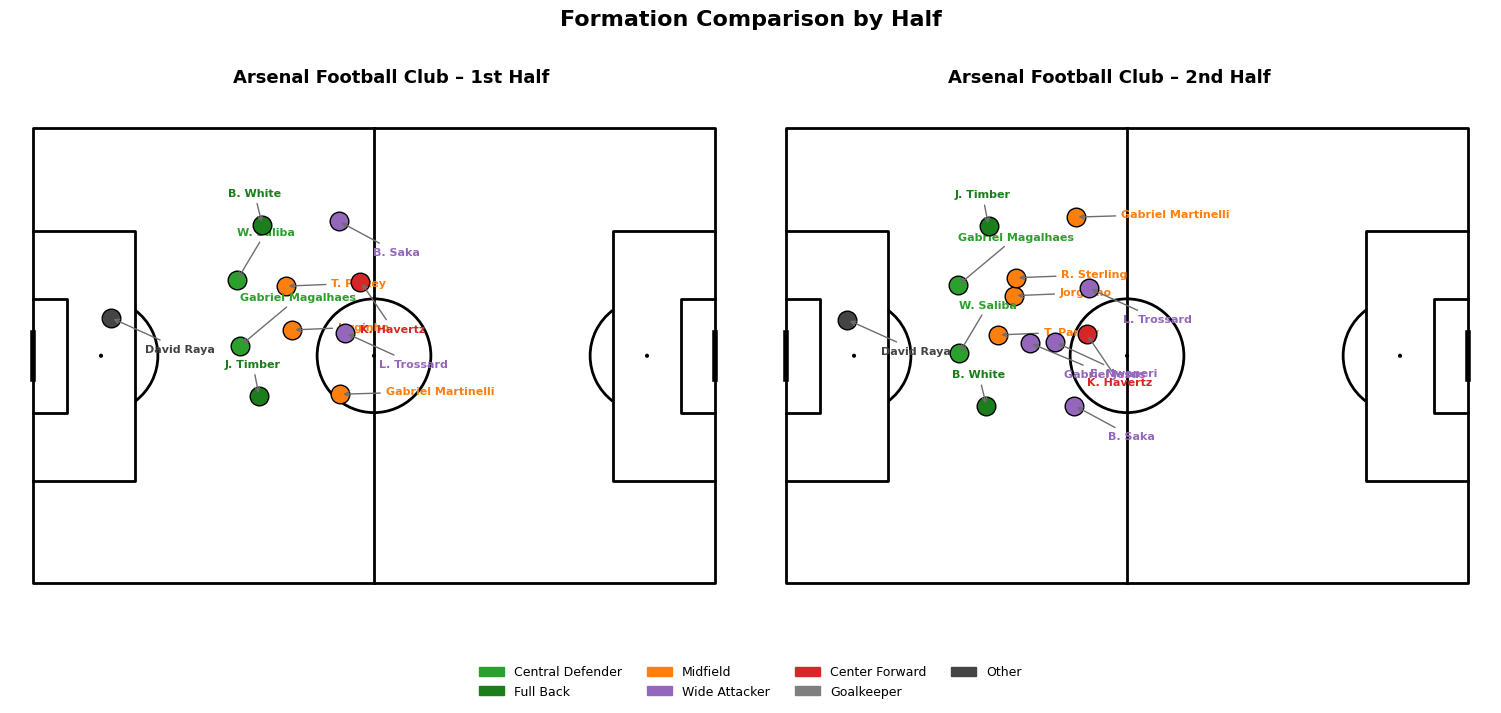

In [28]:
# Compute formations by half
avg_form_half = compute_average_formation_by_half(tr_norm)

# Plot for Arsenal
plot_formations_by_half(avg_form_half, team="Arsenal Football Club")


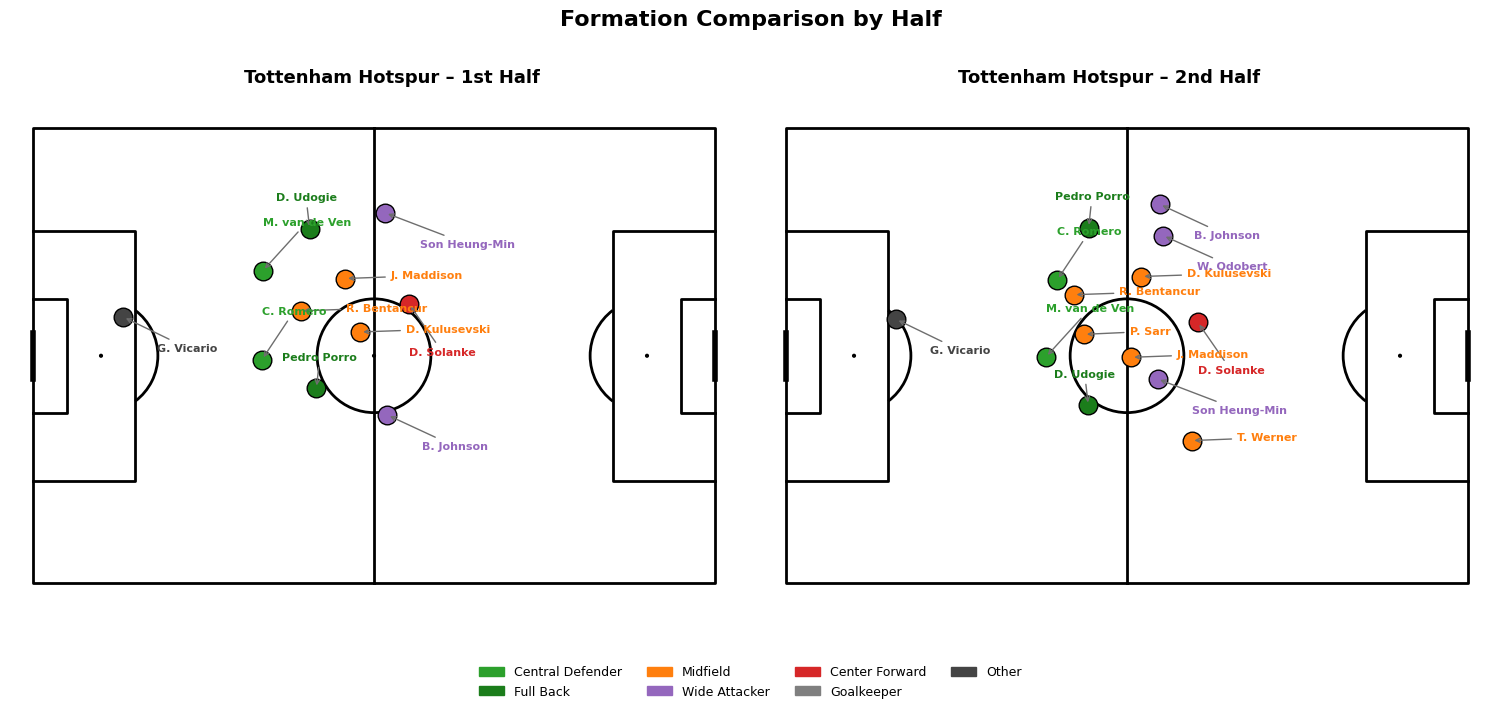

In [29]:
# Compute formations by half
avg_form_half = compute_average_formation_by_half(tr_norm)

# Plot for Arsenal
plot_formations_by_half(avg_form_half, team="Tottenham Hotspur")


How to interpret?

- Higher average positions in 2nd half = pressing more aggressively.

- Deeper positions = defending a lead.

Lesson: A single average formation hides tactical evolution.

In [30]:
ev_ex.event_type.value_counts()

event_type
passing_option        2234
player_possession      867
on_ball_engagement     781
off_ball_run           447
Name: count, dtype: int64

📘 Step 1. Build a Possession Mask from Events

We’ll say: if a player from Team A has an event like "player_possession" or "passing_option", then during that window Team A is in possession and Team B is out of possession.

In [31]:
ev_ex.columns

Index(['event_id', 'match_id', 'event_type', 'team_id', 'player_id',
       'time_start', 'time_end', 'frame_start', 'frame_end', 'attacking_side',
       'start_type', 'end_type', 'x_start', 'y_start', 'x_end', 'y_end',
       'period'],
      dtype='object')

In [32]:
tr_norm.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id', 'is_detected',
       'is_ball', 'x', 'y', 'x_rescaled', 'y_rescaled', 'ball_in_play',
       'team_id', 'team_name', 'team_short', 'position_group', 'player_role',
       'player_short_name', 'attacking_side', 'x_norm', 'y_norm'],
      dtype='object')

In [33]:
def build_possession_mask(events: pd.DataFrame, tracking: pd.DataFrame) -> pd.DataFrame:
    """
    Build a possession mask from events using frame_start / frame_end.
    For each frame in tracking, mark which team is in possession.
    """
    # keep only possession-relevant events
    ev_poss = events[events["event_type"].isin(["player_possession", "passing_option"])].copy()

    # make sure we have frame_start and frame_end
    if not {"frame_start", "frame_end"}.issubset(ev_poss.columns):
        raise ValueError("Events must contain frame_start and frame_end.")

    # merge to get team_id for each player in events
    ev_poss = ev_poss.merge(
        tracking[["match_id", "player_id", "team_id"]].drop_duplicates(),
        on=["match_id", "player_id"], how="left"
    )

    # expand into frame-level ranges
    pos_mask = []
    for _, row in ev_poss.iterrows():
        for fr in range(int(row["frame_start"]), int(row["frame_end"]) + 1):
            pos_mask.append({
                "match_id": row["match_id"],
                "frame": fr,
                "in_possession_team": row["team_id"]
            })

    df_mask = pd.DataFrame(pos_mask).drop_duplicates(["match_id", "frame"])

    # join back into tracking
    tracking = tracking.merge(df_mask, on=["match_id","frame"], how="left")

    return tracking


In [34]:
def build_possession_mask(events: pd.DataFrame, tracking: pd.DataFrame) -> pd.DataFrame:
    """
    Build a possession mask from events using frame_start / frame_end.
    For each frame in tracking, mark which team is in possession.
    """
    # keep only possession-relevant events
    ev_poss = events[events["event_type"].isin(["player_possession", "passing_option"])].copy()

    if ev_poss.empty:
        print("⚠️ No possession events found!")
        tracking["in_possession_team"] = np.nan
        return tracking

    # expand into frame-level mask
    pos_mask = []
    for _, row in ev_poss.iterrows():
        for fr in range(int(row["frame_start"]), int(row["frame_end"]) + 1):
            pos_mask.append({
                "match_id": row["match_id"],
                "frame": fr,
                "in_possession_team": row["team_id"]
            })

    df_mask = pd.DataFrame(pos_mask).drop_duplicates(["match_id", "frame"])

    # merge into tracking
    tracking = tracking.merge(df_mask, on=["match_id","frame"], how="left")

    return tracking


In [35]:
tr_with_pos = build_possession_mask(ev_ex, tr_norm)

# 4) Inspect
print(tr_with_pos[["frame","team_id","is_ball","in_possession_team"]].sample(50))

        frame  team_id  is_ball  in_possession_team
295623  17363     44.0    False                44.0
319982  18657     44.0    False                 NaN
442355  29334     44.0    False                 NaN
174874  10684     44.0    False                44.0
203350  11922     44.0    False                44.0
502021  33343      3.0    False                 NaN
757020  50006     44.0    False                 NaN
315886  18479     44.0    False                 NaN
828675  55172      3.0    False                 NaN
441675  29305      3.0    False                 3.0
381823  25070     44.0    False                 NaN
846036  56134      3.0    False                 3.0
689531  45655     44.0    False                 NaN
867058  57375      3.0    False                 3.0
653095  43096      3.0    False                 NaN
748612  48472      NaN     True                44.0
668190  44052     44.0    False                 3.0
688391  45525      3.0    False                 NaN
660941  4373

In [36]:
tr_with_pos.in_possession_team.value_counts()

in_possession_team
44.0    245870
3.0     116081
Name: count, dtype: int64

In [37]:
def compute_formations_in_out(tr_with_pos: pd.DataFrame) -> pd.DataFrame:
    """
    Compute average player positions separately for 
    in-possession vs out-of-possession frames.
    """
    # keep only valid player rows
    players = tr_with_pos[(~tr_with_pos["is_ball"]) & tr_with_pos[["x_norm","y_norm"]].notna().all(axis=1)].copy()

    # label phase: attack or defense
    players["phase"] = np.where(players["team_id"] == players["in_possession_team"],
                                "Attack (In Possession)",
                                "Defense (Out of Possession)")

    cols_id = ["match_id","team_id","team_name","team_short",
               "player_id","player_short_name","player_role","position_group","phase"]

    cols_id = [c for c in cols_id if c in players.columns]

    avg = (players
           .groupby(cols_id)[["x_norm","y_norm"]]
           .mean()
           .reset_index())
    return avg


In [38]:
tr_with_pos

,match_id,time,frame,period,player_id,is_detected,is_ball,x,y,x_rescaled,...,team_id,team_name,team_short,position_group,player_role,player_short_name,attacking_side,x_norm,y_norm,in_possession_team
0,1715920,00:00:00.00,10,1,18544,False,False,-31.68,-0.77,20.515385,...,3.0,Arsenal Football Club,Arsenal,Other,Goalkeeper,David Raya,left_to_right,20.515385,33.23,NaN
1,1715920,00:00:00.00,10,1,-1,True,True,0.41,0.82,52.913942,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.913942,34.82,NaN
2,1715920,00:00:00.00,10,1,2816,True,False,1.03,9.46,53.539904,...,44.0,Tottenham Hotspur,Tottenham,Center Forward,Center Forward,D. Solanke,right_to_left,51.460096,43.46,NaN
3,1715920,00:00:00.00,10,1,4314,True,False,0.45,-20.44,52.954327,...,44.0,Tottenham Hotspur,Tottenham,Wide Attacker,Left Forward,Son Heung-Min,right_to_left,52.045673,13.56,NaN
4,1715920,00:00:00.00,10,1,26671,True,False,4.43,15.64,56.972596,...,44.0,Tottenham Hotspur,Tottenham,Wide Attacker,Right Forward,B. Johnson,right_to_left,48.027404,49.64,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904056,1715920,01:35:44.90,59459,2,14155,True,False,37.33,5.64,90.188942,...,44.0,Tottenham Hotspur,Tottenham,Central Defender,Right Center Back,C. Romero,left_to_right,90.188942,39.64,NaN
904057,1715920,01:35:44.90,59459,2,19584,False,False,-14.07,4.29,38.294712,...,44.0,Tottenham Hotspur,Tottenham,Other,Goalkeeper,G. Vicario,left_to_right,38.294712,38.29,NaN
904058,1715920,01:35:44.90,59459,2,12485,True,False,24.74,3.31,77.477885,...,3.0,Arsenal Football Club,Arsenal,Center Forward,Center Forward,K. Havertz,right_to_left,27.522115,37.31,NaN
904059,1715920,01:35:44.90,59459,2,2816,True,False,43.87,1.35,96.791827,...,44.0,Tottenham Hotspur,Tottenham,Center Forward,Center Forward,D. Solanke,left_to_right,96.791827,35.35,NaN


In [39]:
compute_formations_in_out(tr_with_pos)

,match_id,team_id,team_name,team_short,player_id,player_short_name,player_role,position_group,phase,x_norm,y_norm
0,1715920,3.0,Arsenal Football Club,Arsenal,5365,Jorginho,Defensive Midfield,Midfield,Attack (In Possession),45.847465,35.078098
1,1715920,3.0,Arsenal Football Club,Arsenal,5365,Jorginho,Defensive Midfield,Midfield,Defense (Out of Possession),42.391840,31.934809
2,1715920,3.0,Arsenal Football Club,Arsenal,6109,L. Trossard,Left Forward,Wide Attacker,Attack (In Possession),58.736024,35.830023
3,1715920,3.0,Arsenal Football Club,Arsenal,6109,L. Trossard,Left Forward,Wide Attacker,Defense (Out of Possession),53.529687,32.139622
4,1715920,3.0,Arsenal Football Club,Arsenal,8846,R. Sterling,Left Midfield,Midfield,Attack (In Possession),52.257987,24.082079
5,1715920,3.0,Arsenal Football Club,Arsenal,8846,R. Sterling,Left Midfield,Midfield,Defense (Out of Possession),38.893946,26.579225
6,1715920,3.0,Arsenal Football Club,Arsenal,10324,T. Partey,Right Midfield,Midfield,Attack (In Possession),45.862580,36.506122
7,1715920,3.0,Arsenal Football Club,Arsenal,10324,T. Partey,Right Midfield,Midfield,Defense (Out of Possession),40.066385,31.579156
8,1715920,3.0,Arsenal Football Club,Arsenal,11500,Gabriel Jesus,Left Forward,Wide Attacker,Attack (In Possession),55.284854,45.544530
9,1715920,3.0,Arsenal Football Club,Arsenal,11500,Gabriel Jesus,Left Forward,Wide Attacker,Defense (Out of Possession),41.206577,36.686574


In [40]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

def plot_formations_in_out(avg_form: pd.DataFrame, team: str):
    """
    Plot in-possession (Attack) vs out-of-possession (Defense) formations for one team.
    """

    role_colors = {
        "Central Defender": "#2ca02c",
        "Full Back": "#1b7d1b",
        "Midfield": "#ff7f0e",
        "Wide Attacker": "#9467bd",
        "Center Forward": "#d62728",
        "Goalkeeper": "#7f7f7f",
        "Other": "#444444",
    }

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, axs = pitch.grid(nrows=1, ncols=2, figheight=7,
                          title_height=0.06, endnote_height=0.03,
                          axis=False, grid_width=0.9)

    team_form = avg_form[avg_form["team_name"] == team]

    for idx, phase in enumerate(["Attack (In Possession)", "Defense (Out of Possession)"]):
        df_phase = team_form[team_form["phase"]==phase]
        for _, row in df_phase.iterrows():
            color = role_colors.get(row["position_group"], "#333333")

            pitch.scatter(row["x_norm"], row["y_norm"],
                          s=180, c=color, edgecolors="black", ax=axs['pitch'][idx])
            axs['pitch'][idx].text(row["x_norm"], row["y_norm"]+2,
                                   row["player_short_name"], ha="center",
                                   fontsize=7, weight="bold", color=color)

        axs['title'].text((idx+0.5)/2, 0.5, f"{team} – {phase}", ha="center",
                          va="center", fontsize=13, weight="bold")

    fig.suptitle("Formation Comparison: Attack vs Defense", fontsize=16, weight="bold")
    plt.show()


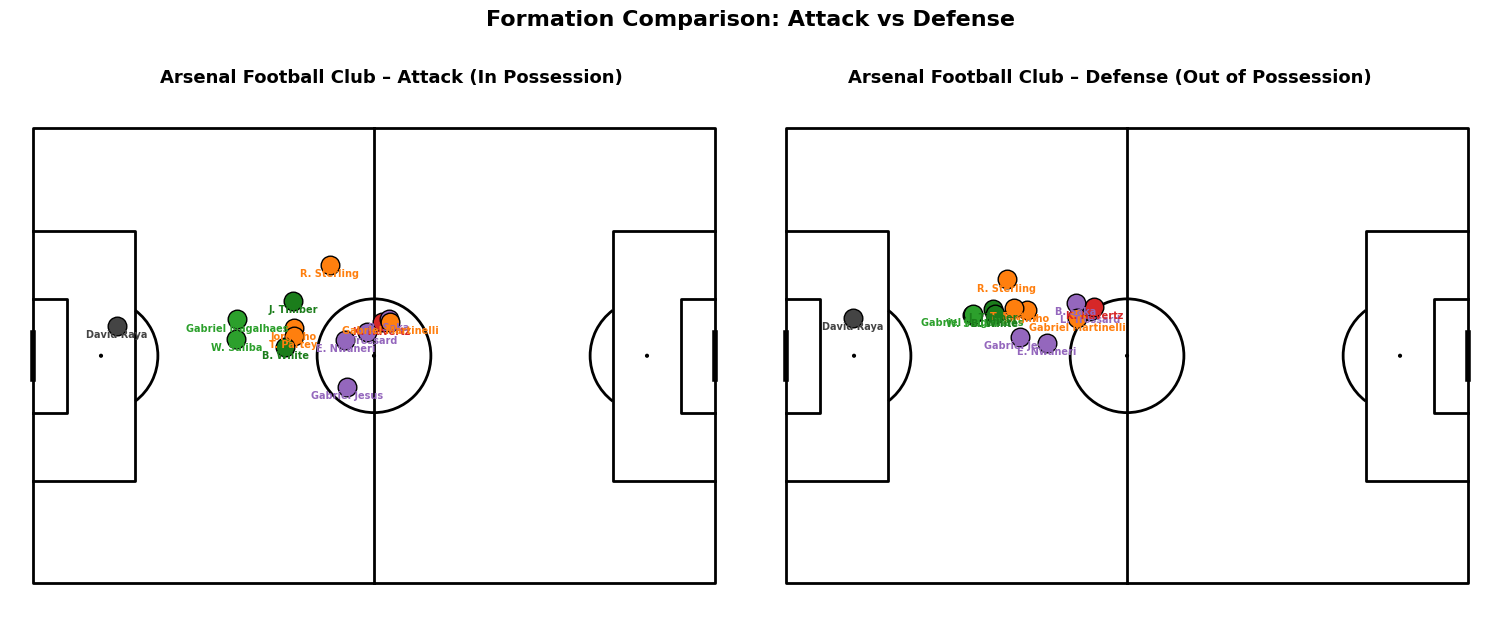

In [41]:
# 1) Compute average formations by phase
avg_form_inout = compute_formations_in_out(tr_with_pos)

# 2) Plot for Arsenal
plot_formations_in_out(avg_form_inout, team="Arsenal Football Club")


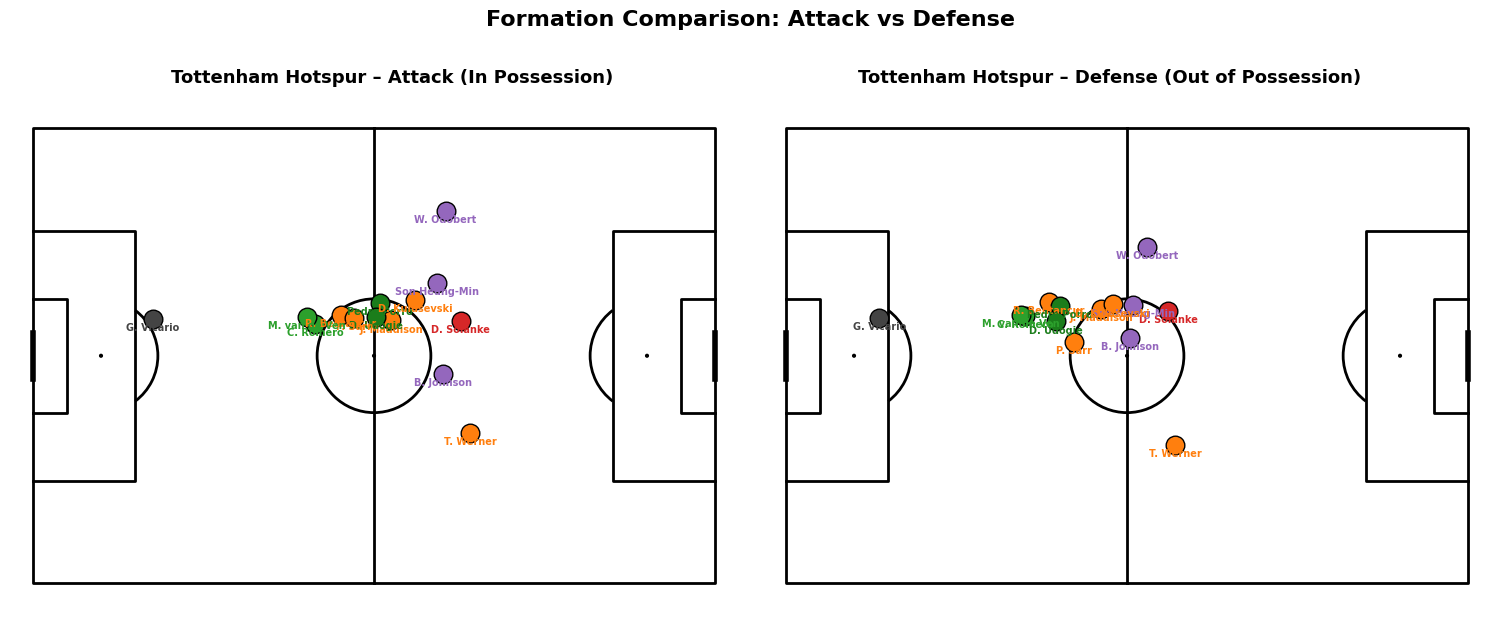

In [42]:
# 1) Compute average formations by phase
avg_form_inout = compute_formations_in_out(tr_with_pos)

# 2) Plot for Arsenal
plot_formations_in_out(avg_form_inout, team="Tottenham Hotspur")

In [43]:
tr_ex.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id', 'is_detected',
       'is_ball', 'x', 'y', 'x_rescaled', 'y_rescaled'],
      dtype='object')

In [44]:
ev_ex.columns

Index(['event_id', 'match_id', 'event_type', 'team_id', 'player_id',
       'time_start', 'time_end', 'frame_start', 'frame_end', 'attacking_side',
       'start_type', 'end_type', 'x_start', 'y_start', 'x_end', 'y_end',
       'period'],
      dtype='object')

When in possession, you’ll see full-backs higher/wider, midfield pushed up.

When out of possession, you’ll see compact lines, wingers dropping, strikers higher.

In [45]:
meta_ex.columns

Index(['match_id', 'player_id', 'team_id', 'team_name', 'team_short',
       'player_short_name', 'player_role', 'position_group', 'home_team_id',
       'away_team_id'],
      dtype='object')

In [45]:
PROCESSED_DIR = Path("processed_tracking")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def process_and_save_match(match_id: int) -> None:
    """
    Full pipeline for one match and save as Parquet.
    """
    try:
        outpath = PROCESSED_DIR / f"{match_id}.parquet"
        if outpath.exists():
            print(f"⏭️ Skipped {match_id} (already processed)")
            return

        tr = load_tracking_full(match_id, TRACKING_DIR)
        ev = load_events_basic(match_id)
        meta = load_meta_mapping(match_id)

        if tr.empty or ev.empty or meta.empty:
            print(f"⚠️ Skipped {match_id} (missing raw data)")
            return

        # Merge meta
        tr = tr.merge(
            meta[["match_id","player_id","team_id","team_name","team_short",
                  "player_short_name","player_role","position_group",
                  "home_team_id","away_team_id"]],
            on=["match_id","player_id"], how="left"
        )

        # Normalize direction
        tr = normalize_direction(tr, ev)

        # Ball in play
        kin = compute_ball_kinematics(tr)
        tr = make_ball_in_play_mask(tr, kin)

        # Filter ~11v11
        tr = filter_bip_and_11v11(tr)

        # Possession mask
        tr = build_possession_mask(ev, tr)
    

        # Save to Parquet
        tr.to_parquet(outpath, index=False)
        print(f"💾 Saved match {match_id} → {outpath.name} ({len(tr)} rows)")
        print(f"✅ Match {match_id}: {tr['frame'].nunique()} frames kept")

    except Exception as e:
        print(f"❌ Error processing {match_id}: {e}")


In [ ]:
#for mid in df_matches["id"].unique():
    #process_and_save_match(mid)


[match 1986708] rows: 841984, players: 805376, ball: 36608
💾 Saved match 1986708 → 1986708.parquet (790073 rows)
[match 1715920] rows: 963953, players: 922042, ball: 41911
💾 Saved match 1715920 → 1715920.parquet (904061 rows)
[match 2015001] rows: 965195, players: 923230, ball: 41965
💾 Saved match 2015001 → 2015001.parquet (902451 rows)
[match 1650385] rows: 939872, players: 899008, ball: 40864
💾 Saved match 1650385 → 1650385.parquet (891020 rows)
[match 2007863] rows: 1006963, players: 963182, ball: 43781
💾 Saved match 2007863 → 2007863.parquet (963332 rows)
[match 1939716] rows: 1056321, players: 1010394, ball: 45927
💾 Saved match 1939716 → 1939716.parquet (1019590 rows)
[match 2003493] rows: 947623, players: 906422, ball: 41201
💾 Saved match 2003493 → 2003493.parquet (897138 rows)
[match 1972418] rows: 977799, players: 935286, ball: 42513
💾 Saved match 1972418 → 1972418.parquet (910547 rows)
[match 1666921] rows: 977477, players: 934978, ball: 42499
💾 Saved match 1666921 → 1666921.p

34,351 frames ÷ 10 fps ≈ 3,435 s ≈ 57.25 min of ball-in-play → totally realistic for a PL match ✅

In [47]:
match_id= 1650385
fpath = PROCESSED_DIR / f"{match_id}.parquet"

tr = pd.read_parquet(fpath)

In [50]:
tr.columns

Index(['match_id', 'time', 'frame', 'period', 'player_id', 'is_detected',
       'is_ball', 'x', 'y', 'x_rescaled', 'y_rescaled', 'team_id', 'team_name',
       'team_short', 'player_short_name', 'player_role', 'position_group',
       'home_team_id', 'away_team_id', 'attacking_side', 'x_norm', 'y_norm',
       'ball_in_play', 'in_possession_team'],
      dtype='object')

In [51]:
tr.shape

(891020, 24)

Divide by 23 rows per frame ≈ 38,740 frames kept.

38,740 ÷ 10 fps ≈ 3,874 seconds = 64.5 minutes of ball-in-play.

# 📘 formation clustering — league wide 

what we’ll do:

1. build a per–team–match formation representation (average positions by role).

2. pivot into feature vectors.

3. choose features: absolute positions or shape-centered (subtract team centroid).

4. standardize, cluster (KMeans first), and score (elbow + silhouette).

5. visualize cluster centroids on a pitch.

## Step 1: Compute role averages per match & save

In [54]:
ROLE_AVG_DIR = Path("processed_formations")
ROLE_AVG_DIR.mkdir(parents=True, exist_ok=True)

def process_match_to_role_avg(match_id: int, min_frames=300):
    """
    Load processed tracking parquet and compute per-team average positions by role.
    """
    fpath = PROCESSED_DIR / f"{match_id}.parquet"
    if not fpath.exists():
        return

    tr = pd.read_parquet(fpath)

    # valid player rows
    players = tr[(~tr["is_ball"]) & tr[["x_norm","y_norm"]].notna().all(axis=1)].copy()
    if players.empty:
        return

    # frame count filter
    frames_per_team = (players.groupby(["match_id","team_id"])["frame"]
                             .nunique()
                             .reset_index(name="n_frames"))
    players = players.merge(frames_per_team, on=["match_id","team_id"], how="left")
    players = players[players["n_frames"] >= min_frames]

    if players.empty:
        return

    # average by role
    role_avg = (players
                .groupby(["match_id","team_id","team_name","team_short","position_group"])
                [["x_norm","y_norm"]]
                .mean()
                .reset_index())

    # save
    outpath = ROLE_AVG_DIR / f"{match_id}.parquet"
    role_avg.to_parquet(outpath, index=False)
    print(f"💾 Saved role averages for {match_id} ({len(role_avg)} rows)")


In [55]:
for f in PROCESSED_DIR.glob("*.parquet"):
    mid = int(f.stem)
    process_match_to_role_avg(mid)


💾 Saved role averages for 1986708 (12 rows)
💾 Saved role averages for 1715920 (12 rows)
💾 Saved role averages for 2015001 (12 rows)
💾 Saved role averages for 1650385 (12 rows)
💾 Saved role averages for 2007863 (12 rows)
💾 Saved role averages for 1939716 (12 rows)
💾 Saved role averages for 2003493 (12 rows)
💾 Saved role averages for 1972418 (12 rows)
💾 Saved role averages for 1666921 (12 rows)
💾 Saved role averages for 1968375 (12 rows)
💾 Saved role averages for 1711918 (12 rows)
💾 Saved role averages for 1934789 (11 rows)
💾 Saved role averages for 1889315 (12 rows)
💾 Saved role averages for 2016344 (11 rows)
💾 Saved role averages for 1949358 (12 rows)
💾 Saved role averages for 2004170 (12 rows)
💾 Saved role averages for 2003328 (11 rows)
💾 Saved role averages for 2009785 (12 rows)
💾 Saved role averages for 1895417 (11 rows)
💾 Saved role averages for 1766990 (12 rows)
💾 Saved role averages for 1729518 (12 rows)
💾 Saved role averages for 1651703 (11 rows)
💾 Saved role averages for 189717

In [56]:
match_id= 1650385
fpath = ROLE_AVG_DIR / f"{match_id}.parquet"

role_avg = pd.read_parquet(fpath)
role_avg

,match_id,team_id,team_name,team_short,position_group,x_norm,y_norm
0,1650385,31.0,Manchester United,Manchester U,Center Forward,60.263289,35.323925
1,1650385,31.0,Manchester United,Manchester U,Central Defender,38.856596,34.440319
2,1650385,31.0,Manchester United,Manchester U,Full Back,46.869883,37.339430
3,1650385,31.0,Manchester United,Manchester U,Midfield,54.583918,35.075699
4,1650385,31.0,Manchester United,Manchester U,Other,14.389867,34.640007
5,1650385,31.0,Manchester United,Manchester U,Wide Attacker,61.988984,34.497903
6,1650385,48.0,Fulham,Fulham,Center Forward,57.834146,34.821836
7,1650385,48.0,Fulham,Fulham,Central Defender,35.623164,34.896720
8,1650385,48.0,Fulham,Fulham,Full Back,41.423445,34.841339
9,1650385,48.0,Fulham,Fulham,Midfield,48.010643,36.640723


## Step 2: Load league-wide summary (tiny!)

In [59]:
def load_league_role_avg(match_ids=None) -> pd.DataFrame:
    files = list(ROLE_AVG_DIR.glob("*.parquet"))
    if match_ids is not None:
        files = [f for f in files if int(f.stem) in match_ids]

    dfs = [pd.read_parquet(f) for f in files]
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

role_avg_league = load_league_role_avg()
print("📊 League-wide role averages:", role_avg_league.shape)


📊 League-wide role averages: (4477, 7)


In [60]:
role_avg_league

,match_id,team_id,team_name,team_short,position_group,x_norm,y_norm
0,1986708,60.0,Crystal Palace,Crystal Palace,Center Forward,66.352832,35.990751
1,1986708,60.0,Crystal Palace,Crystal Palace,Central Defender,40.200903,34.507524
2,1986708,60.0,Crystal Palace,Crystal Palace,Full Back,48.242447,34.472057
3,1986708,60.0,Crystal Palace,Crystal Palace,Midfield,50.302362,34.394915
4,1986708,60.0,Crystal Palace,Crystal Palace,Other,15.005025,34.148567
...,...,...,...,...,...,...,...
4472,2017616,58.0,Southampton,Southampton,Central Defender,36.522595,35.154453
4473,2017616,58.0,Southampton,Southampton,Full Back,45.745029,34.905802
4474,2017616,58.0,Southampton,Southampton,Midfield,48.659232,36.249150
4475,2017616,58.0,Southampton,Southampton,Other,15.018035,34.349236


### 1) Single Team Aggregated Formation

In [69]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_team_formation(role_avg: pd.DataFrame, team_name: str, dot_size=100):
    """
    Plot average formation of one team across all matches, with a legend instead of text labels.
    """
    df = role_avg[role_avg["team_name"] == team_name]

    if df.empty:
        print(f"⚠️ No data for {team_name}")
        return

    # average across matches
    agg = (df.groupby(["team_name","position_group"])
             [["x_norm","y_norm"]].mean().reset_index())

    # role-based colors
    role_colors = {
        "Goalkeeper": "#7f7f7f",
        "Central Defender": "#2ca02c",
        "Full Back": "#1b7d1b",
        "Midfield": "#ff7f0e",
        "Wide Attacker": "#9467bd",
        "Center Forward": "#d62728",
    }

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, ax = pitch.draw(figsize=(7,5))

    for _, r in agg.iterrows():
        c = role_colors.get(r["position_group"], "#333333")
        pitch.scatter(r["x_norm"], r["y_norm"], s=dot_size,
                      c=c, edgecolors="black", ax=ax, zorder=3)

    # --- Legend ---
    legend_handles = [mpatches.Patch(color=color, label=role)
                      for role, color in role_colors.items()]
    ax.legend(handles=legend_handles, loc="upper center",
              bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=8,
              frameon=False)

    ax.set_title(f"Average Formation – {team_name}", fontsize=14, weight="bold")
    plt.show()


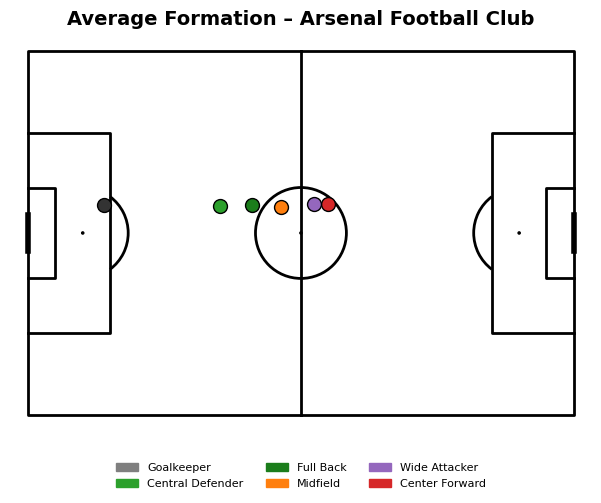

In [70]:
plot_team_formation(role_avg_league, "Arsenal Football Club")


## 2) Side-by-Side Comparison of Two Teams

In [71]:
def plot_team_vs_team(role_avg: pd.DataFrame, team1: str, team2: str, dot_size=300):
    """
    Compare average formations of two teams side by side.
    """
    def _aggregate(team_name):
        return (role_avg[role_avg["team_name"] == team_name]
                .groupby(["team_name","position_group"])
                [["x_norm","y_norm"]].mean().reset_index())

    t1, t2 = _aggregate(team1), _aggregate(team2)

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, axs = pitch.grid(nrows=1, ncols=2, figheight=6,
                          title_height=0.08, endnote_height=0.03,
                          axis=False, grid_width=0.9)

    role_colors = {
        "Goalkeeper": "#7f7f7f",
        "Central Defender": "#2ca02c",
        "Full Back": "#1b7d1b",
        "Midfield": "#ff7f0e",
        "Wide Attacker": "#9467bd",
        "Center Forward": "#d62728",
    }

    def _plot(df, ax, title):
        for _, r in df.iterrows():
            c = role_colors.get(r["position_group"], "#333333")
            pitch.scatter(r["x_norm"], r["y_norm"], s=dot_size, c=c, edgecolors="black", ax=ax, zorder=3)
            ax.text(r["x_norm"], r["y_norm"]+1.5, r["position_group"], ha="center",
                    fontsize=8, weight="bold", color=c)
        ax.set_title(title, fontsize=12, weight="bold")

    _plot(t1, axs['pitch'][0], team1)
    _plot(t2, axs['pitch'][1], team2)

    fig.suptitle("Average Formations – Team Comparison", fontsize=16, weight="bold")
    plt.show()


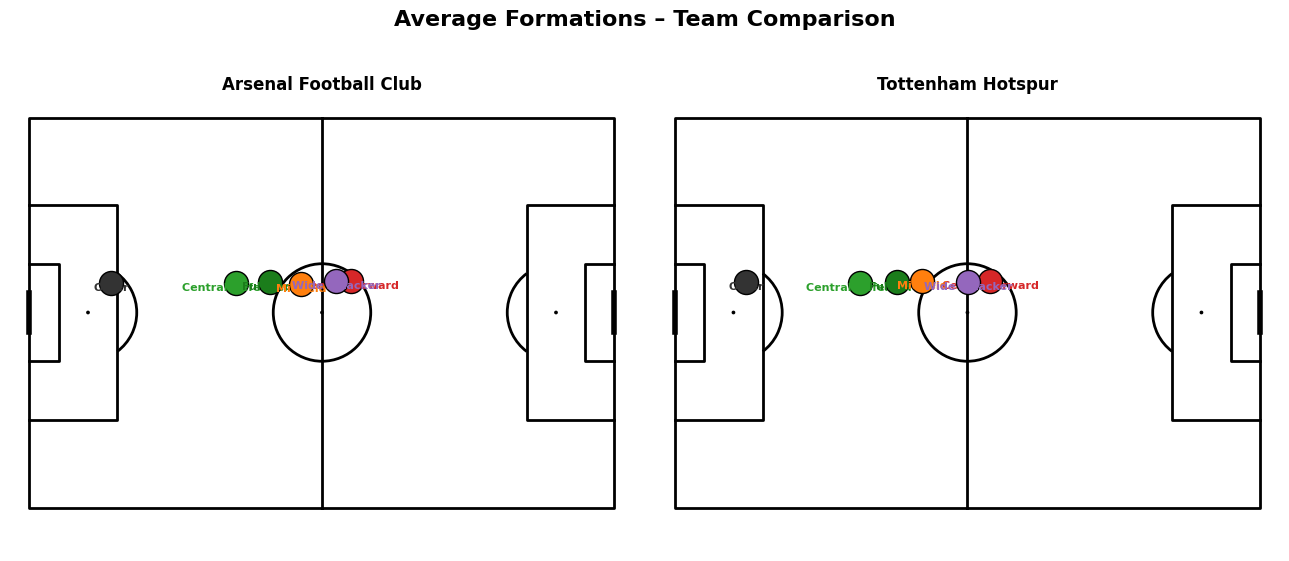

In [72]:
plot_team_vs_team(role_avg_league, "Arsenal Football Club", "Tottenham Hotspur")


### 3) Grid of All Teams in the League

In [75]:
def plot_league_formations(role_avg: pd.DataFrame, dot_size=200, ncols=4):
    """
    Grid visualization of all teams' average formations, with legend.
    """
    teams = sorted(role_avg["team_name"].unique())
    nrows = int(np.ceil(len(teams) / ncols))

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, axs = pitch.grid(nrows=nrows, ncols=ncols, figheight=3*nrows,
                          title_height=0.08, endnote_height=0.03,
                          axis=False, grid_width=0.9)

    # flatten axes (important!)
    axes = axs['pitch'].flatten()

    role_colors = {
        "Goalkeeper": "#7f7f7f",
        "Central Defender": "#2ca02c",
        "Full Back": "#1b7d1b",
        "Midfield": "#ff7f0e",
        "Wide Attacker": "#9467bd",
        "Center Forward": "#d62728",
    }

    for idx, team in enumerate(teams):
        ax = axes[idx]
        agg = (role_avg[role_avg["team_name"] == team]
               .groupby(["team_name","position_group"])
               [["x_norm","y_norm"]].mean().reset_index())

        for _, r in agg.iterrows():
            c = role_colors.get(r["position_group"], "#333333")
            pitch.scatter(r["x_norm"], r["y_norm"], s=dot_size, c=c,
                          edgecolors="black", ax=ax, zorder=3)

        ax.set_title(team, fontsize=9, weight="bold")

    # legend (outside of subplots)
    import matplotlib.patches as mpatches
    legend_handles = [mpatches.Patch(color=color, label=role)
                      for role, color in role_colors.items()]
    fig.legend(handles=legend_handles, loc="lower center", ncol=3,
               fontsize=8, frameon=False)

    fig.suptitle("Average Formations – League Overview", fontsize=16, weight="bold")
    plt.show()


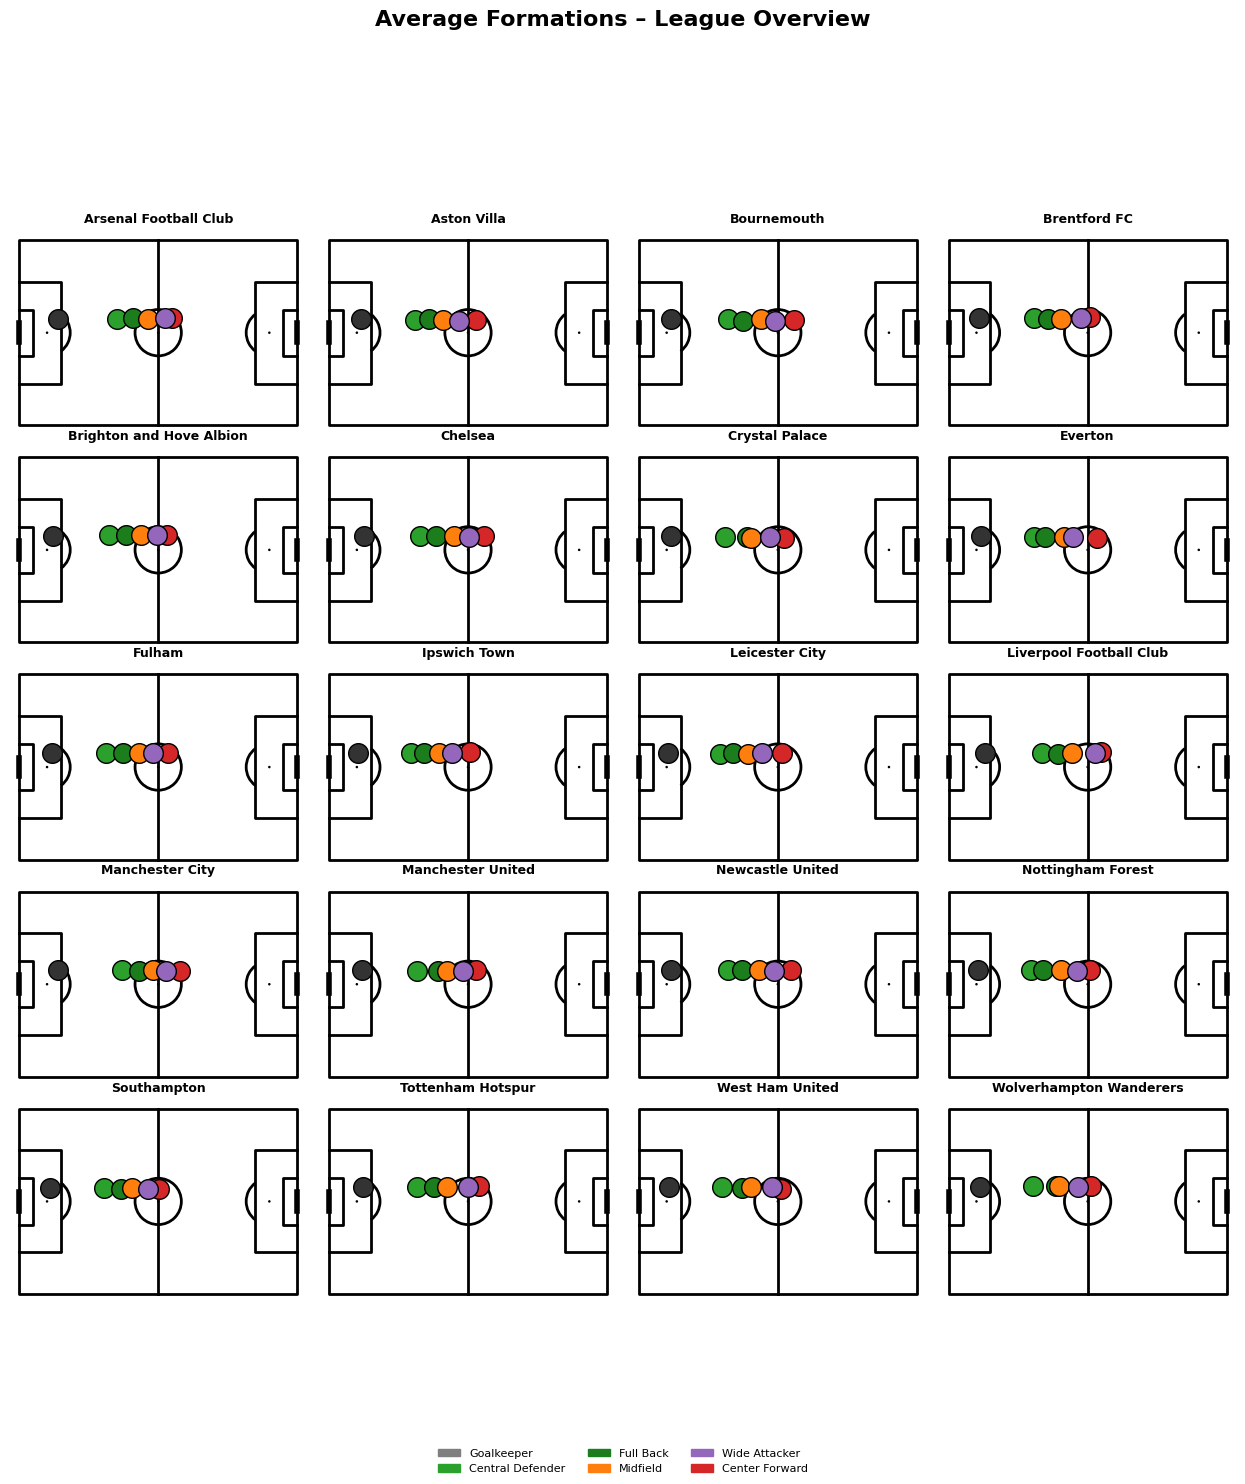

In [76]:
plot_league_formations(role_avg_league, ncols=4)


filter by phase (attack vs defense) before plotting, so you can present “league-wide attacking formations” vs “league-wide defensive formations”

Now we’ll switch from “single average point per role” to a distributional view per role and then do agglomerative clustering with an EMD-style distance between formations.

# Step 1 — Turn tracking points into role “heatmaps” (probability maps)

## What & why (in simple words)

For each team in a match, and for each role (e.g., Central Defender, Full Back, Midfield …), we collect all their (x_norm, y_norm) positions (already direction-normalized, ball-in-play).

We put these points into a 2D grid over the pitch (like pixels), count how many points fall into each cell, then normalize so that the whole grid sums to 1.
→ That gives a probability density of where this role tends to stand on the pitch for that match.

Later, we’ll compare two formations by comparing their role probability maps using Earth Mover’s Distance (EMD).

EMD idea (kid version): imagine the heatmap as little piles of sand. EMD asks: how much effort does it take to move the sand from one heatmap to reshape it into the other?

If two formations are similar, only a little sand needs to move → small EMD. If they’re very different, lots of sand must move → large EMD.

for now, we only build & save those per-role heatmaps (one file per team per match). this keeps memory usage tiny and speeds up later clustering.

### Code — build and save role heatmaps (per team–match)

📌 Assumptions: you already have per-match processed parquet in processed_tracking/ produced by your pipeline (so columns like x_norm, y_norm, ball_in_play, position_group, team_id, … exist).

In [92]:
# ==== CONFIG (adjust once) ==========================================
from pathlib import Path
import numpy as np
import pandas as pd

# Where your processed tracking parquet files live (one per match)
PROCESSED_DIR = Path("processed_tracking")

# Where we'll save role heatmaps (one .npz per match-team)
ROLEMAP_DIR = Path("role_heatmaps")
ROLEMAP_DIR.mkdir(parents=True, exist_ok=True)

# Grid resolution for heatmaps (coarser = faster, smoother)
NBINS_X, NBINS_Y = 24, 16  # works well; feel free to tweak

# Roles to include (match your position_group values)
ROLES = ["Central Defender", "Full Back", "Midfield", "Wide Attacker", "Center Forward"]
# You can add "Goalkeeper" / "Other" if you want them included.

# Minimum number of unique frames to accept a team sample (avoid tiny samples)
MIN_FRAMES_PER_TEAM = 300  # ~30 seconds at 10 fps
# ====================================================================

def _hist2d_prob(x, y, x_edges, y_edges):
    """
    2D histogram normalized to sum=1 (probability map). If no points, returns all zeros.
    """
    H, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    s = H.sum()
    return H / s if s > 0 else H

def build_and_save_role_heatmaps_for_match(match_id: int,
                                           processed_dir: Path = PROCESSED_DIR,
                                           rolemaps_dir: Path = ROLEMAP_DIR,
                                           roles=ROLES,
                                           bins_x=NBINS_X, bins_y=NBINS_Y,
                                           min_frames_per_team=MIN_FRAMES_PER_TEAM):
    """
    For a given match:
      - loads processed tracking parquet
      - filters to ball-in-play, non-ball, valid coords
      - builds per-role probability maps for each team
      - saves one compressed .npz per (match_id, team_id)
    """
    f = processed_dir / f"{match_id}.parquet"
    if not f.exists():
        print(f"⚠️ No processed file for match {match_id}")
        return

    tr = pd.read_parquet(f)

    # basic safety checks
    needed_cols = {"x_norm","y_norm","is_ball","ball_in_play","position_group","team_id","team_name","team_short","frame"}
    missing = needed_cols - set(tr.columns)
    if missing:
        raise ValueError(f"Processed file {f} missing columns: {missing}")

    # keep valid player rows (not ball, ball-in-play, has coords)
    players = tr[(~tr["is_ball"]) & tr["ball_in_play"] & tr[["x_norm","y_norm"]].notna().all(axis=1)].copy()
    if players.empty:
        print(f"⚠️ No valid player rows after filtering for match {match_id}")
        return

    # ensure enough frames per team (avoid tiny/noisy samples)
    frames_per_team = (players.groupby(["match_id","team_id"])["frame"]
                       .nunique().rename("n_frames").reset_index())
    players = players.merge(frames_per_team, on=["match_id","team_id"], how="left")
    players = players[players["n_frames"] >= min_frames_per_team]
    if players.empty:
        print(f"⚠️ Match {match_id} — no team reached min_frames={min_frames_per_team}")
        return

    # define bin edges (StatsBomb/FIFA scale)
    x_edges = np.linspace(0, 105, bins_x+1)
    y_edges = np.linspace(0,  68, bins_y+1)

    # build per-team → per-role heatmaps
    for (team_id, team_name, team_short), gteam in players.groupby(["team_id","team_name","team_short"]):
        role_maps = {}
        for role in roles:
            grole = gteam[gteam["position_group"] == role]
            if grole.empty:
                role_maps[role] = np.zeros((bins_x, bins_y), dtype=float)
            else:
                H = _hist2d_prob(grole["x_norm"].values, grole["y_norm"].values, x_edges, y_edges)
                # histogram2d returns shape (bins_x, bins_y)
                role_maps[role] = H

        # save one file per team–match
        out = rolemaps_dir / f"{match_id}_{int(team_id)}.npz"
        np.savez_compressed(
            out,
            match_id=int(match_id),
            team_id=int(team_id),
            team_name=str(team_name),
            team_short=str(team_short),
            x_edges=x_edges,
            y_edges=y_edges,
            **{f"role__{r}": role_maps[r] for r in roles}
        )
        print(f"💾 saved {out.name} ({team_short}) with {len(roles)} roles @ {bins_x}x{bins_y} bins")


In [93]:
# pick one processed match to test
# (or set match_id = 1715920 or any known id you processed)
any_file = next(PROCESSED_DIR.glob("*.parquet"))
match_id = int(any_file.stem)
match_id


1986708

In [94]:
# build + save role heatmaps for that match
build_and_save_role_heatmaps_for_match(match_id)


💾 saved 1986708_60.npz (Crystal Palace) with 5 roles @ 24x16 bins
💾 saved 1986708_754.npz (Brentford FC) with 5 roles @ 24x16 bins


In [95]:
# load the saved npz to inspect its contents
test_npz = ROLEMAP_DIR / f"{match_id}_"  # we don't know team_id yet; list them
list(ROLEMAP_DIR.glob(f"{match_id}_*.npz"))


[PosixPath('role_heatmaps/1986708_60.npz'),
 PosixPath('role_heatmaps/1986708_754.npz')]

In [96]:
# pick one team file and inspect shapes and sums
sample_file = list(ROLEMAP_DIR.glob(f"{match_id}_*.npz"))[0]
data = np.load(sample_file, allow_pickle=True)
print("keys:", list(data.keys()))
print("team:", data["team_short"])
print("x_edges shape:", data["x_edges"].shape, "y_edges shape:", data["y_edges"].shape)

# each role map should sum to ~1 (probability map)
for role in ROLES:
    H = data[f"role__{role}"]
    print(role, H.shape, "sum=", float(H.sum()))


keys: ['match_id', 'team_id', 'team_name', 'team_short', 'x_edges', 'y_edges', 'role__Central Defender', 'role__Full Back', 'role__Midfield', 'role__Wide Attacker', 'role__Center Forward']
team: Crystal Palace
x_edges shape: (25,) y_edges shape: (17,)
Central Defender (24, 16) sum= 1.0
Full Back (24, 16) sum= 1.0
Midfield (24, 16) sum= 1.0
Wide Attacker (24, 16) sum= 1.0
Center Forward (24, 16) sum= 1.0


You should see:

- Each role__… array has shape (NBINS_X, NBINS_Y) and sum ~ 1.0 (within floating-point error).

- If a role didn’t appear, its map is all zeros (sum = 0.0). That’s fine; the clustering code will handle it.

(Optional) Quick visual check for one role heatmap

This helps you “see” the probability map for one role.

In [101]:
data

NpzFile 'role_heatmaps/1986708_60.npz' with keys: match_id, team_id, team_name, team_short, x_edges...

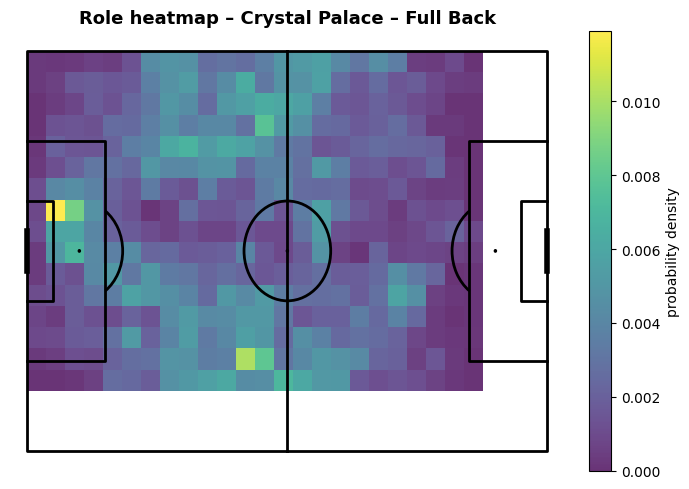

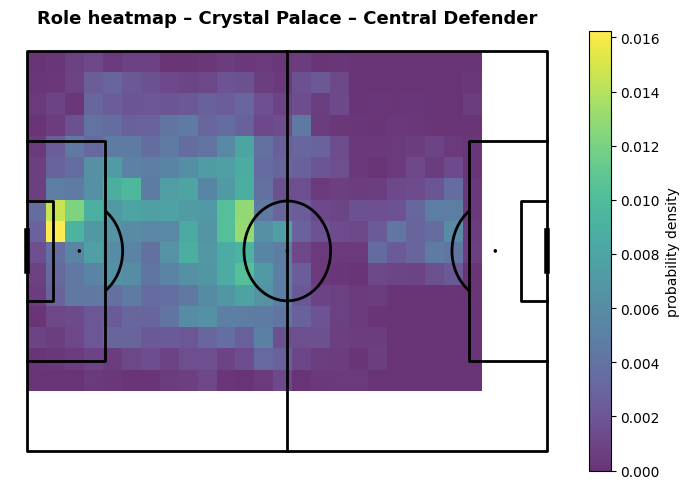

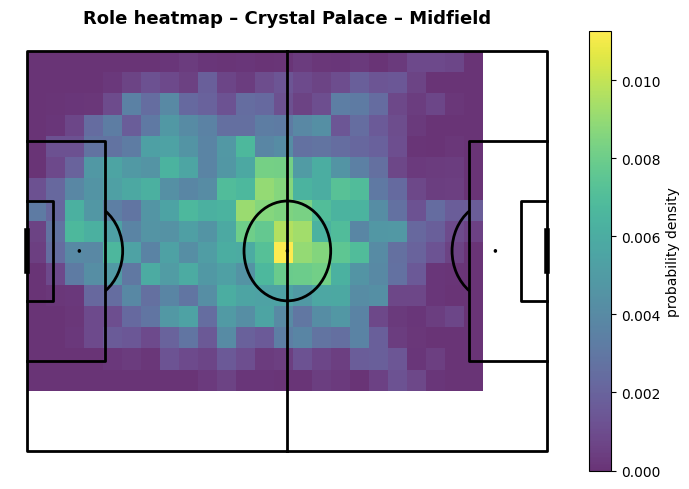

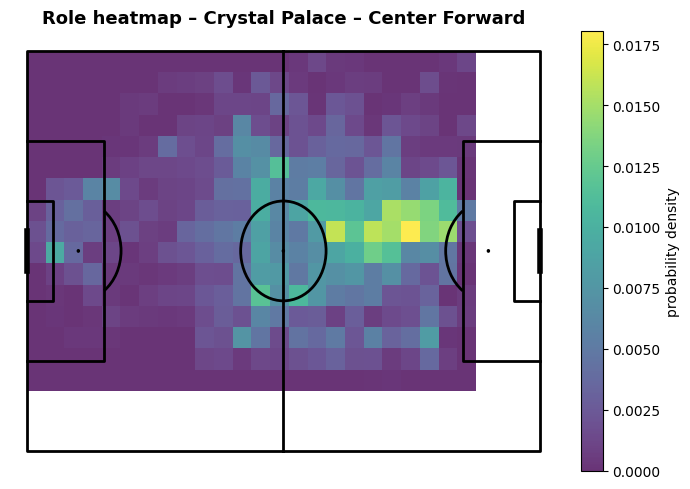

In [103]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

for role_to_plot in ["Full Back", "Central Defender", "Midfield", "Center Forward"]:

    H = data[f"role__{role_to_plot}"]
    x_edges = data["x_edges"]; y_edges = data["y_edges"]

    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                pitch_color='white', line_color='black')
    fig, ax = pitch.draw(figsize=(7,5))

    # use bin edges (not centers) as extent
    im = ax.imshow(H.T, origin="lower",
                extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
                aspect="auto", alpha=0.8)

    ax.set_title(f"Role heatmap – {str(data['team_short'])} – {role_to_plot}", fontsize=13, weight="bold")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="probability density")
    plt.show()


# Step 2 — Distance between two formations (EMD on role heatmaps)

## What are we measuring?

We want a number that says how different two team formations are.
Each formation (for one team in one match) is represented by role heatmaps—probability maps over the pitch for:

Central Defender, Full Back, Midfield, Wide Attacker, Center Forward (your ROLES)

## Earth Mover’s Distance (EMD), in plain words

Imagine each heatmap as piles of sand spread across the pitch.

EMD asks: how much work is needed to move the sand from heatmap A to reshape it into heatmap B?

If two formations are similar (players stand in similar areas), only small moves are needed → small EMD.

If they’re very different (e.g., back 3 vs back 4, 1 striker vs 2), lots of sand must move → large EMD.

## 2D vs 1D EMD (and why we use 1D marginals)

True 2D EMD requires optimal transport on a 2D grid (heavier, extra deps).

A fast, effective approximation is to compare x- and y- marginals separately:

Collapse the 2D heatmap along y to get a distribution over x (left–right shape).

Collapse along x to get a distribution over y (depth/front–back shape).

Compute 1D EMD (a.k.a. Wasserstein distance) on each marginal, then sum them.

This captures the key formation differences (back line height, width, 1 vs 2 strikers, etc.) with simple code.

## What exactly we’ll compute

For two formations A and B:

1. For each role:

Take A’s role heatmap H_A and B’s role heatmap H_B.

Compute x-marginals (H.sum(axis=1)) and y-marginals (H.sum(axis=0)).

Normalize each marginal so it sums to 1 (probability).

Compute 1D EMD between A and B marginals using the bin centers as coordinates.

Add the two numbers: emd_x + emd_y.

2. Sum over all roles to get the final formation distance.

Notes:

If a role map is empty in both formations (no data), it contributes 0.

Heatmaps must use the same bin edges across matches (we made that true when saving the .npz files).

In [120]:
import numpy as np
from scipy.stats import wasserstein_distance

# Make sure this matches what you used when saving
ROLES = ["Central Defender", "Full Back", "Midfield", "Wide Attacker", "Center Forward"]

def _marginals_xy(H: np.ndarray):
    """
    From a 2D heatmap H (bins_x, bins_y), return:
      - mx: distribution over x bins (sum along y)
      - my: distribution over y bins (sum along x)
    """
    mx = H.sum(axis=1)  # shape (bins_x,)
    my = H.sum(axis=0)  # shape (bins_y,)
    return mx, my

def _bin_centers(edges: np.ndarray):
    """Centers from bin edges."""
    return 0.5 * (edges[:-1] + edges[1:])

def load_sample_npz(npz_path: str) -> dict:
    """
    Load one team–match formation sample saved by Step 1 and return a dict:
      {
        'match_id', 'team_id', 'team_short',
        'x_edges', 'y_edges',
        'roles': { role_name: 2D array (bins_x, bins_y) }
      }
    """
    d = np.load(npz_path, allow_pickle=True)
    sample = {
        "match_id": int(d["match_id"]),
        "team_id": int(d["team_id"]),
        "team_short": str(d["team_short"]),
        "x_edges": d["x_edges"],
        "y_edges": d["y_edges"],
        "roles": {}
    }
    for r in ROLES:
        sample["roles"][r] = d[f"role__{r}"]
    return sample

from scipy.stats import wasserstein_distance

def formation_distance(sampleA: dict, sampleB: dict) -> float:
    """
    Sum over roles of [ EMD_x + EMD_y ] on the role histograms' marginals.
    Handles empty role maps safely.
    """
    if not (np.allclose(sampleA["x_edges"], sampleB["x_edges"]) and
            np.allclose(sampleA["y_edges"], sampleB["y_edges"])):
        raise ValueError("Bin edges differ between samples – ensure consistent binning when saving.")

    x_centers = _bin_centers(sampleA["x_edges"])
    y_centers = _bin_centers(sampleA["y_edges"])

    total = 0.0
    for role in ROLES:
        HA = sampleA["roles"][role]
        HB = sampleB["roles"][role]

        # both empty → no contribution
        if HA.sum() == 0 and HB.sum() == 0:
            continue

        Ax, Ay = _marginals_xy(HA)
        Bx, By = _marginals_xy(HB)

        # normalize safely
        def safe_norm(v):
            if v.sum() > 0 and np.isfinite(v.sum()):
                return v / v.sum()
            else:
                # fallback: uniform distribution
                return np.ones_like(v) / len(v)

        Ax, Ay = safe_norm(Ax), safe_norm(Ay)
        Bx, By = safe_norm(Bx), safe_norm(By)

        emd_x = wasserstein_distance(x_centers, x_centers, Ax, Bx)
        emd_y = wasserstein_distance(y_centers, y_centers, Ay, By)

        total += (emd_x + emd_y)

    return float(total)



In [121]:
from pathlib import Path

ROLEMAP_DIR = Path("role_heatmaps")

# pick two saved formation files (two teams or two matches)
files = sorted(ROLEMAP_DIR.glob("*.npz"))
print(f"Found {len(files)} samples")
assert len(files) >= 2, "You need at least two saved samples to test distance."

sA = load_sample_npz(str(files[0]))
sB = load_sample_npz(str(files[1]))

d = formation_distance(sA, sB)
print(f"Distance between {sA['team_short']} (match {sA['match_id']}) and {sB['team_short']} (match {sB['match_id']}): {d:.3f}")


Found 756 samples
Distance between Manchester U (match 1650385) and Fulham (match 1650385): 36.477


If two samples are the same team in similar matches, you should see a smaller number.

If they’re very different (e.g., back-3 vs back-4), you should see a larger number.

✅ What you’ll have after Step 2

A function that compares any two formations (team–match samples) as a single distance number.

This is the building block for:

making a distance matrix across all samples, and

running agglomerative clustering (Step 3), where we’ll pick e.g. 6 clusters and then visualize the clusters (Step 4).

# Step 3 — Build a Distance Matrix and Run Agglomerative Clustering

## 🔎 Why do we need a distance matrix?
- We now have a way to compute a **distance between two formations** (from Step 2).  
- To cluster multiple formations, we need to compute the **distance for every pair** of samples.  
- This gives us a **distance matrix** `D` of shape `(n_samples, n_samples)`.  
  - `D[i, j]` = distance between formation `i` and formation `j`.  
  - `D[i, i] = 0` (a formation is identical to itself).  

## 🧩 What is agglomerative clustering?
- **Agglomerative clustering** starts with each sample in its own cluster.  
- Then, step by step, it merges the two closest clusters (based on the distance matrix).  
- This forms a **hierarchy** (a dendrogram).  
- You can “cut” the tree at a chosen height to get a certain number of clusters (e.g., 6).  

## 📏 What is a “high” vs “low” distance?
- A **low distance** means the formations are very similar (little sand needs to move).  
- A **high distance** means the formations are very different.  
- The *absolute values* depend on your binning and scale.  
  - Example: in our test, distance ≈ **27** between Crystal Palace and Brentford is somewhere in the middle.  
  - Once you compute all pairwise distances, you’ll see the full range (e.g., 5 → 60). Then you can tell which are relatively low or high.  

---



In [113]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

def build_distance_matrix(samples):
    """
    Build a full pairwise distance matrix between formation samples.
    samples: list of dicts (from load_sample_npz)
    Returns:
        D (n x n numpy array), order of samples
    """
    n = len(samples)
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i+1, n):
            d = formation_distance(samples[i], samples[j])
            D[i, j] = D[j, i] = d
    return D

# === Example usage on your current samples (one match only) ===

# Collect all samples for the match
files = sorted(ROLEMAP_DIR.glob("*.npz"))
samples = [load_sample_npz(str(f)) for f in files]

# Build distance matrix
D = build_distance_matrix(samples)
print("Distance matrix:\n", D)

# Run agglomerative clustering
# ✅ In scikit-learn >= 1.2, use `metric` instead of `affinity`
agg = AgglomerativeClustering(n_clusters=2, metric='precomputed', linkage='average')
labels = agg.fit_predict(D)

for s, lab in zip(samples, labels):
    print(f"Team {s['team_short']} → Cluster {lab}")

Distance matrix:
 [[ 0.         36.47662077 25.08844619 ... 78.755171   37.67817011
  41.51317137]
 [36.47662077  0.         43.45552716 ... 53.54746656 49.55697753
  34.63398176]
 [25.08844619 43.45552716  0.         ... 81.38374436 26.62794385
  31.249368  ]
 ...
 [78.755171   53.54746656 81.38374436 ...  0.         81.7281885
  59.86200361]
 [37.67817011 49.55697753 26.62794385 ... 81.7281885   0.
  29.62222142]
 [41.51317137 34.63398176 31.249368   ... 59.86200361 29.62222142
   0.        ]]
Team Manchester U → Cluster 0
Team Fulham → Cluster 0
Team Liverpool → Cluster 0
Team Ipswich Town → Cluster 0
Team West Ham → Cluster 0
Team Aston Villa → Cluster 0
Team Arsenal → Cluster 0
Team Wolverhampton → Cluster 0
Team Brighton → Cluster 0
Team Everton → Cluster 0
Team Newcastle → Cluster 0
Team Southampton → Cluster 0
Team Crystal Palace → Cluster 0
Team Brentford FC → Cluster 0
Team Manchester City → Cluster 0
Team Chelsea → Cluster 0
Team Tottenham → Cluster 0
Team Leicester → Cluste

# Step 4 — Visualize the Dendrogram and Cluster Prototypes

## 🌳 Why a dendrogram?
- Agglomerative clustering produces a **hierarchy** of clusters.  
- A **dendrogram** is a tree diagram that shows at which distance different formations (samples) were merged.  
- By looking at the dendrogram, you can decide where to “cut” the tree (e.g., 6 clusters).  

## 👥 What are cluster prototypes?
- Once we cut the hierarchy into clusters, we can summarize each cluster by a **prototype formation**.  
- The prototype is created by:
  1. Averaging the **role heatmaps** across all samples in the cluster.  
  2. Computing the **expected x,y location** of each role (the centroid of its heatmap).  
  3. Plotting these average role points on the pitch.  

## 📊 Why do this?
- The dendrogram helps you decide the number of clusters.  
- The prototypes let you see the **typical formation shapes** in each cluster (e.g., 4-4-2 vs 4-2-3-1).  

---


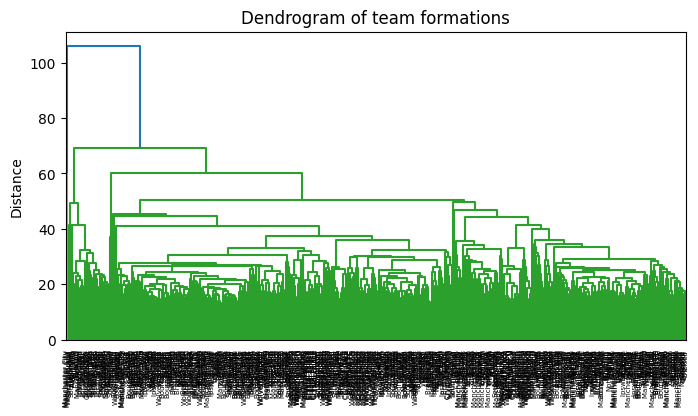

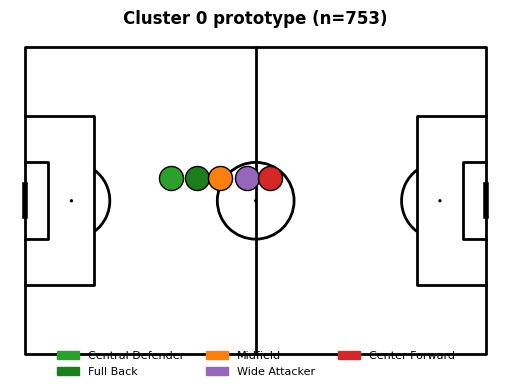

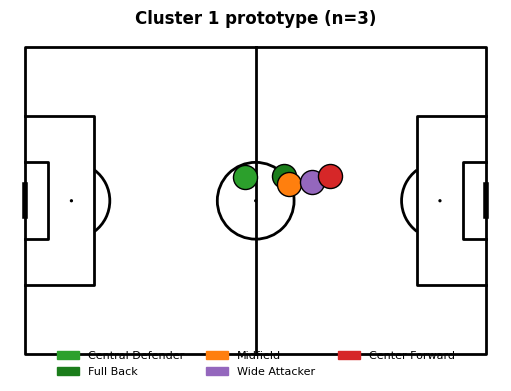

In [114]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from mplsoccer import Pitch
import matplotlib.patches as mpatches

# --- Dendrogram helper ---
def plot_dendrogram(D, samples, method="average"):
    """
    Plot dendrogram from precomputed distance matrix D.
    """
    # linkage needs condensed distance matrix
    from scipy.spatial.distance import squareform
    Z = linkage(squareform(D), method=method)
    plt.figure(figsize=(8, 4))
    dendrogram(Z, labels=[s["team_short"] for s in samples], leaf_rotation=90)
    plt.title("Dendrogram of team formations")
    plt.ylabel("Distance")
    plt.show()

# --- Cluster prototype helper ---
def _marginals_xy(H: np.ndarray):
    mx = H.sum(axis=1)
    my = H.sum(axis=0)
    return mx, my

def _bin_centers(edges: np.ndarray):
    return 0.5 * (edges[:-1] + edges[1:])

def _expected_xy(H, x_centers, y_centers):
    if H.sum() <= 0:
        return np.nan, np.nan
    mx, my = _marginals_xy(H)
    if mx.sum() > 0: mx = mx / mx.sum()
    if my.sum() > 0: my = my / my.sum()
    ex = float((mx * x_centers).sum())
    ey = float((my * y_centers).sum())
    return ex, ey

ROLE_COLORS = {
    "Central Defender": "#2ca02c",
    "Full Back":        "#1b7d1b",
    "Midfield":         "#ff7f0e",
    "Wide Attacker":    "#9467bd",
    "Center Forward":   "#d62728",
}

def plot_cluster_prototypes(samples, labels, n_clusters):
    """
    For each cluster, compute average role heatmaps → expected positions,
    and plot as prototype formation.
    """
    x_centers = _bin_centers(samples[0]["x_edges"])
    y_centers = _bin_centers(samples[0]["y_edges"])

    for cid in range(n_clusters):
        subset = [s for s in samples if labels[samples.index(s)] == cid]
        if not subset:
            continue

        # average role heatmaps
        mean_maps = {r: np.zeros((len(x_centers), len(y_centers)), dtype=float) for r in ROLES}
        for s in subset:
            for r in ROLES:
                mean_maps[r] += s["roles"][r]
        for r in ROLES:
            total = mean_maps[r].sum()
            if total > 0:
                mean_maps[r] /= total

        # expected positions
        role_points = []
        for r in ROLES:
            ex, ey = _expected_xy(mean_maps[r], x_centers, y_centers)
            role_points.append((r, ex, ey))

        # plot
        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        fig, ax = pitch.draw(figsize=(6, 4))

        for r, ex, ey in role_points:
            if np.isfinite(ex) and np.isfinite(ey):
                c = ROLE_COLORS.get(r, "#333333")
                pitch.scatter(ex, ey, s=300, c=c, edgecolors="black", ax=ax, zorder=3)

        handles = [mpatches.Patch(color=ROLE_COLORS.get(r, "#333333"), label=r) for r in ROLES]
        ax.legend(handles=handles, loc="lower center", ncol=3, fontsize=8, frameon=False,
                  bbox_to_anchor=(0.5, -0.05))

        ax.set_title(f"Cluster {cid} prototype (n={len(subset)})", fontsize=12, weight="bold")
        plt.show()

# === Example usage (with your 2 samples only) ===
# Dendrogram
plot_dendrogram(D, samples)

# Cluster prototypes (2 clusters here, since only 2 teams in the match)
plot_cluster_prototypes(samples, labels, n_clusters=2)


# 📌 Reminder — Preparing the Input for Step 4

Currently:
- `ROLEMAP_DIR` only contains `.npz` files for **1 match** → 2 team samples.
- Dendrogram looks trivial because there are only 2 points.

To get a useful dendrogram + cluster prototypes:
1. Loop over **all processed matches** in your league.  
2. For each match, run `build_and_save_role_heatmaps_for_match(match_id)`.  
3. This will fill `ROLEMAP_DIR` with one `.npz` file **per team per match**.  
   - Example: `1715920_12345.npz` (match id + team id).  

Once `ROLEMAP_DIR` has, say, 380 matches × 2 teams = 760 samples,  
the dendrogram will show rich branching, and cluster prototypes will reveal **formation archetypes**.


In [ ]:
# === Build role heatmaps for the whole league ===

# load all processed parquet files
processed_files = sorted(PROCESSED_DIR.glob("*.parquet"))

#for f in processed_files:
    #match_id = int(f.stem)
    #build_and_save_role_heatmaps_for_match(match_id)


💾 saved 1650385_31.npz (Manchester U) with 5 roles @ 24x16 bins
💾 saved 1650385_48.npz (Fulham) with 5 roles @ 24x16 bins
💾 saved 1650961_2.npz (Liverpool) with 5 roles @ 24x16 bins
💾 saved 1650961_752.npz (Ipswich Town) with 5 roles @ 24x16 bins
💾 saved 1651700_37.npz (West Ham) with 5 roles @ 24x16 bins
💾 saved 1651700_39.npz (Aston Villa) with 5 roles @ 24x16 bins
💾 saved 1651701_3.npz (Arsenal) with 5 roles @ 24x16 bins
💾 saved 1651701_52.npz (Wolverhampton) with 5 roles @ 24x16 bins
💾 saved 1651702_41.npz (Everton) with 5 roles @ 24x16 bins
💾 saved 1651702_308.npz (Brighton) with 5 roles @ 24x16 bins
💾 saved 1651703_32.npz (Newcastle) with 5 roles @ 24x16 bins
💾 saved 1651703_58.npz (Southampton) with 5 roles @ 24x16 bins
💾 saved 1653146_60.npz (Crystal Palace) with 5 roles @ 24x16 bins
💾 saved 1653146_754.npz (Brentford FC) with 5 roles @ 24x16 bins
💾 saved 1654741_40.npz (Manchester City) with 5 roles @ 24x16 bins
💾 saved 1654741_49.npz (Chelsea) with 5 roles @ 24x16 bins
💾 save

# ✅ Next
- After this loop, `ROLEMAP_DIR` will contain **all team–match samples**.  
- Then you can rerun **Step 4 (dendrogram + prototypes)** and it will finally show:
  - Many branches in the dendrogram.  
  - Cluster prototypes that look like **4-4-2, 4-2-3-1, 3-5-2, etc.**.  


# Step 4 — Visualize the Dendrogram and Cluster Prototypes (All Matches)

## 🌳 Dendrogram
- Shows how all team–match formations are related.  
- Each leaf = one team’s formation in one match.  
- Branch height = how different the formations are.  
- Cutting at a certain height (e.g. 6) gives formation clusters.

## 👥 Cluster Prototypes
- After clustering, we average role heatmaps across all samples in a cluster.  
- Then we plot the **expected x,y positions** of each role on the pitch.  
- This shows the typical “shape” of that cluster (e.g. 4-4-2, 4-2-3-1, etc.).  

## 📊 Workflow
1. Load all team–match `.npz` files from `ROLEMAP_DIR`.  
2. Build the **distance matrix** between all samples.  
3. Run **AgglomerativeClustering** with `metric="precomputed"`.  
4. Plot:
   - **Dendrogram** (can hide labels if too many).  
   - **Cluster prototypes** (league-level formation archetypes).  


📂 Loaded 756 samples (team–match formations)


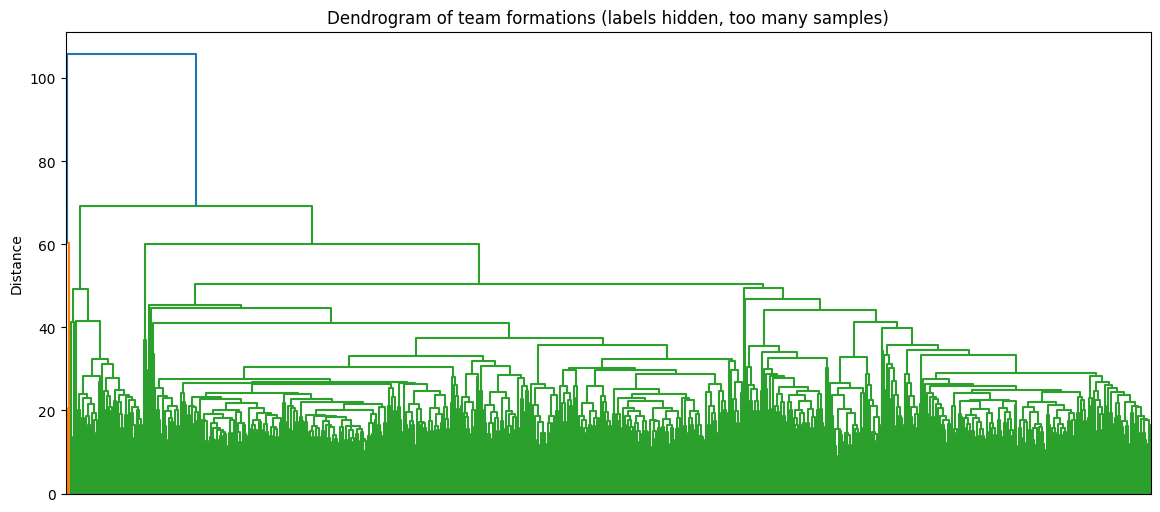

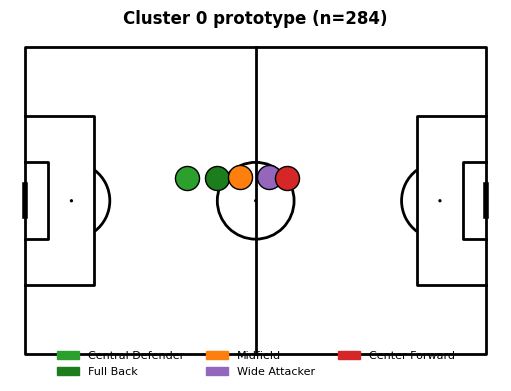

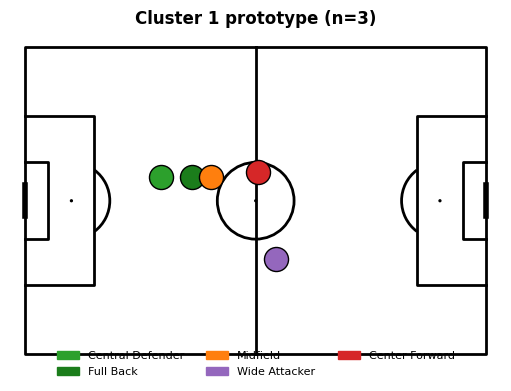

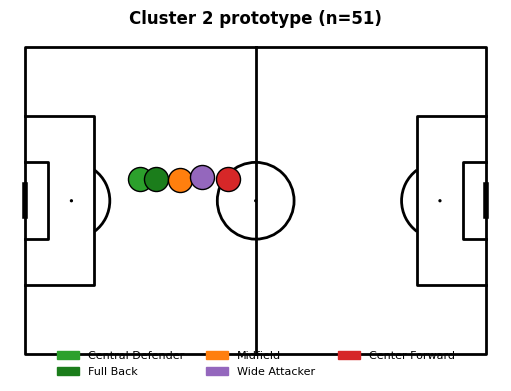

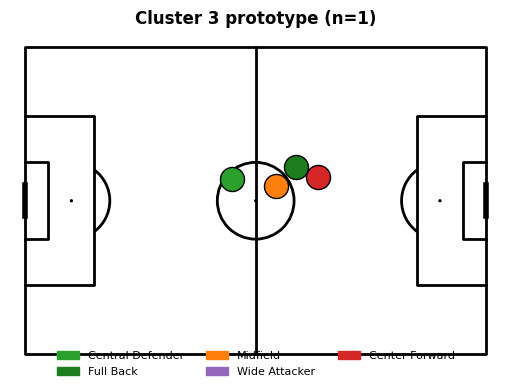

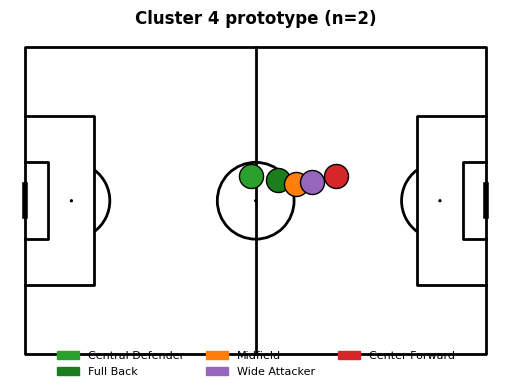

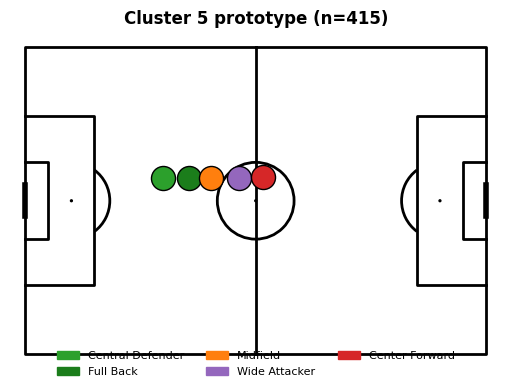

In [115]:
# === Step 4: Dendrogram and Cluster Prototypes ===

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mplsoccer import Pitch
import numpy as np

# 1) Load all samples (one per team per match)
files = sorted(ROLEMAP_DIR.glob("*.npz"))
samples = [load_sample_npz(str(f)) for f in files]
print(f"📂 Loaded {len(samples)} samples (team–match formations)")

# 2) Build distance matrix
D = build_distance_matrix(samples)

# 3) Run clustering (choose how many clusters you want)
n_clusters = 6
agg = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='average')
labels = agg.fit_predict(D)

# Attach cluster labels to samples
for s, lab in zip(samples, labels):
    s["cluster"] = int(lab)

# --- Dendrogram ---
def plot_dendrogram(D, samples, method="average", max_labels=50):
    Z = linkage(squareform(D), method=method)
    plt.figure(figsize=(14, 6))
    if len(samples) > max_labels:
        dendrogram(Z, no_labels=True, leaf_rotation=90, leaf_font_size=8)
        plt.title("Dendrogram of team formations (labels hidden, too many samples)")
    else:
        dendrogram(Z, labels=[f"{s['team_short']}-{s['match_id']}" for s in samples],
                   leaf_rotation=90, leaf_font_size=8)
        plt.title("Dendrogram of team formations")
    plt.ylabel("Distance")
    plt.show()

plot_dendrogram(D, samples)

# --- Cluster Prototypes ---
def _marginals_xy(H: np.ndarray):
    mx = H.sum(axis=1); my = H.sum(axis=0)
    return mx, my

def _bin_centers(edges: np.ndarray):
    return 0.5 * (edges[:-1] + edges[1:])

def _expected_xy(H, x_centers, y_centers):
    if H.sum() <= 0: return np.nan, np.nan
    mx, my = _marginals_xy(H)
    if mx.sum() > 0: mx = mx / mx.sum()
    if my.sum() > 0: my = my / my.sum()
    ex = float((mx * x_centers).sum())
    ey = float((my * y_centers).sum())
    return ex, ey

ROLE_COLORS = {
    "Central Defender": "#2ca02c",
    "Full Back":        "#1b7d1b",
    "Midfield":         "#ff7f0e",
    "Wide Attacker":    "#9467bd",
    "Center Forward":   "#d62728",
}

def plot_cluster_prototypes(samples, n_clusters):
    x_centers = _bin_centers(samples[0]["x_edges"])
    y_centers = _bin_centers(samples[0]["y_edges"])

    for cid in range(n_clusters):
        subset = [s for s in samples if s["cluster"] == cid]
        if not subset:
            continue

        # Average role heatmaps in this cluster
        mean_maps = {r: np.zeros((len(x_centers), len(y_centers)), dtype=float) for r in ROLES}
        for s in subset:
            for r in ROLES:
                mean_maps[r] += s["roles"][r]
        for r in ROLES:
            total = mean_maps[r].sum()
            if total > 0:
                mean_maps[r] /= total

        # Expected positions
        role_points = []
        for r in ROLES:
            ex, ey = _expected_xy(mean_maps[r], x_centers, y_centers)
            role_points.append((r, ex, ey))

        # Plot prototype
        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        fig, ax = pitch.draw(figsize=(6, 4))

        for r, ex, ey in role_points:
            if np.isfinite(ex) and np.isfinite(ey):
                c = ROLE_COLORS.get(r, "#333333")
                pitch.scatter(ex, ey, s=300, c=c, edgecolors="black", ax=ax, zorder=3)

        # Legend
        handles = [mpatches.Patch(color=ROLE_COLORS.get(r, "#333333"), label=r) for r in ROLES]
        ax.legend(handles=handles, loc="lower center", ncol=3, fontsize=8, frameon=False,
                  bbox_to_anchor=(0.5, -0.05))

        ax.set_title(f"Cluster {cid} prototype (n={len(subset)})", fontsize=12, weight="bold")
        plt.show()

plot_cluster_prototypes(samples, n_clusters=n_clusters)


# Step 5 — Per-Team Cluster Distribution

## 🎯 Goal
- After clustering, each sample (team–match formation) has a **cluster label**.  
- By grouping these labels per team, we can see:
  - Which formations (clusters) a team uses most often.  
  - How much they vary (stable vs flexible teams).  

## 📊 Method
1. Collect cluster assignments per `team_name`.  
2. Count how many times each cluster appears.  
3. Normalize to percentages → shows distribution across clusters.  
4. Visualize as a **stacked bar chart** (teams × cluster proportions).  

This tells us, for example:  
- Arsenal: 70% cluster 2 (4-2-3-1), 20% cluster 5 (3-4-3), 10% cluster 1.  
- Brentford: 60% cluster 1 (4-4-2), 40% cluster 3 (5-3-2).  


In [117]:
sample = samples[0]
print(sample.keys())


dict_keys(['match_id', 'team_id', 'team_short', 'x_edges', 'y_edges', 'roles', 'cluster'])


<Figure size 1000x600 with 0 Axes>

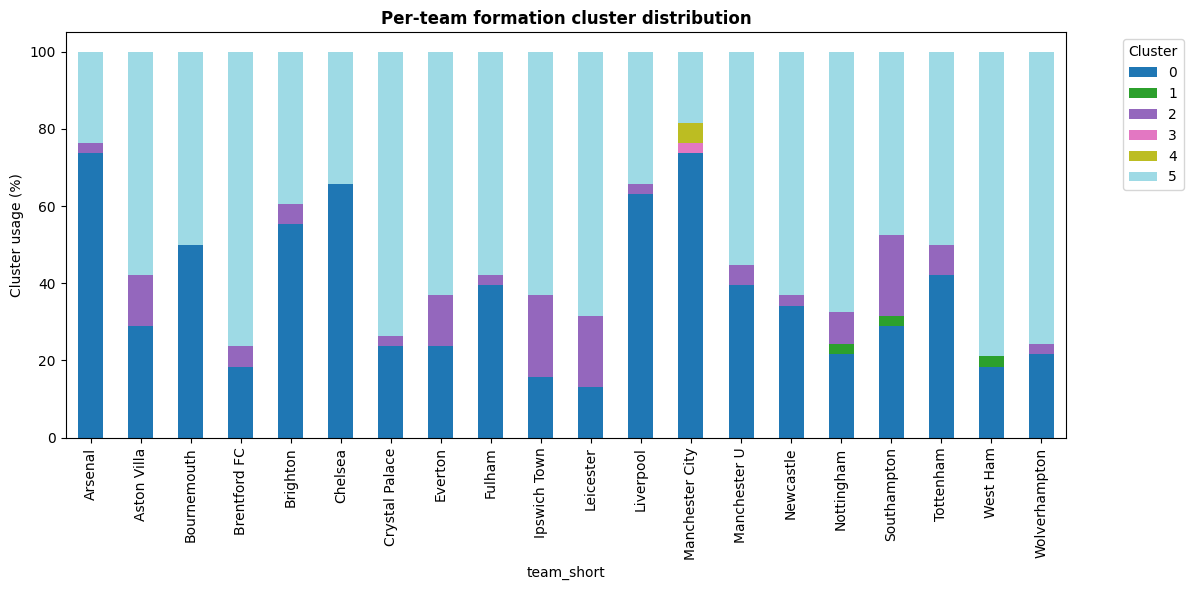

Arsenal formation distribution:
   team_short  cluster  count    percent
0    Arsenal        0     28  73.684211
1    Arsenal        2      1   2.631579
2    Arsenal        5      9  23.684211


In [125]:
import pandas as pd
import seaborn as sns

# 1) Build DataFrame of assignments
rows = []
for s in samples:
    rows.append({
        "match_id": s["match_id"],
        "team_id": s["team_id"],
        "team_short": s["team_short"],
        "team_short": s["team_short"],
        "cluster": s["cluster"],
    })
assign_df = pd.DataFrame(rows)

# 2) Count cluster usage per team
cluster_dist = (
    assign_df.groupby(["team_short", "cluster"])
             .size()
             .reset_index(name="count")
)

# 3) Normalize to percentages
cluster_dist["percent"] = cluster_dist.groupby("team_short")["count"].transform(
    lambda x: 100 * x / x.sum()
)

# 4) Pivot for visualization
pivot_df = cluster_dist.pivot(index="team_short", columns="cluster", values="percent").fillna(0)

# 5) Plot stacked bar chart
plt.figure(figsize=(10, 6))
pivot_df.plot(kind="bar", stacked=True, colormap="tab20", figsize=(12, 6))
plt.ylabel("Cluster usage (%)")
plt.title("Per-team formation cluster distribution", weight="bold")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Example: look at Arsenal specifically
arsenal_dist = cluster_dist[cluster_dist["team_short"] == "Arsenal"]
print("Arsenal formation distribution:\n", arsenal_dist)


# Step 6 — Interpreting Clusters as Tactical Formations

## 🧩 The problem
- Current prototypes use **role groups** (Central Defender, Midfield, etc.).
- That compresses several players into one dot (e.g. 4 defenders → 1 circle).
- You can’t distinguish between **4-4-2** vs **3-5-2**.

## 🎯 The solution
- Instead of plotting only role centroids, compute **player-level averages** inside each cluster.
- Approach:
  1. For each cluster, gather all frames from all samples assigned to that cluster.
  2. For each `player_id` (or consistent jersey/role index), compute their **average normalized x,y**.
  3. Plot those average positions → you’ll see 10 outfielders + 1 goalkeeper in shape.
- This way, clusters look like **actual team formations**: four in defense, four in midfield, two up top, etc.


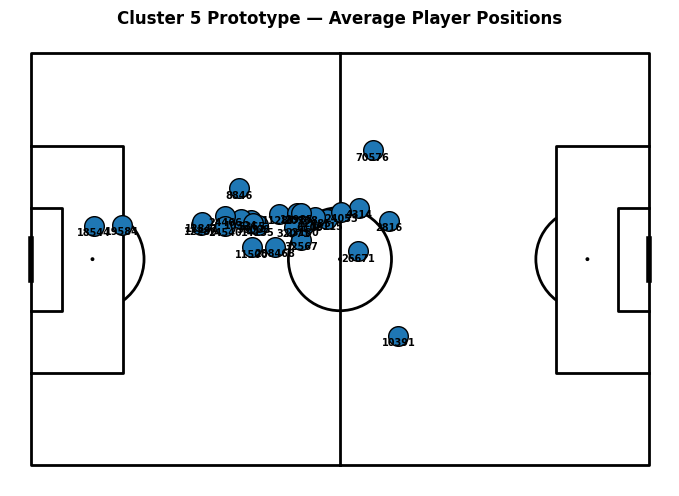

In [128]:
def plot_cluster_player_prototype(samples, cluster_id, tr_league, dot_size=200):
    """
    Plot the average 11-player formation for a given cluster.
    - samples: list of formation samples with cluster assignments
    - cluster_id: which cluster to visualize
    - tr_league: processed tracking dataframe for the league (with x_norm, y_norm, team_id, cluster)
    """

    subset = [s for s in samples if s["cluster"] == cluster_id]
    team_ids = [s["team_id"] for s in subset]
    match_ids = [s["match_id"] for s in subset]

    # filter tracking data belonging to those matches/teams
    sub_tr = tr_league[
        tr_league["match_id"].isin(match_ids) &
        tr_league["team_id"].isin(team_ids) &
        (~tr_league["is_ball"])
    ].copy()

    # average position per player_id
    avg_positions = (sub_tr.groupby("player_id")[["x_norm", "y_norm"]]
                              .mean()
                              .reset_index())

    # keep only players with enough detections
    avg_positions = avg_positions.dropna()

    # --- plot ---
    pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                  pitch_color='white', line_color='black')
    fig, ax = pitch.draw(figsize=(7, 5))

    pitch.scatter(avg_positions["x_norm"], avg_positions["y_norm"],
                  s=dot_size, c="#1f77b4", edgecolors="black", ax=ax, zorder=3)

    # label players
    for _, row in avg_positions.iterrows():
        ax.text(row["x_norm"], row["y_norm"]+2, str(int(row["player_id"])),
                ha="center", fontsize=7, weight="bold")

    ax.set_title(f"Cluster {cluster_id} Prototype — Average Player Positions", fontsize=12, weight="bold")
    plt.show()

# Example usage (after clustering done and samples assigned)
plot_cluster_player_prototype(samples, cluster_id=5, tr_league=tr_with_pos)


# Step 7 — Professional Visualization of Clustered Formations

## 🎯 Goal
- Show each cluster’s **formation archetype**.
- Background: all team–match mean role positions in that cluster (faded).
- Foreground: cluster’s **median/central formation** (bold, black).
- Title: cluster id + percentage of all samples → popularity indicator.

## 📊 Interpretation
- You’ll see clear tactical patterns:
  - 4 defenders in a line (4-4-2, 4-2-3-1).
  - 3 at the back (3-5-2, 3-4-3).
  - Striker count (1 vs 2 vs 3).  
- The % label tells you how common each formation type is across the league.


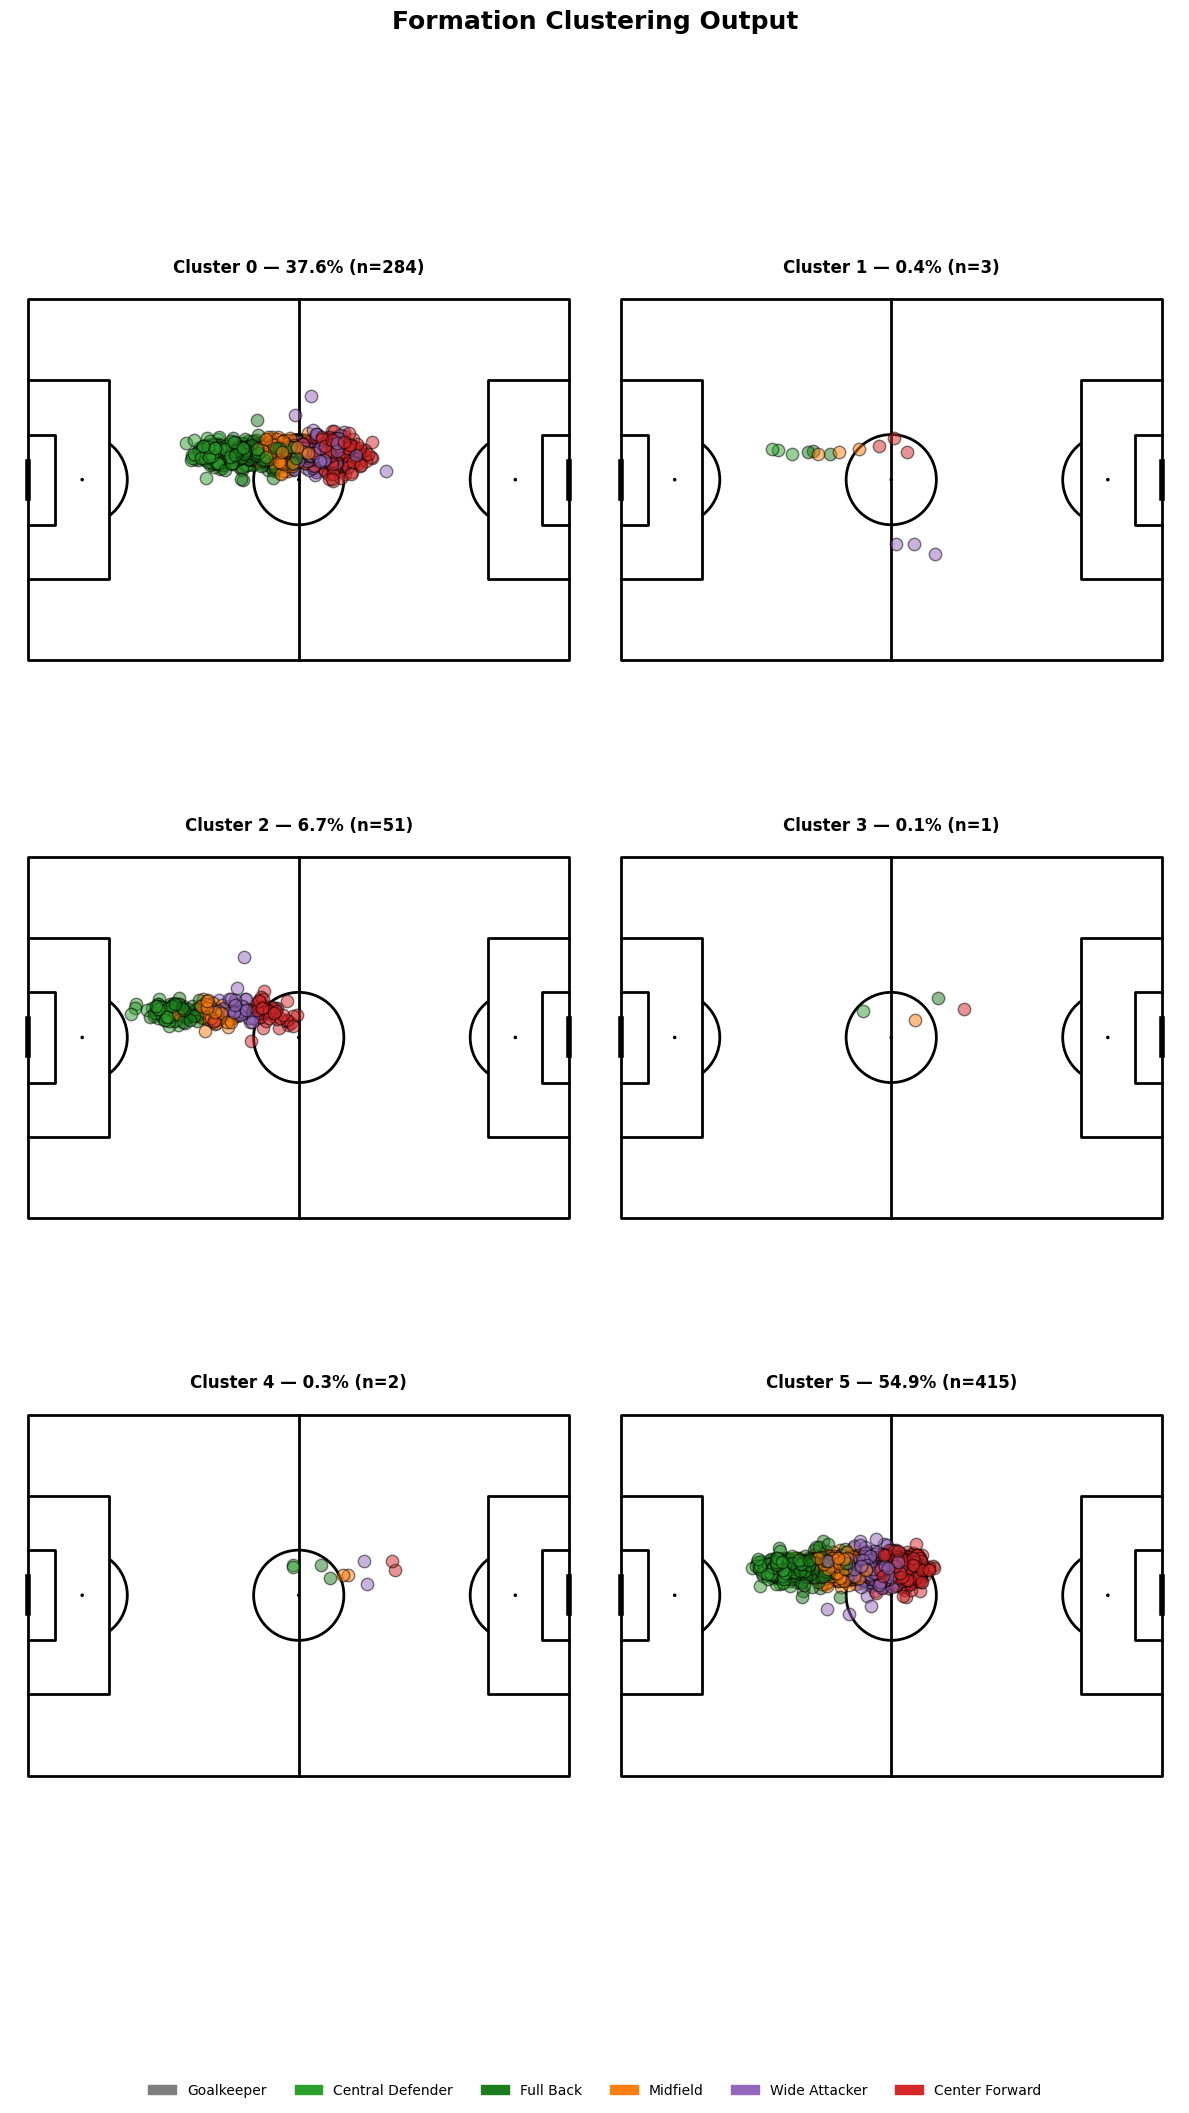

In [136]:
def plot_cluster_formations(samples, n_clusters, dot_size=80, alpha=0.5,
                            cols=3, figheight=6):
    """
    Plot all samples' role positions for each cluster.
    - Larger subplot pitches (controlled by cols & figheight)
    - One shared legend at bottom for role colors
    """
    x_centers = _bin_centers(samples[0]["x_edges"])
    y_centers = _bin_centers(samples[0]["y_edges"])

    # Arrange clusters into grid
    rows = int(np.ceil(n_clusters / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*figheight))
    axes = axes.flatten()

    for cid, ax in enumerate(axes):
        if cid >= n_clusters:
            ax.axis("off")
            continue

        subset = [s for s in samples if s["cluster"] == cid]
        if not subset:
            ax.axis("off")
            continue

        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        pitch.draw(ax=ax)

        # Scatter all role points from all samples in this cluster
        for s in subset:
            role_points = compute_expected_positions(s, x_centers, y_centers)
            for r, ex, ey in role_points:
                c = ROLE_COLORS.get(r, "#333333")
                pitch.scatter(ex, ey, s=dot_size, c=c, alpha=alpha,
                              edgecolors="black", ax=ax, zorder=3)

        # Title with popularity
        pct = 100 * len(subset) / len(samples)
        ax.set_title(f"Cluster {cid} — {pct:.1f}% (n={len(subset)})",
                     fontsize=12, weight="bold")

    # Create one shared legend (roles → colors)
    handles = [mpatches.Patch(color=ROLE_COLORS[r], label=r) for r in ROLE_COLORS]
    fig.legend(handles=handles, loc="lower center", ncol=len(ROLE_COLORS),
               fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle("Formation Clustering Output", fontsize=18, weight="bold")
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # leave space for legend + title
    plt.show()

# Example: larger plots with shared legend
plot_cluster_formations(samples, n_clusters=n_clusters, cols=2, figheight=7)




# Step 9 — Clustering Formations with KMeans / GMM

## 🎯 Goal
- Represent each team–match (or team–half) by **11 player average positions** (x,y).
- Cluster these 22-dimensional vectors (11 players × 2 coordinates).
- Use KMeans or GMM to discover typical formations:
  - **KMeans** → simpler, balanced partitions, good for coarse 4–6 clusters.
  - **GMM** → allows soft assignments (a team may mix between formations).

## 📊 Workflow
1. **Extract samples**
   - For each team in each match, compute average `x_norm, y_norm` for 11 players (exclude ball).
   - Flatten into one vector `[x1,y1,x2,y2,...,x11,y11]`.

2. **Cluster**
   - Apply KMeans or GMM with `n_clusters ~ 6–8`.
   - Each cluster = one typical formation.

3. **Visualize**
   - For each cluster, plot **all samples** (faded) + **cluster centroid** (bold).
   - Overlay role-colored dots.
   - Title = cluster id + inferred formation (e.g., 4-4-2) + frequency.

4. **Interpret**
   - Count players in defensive/middle/attacking thirds → auto-label as “4-4-2”, etc.
   - Report % usage league-wide.


In [140]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

def build_player_samples(tr_with_pos):
    """
    Create one sample per team–match: 11 average player positions.
    """
    samples = []
    grouped = tr_with_pos[~tr_with_pos["is_ball"]].groupby(["match_id","team_id"])
    for (match_id, team_id), df in grouped:
        avg = df.groupby("player_id")[["x_norm","y_norm"]].mean().dropna()
        if len(avg) < 10:  # filter out incomplete lineups
            continue
        vec = avg.values.flatten()[:22]  # 11 players × 2 coords
        if len(vec) == 22:
            samples.append({"match_id":match_id,"team_id":team_id,"vec":vec,"positions":avg})
    return samples

# Build samples
samples = build_player_samples(tr_with_pos)

# Prepare matrix
X = np.vstack([s["vec"] for s in samples])


n_clusters = min(6, len(samples))  # can’t exceed number of samples

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

for s, lab in zip(samples, labels):
    s["cluster"] = lab




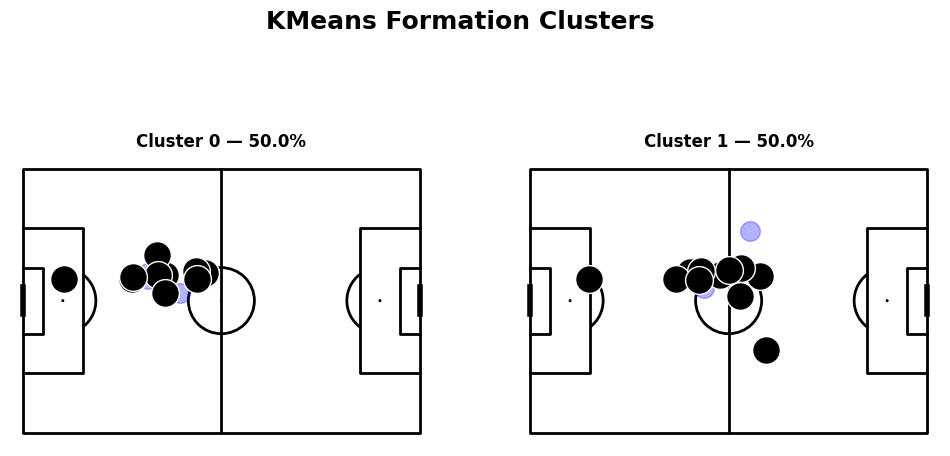

In [141]:
def plot_kmeans_formations(samples, kmeans, n_clusters, dot_size=200, alpha=0.3):
    fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 6))
    if n_clusters == 1:
        axes = [axes]

    for cid, ax in enumerate(axes):
        subset = [s for s in samples if s["cluster"] == cid]
        if not subset:
            ax.axis("off")
            continue

        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        pitch.draw(ax=ax)

        # Plot all samples (faded)
        for s in subset:
            xy = s["positions"].values
            pitch.scatter(xy[:,0], xy[:,1], s=dot_size, c="blue", alpha=alpha, ax=ax)

        # Plot centroid (bold black)
        centroid = kmeans.cluster_centers_[cid].reshape(-1,2)
        pitch.scatter(centroid[:,0], centroid[:,1], s=400, c="black", edgecolors="white", ax=ax, zorder=3)

        pct = 100 * len(subset) / len(samples)
        ax.set_title(f"Cluster {cid} — {pct:.1f}%", fontsize=12, weight="bold")

    plt.suptitle("KMeans Formation Clusters", fontsize=18, weight="bold")
    plt.show()

# Example
plot_kmeans_formations(samples, kmeans, n_clusters)


# Step 10 — Run KMeans on All Matches

## 🎯 Goal
- Loop through all processed match files in `PROCESSED_DIR`.
- Extract **one sample per team–match** (average positions of 11 players).
- Build a dataset of hundreds of samples across the season.
- Cluster using **KMeans (n_clusters=6–8)**.
- Visualize clusters → each subplot = one typical formation (4-4-2, 4-2-3-1, etc.).


In [142]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from mplsoccer import Pitch
import matplotlib.pyplot as plt

def build_league_samples(processed_dir):
    """
    Loop over all processed tracking files and extract one sample per team–match.
    Each sample = average x,y positions of 11 players (ball excluded).
    """
    samples = []
    files = list(Path(processed_dir).glob("*.parquet"))

    for f in files:
        df = pd.read_parquet(f)
        grouped = df[~df["is_ball"]].groupby(["match_id", "team_id"])
        for (match_id, team_id), g in grouped:
            avg = g.groupby("player_id")[["x_norm","y_norm"]].mean().dropna()
            if len(avg) < 10:  # skip incomplete teams
                continue
            vec = avg.values.flatten()[:22]  # 11 players × 2 coords
            if len(vec) == 22:
                samples.append({
                    "match_id": match_id,
                    "team_id": team_id,
                    "team_name": g["team_name"].iloc[0],
                    "vec": vec,
                    "positions": avg
                })
    print(f"✅ Built {len(samples)} samples from {len(files)} matches")
    return samples

# Example usage
samples = build_league_samples(PROCESSED_DIR)


✅ Built 756 samples from 378 matches


In [145]:
# Stack feature vectors
X = np.vstack([s["vec"] for s in samples])

# Choose number of clusters
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# Attach cluster labels back
for s, lab in zip(samples, labels):
    s["cluster"] = lab


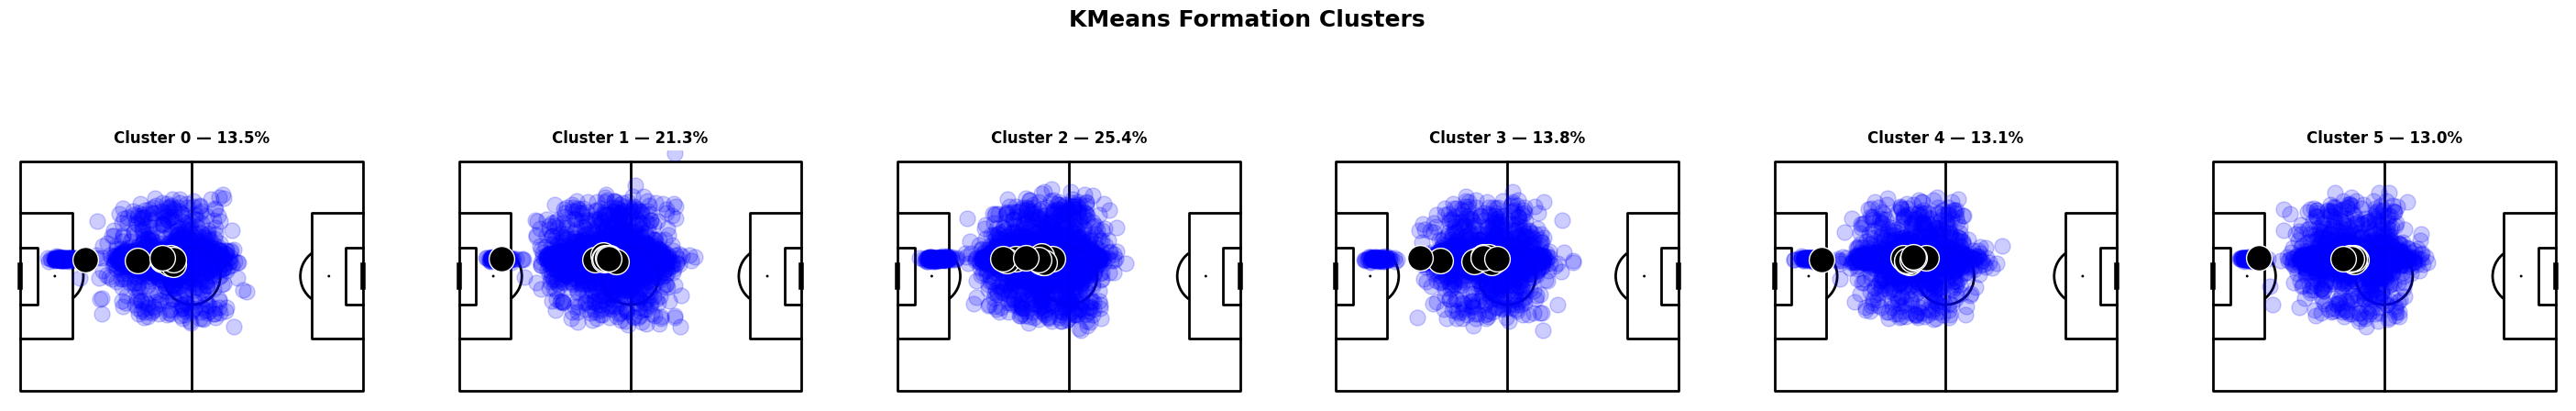

In [146]:
def plot_kmeans_formations(samples, kmeans, n_clusters, dot_size=150, alpha=0.2):
    fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 6))
    if n_clusters == 1:
        axes = [axes]

    for cid, ax in enumerate(axes):
        subset = [s for s in samples if s["cluster"] == cid]
        if not subset:
            ax.axis("off")
            continue

        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        pitch.draw(ax=ax)

        # Plot all samples (faded blue)
        for s in subset:
            xy = s["positions"].values
            pitch.scatter(xy[:,0], xy[:,1], s=dot_size, c="blue", alpha=alpha, ax=ax)

        # Plot cluster centroid (bold black)
        centroid = kmeans.cluster_centers_[cid].reshape(-1,2)
        pitch.scatter(centroid[:,0], centroid[:,1], s=400, c="black",
                      edgecolors="white", ax=ax, zorder=3)

        # Popularity
        pct = 100 * len(subset) / len(samples)
        ax.set_title(f"Cluster {cid} — {pct:.1f}%", fontsize=12, weight="bold")

    plt.suptitle("KMeans Formation Clusters", fontsize=18, weight="bold")
    plt.show()

# Example usage
plot_kmeans_formations(samples, kmeans, n_clusters)


In [152]:
from sklearn.cluster import KMeans

def infer_formation_label(centroid, n_lines=3):
    """
    Infer a formation label (e.g., 4-4-2) by clustering players along x-axis.
    centroid: (11,2) array with [x,y].
    n_lines: expected number of tactical lines (def/mid/att).
    """
    X = centroid[:, 0].reshape(-1,1)  # only x-axis
    km = KMeans(n_clusters=n_lines, random_state=0, n_init=10).fit(X)
    labels = km.labels_

    # Count players in each line (sorted from defense → attack)
    counts = []
    for line in np.argsort(km.cluster_centers_.ravel()):
        counts.append((labels == line).sum())

    return "-".join(map(str, counts))


In [153]:
centroid = kmeans.cluster_centers_[cid].reshape(-1,2)
formation_label = infer_formation_label(centroid)

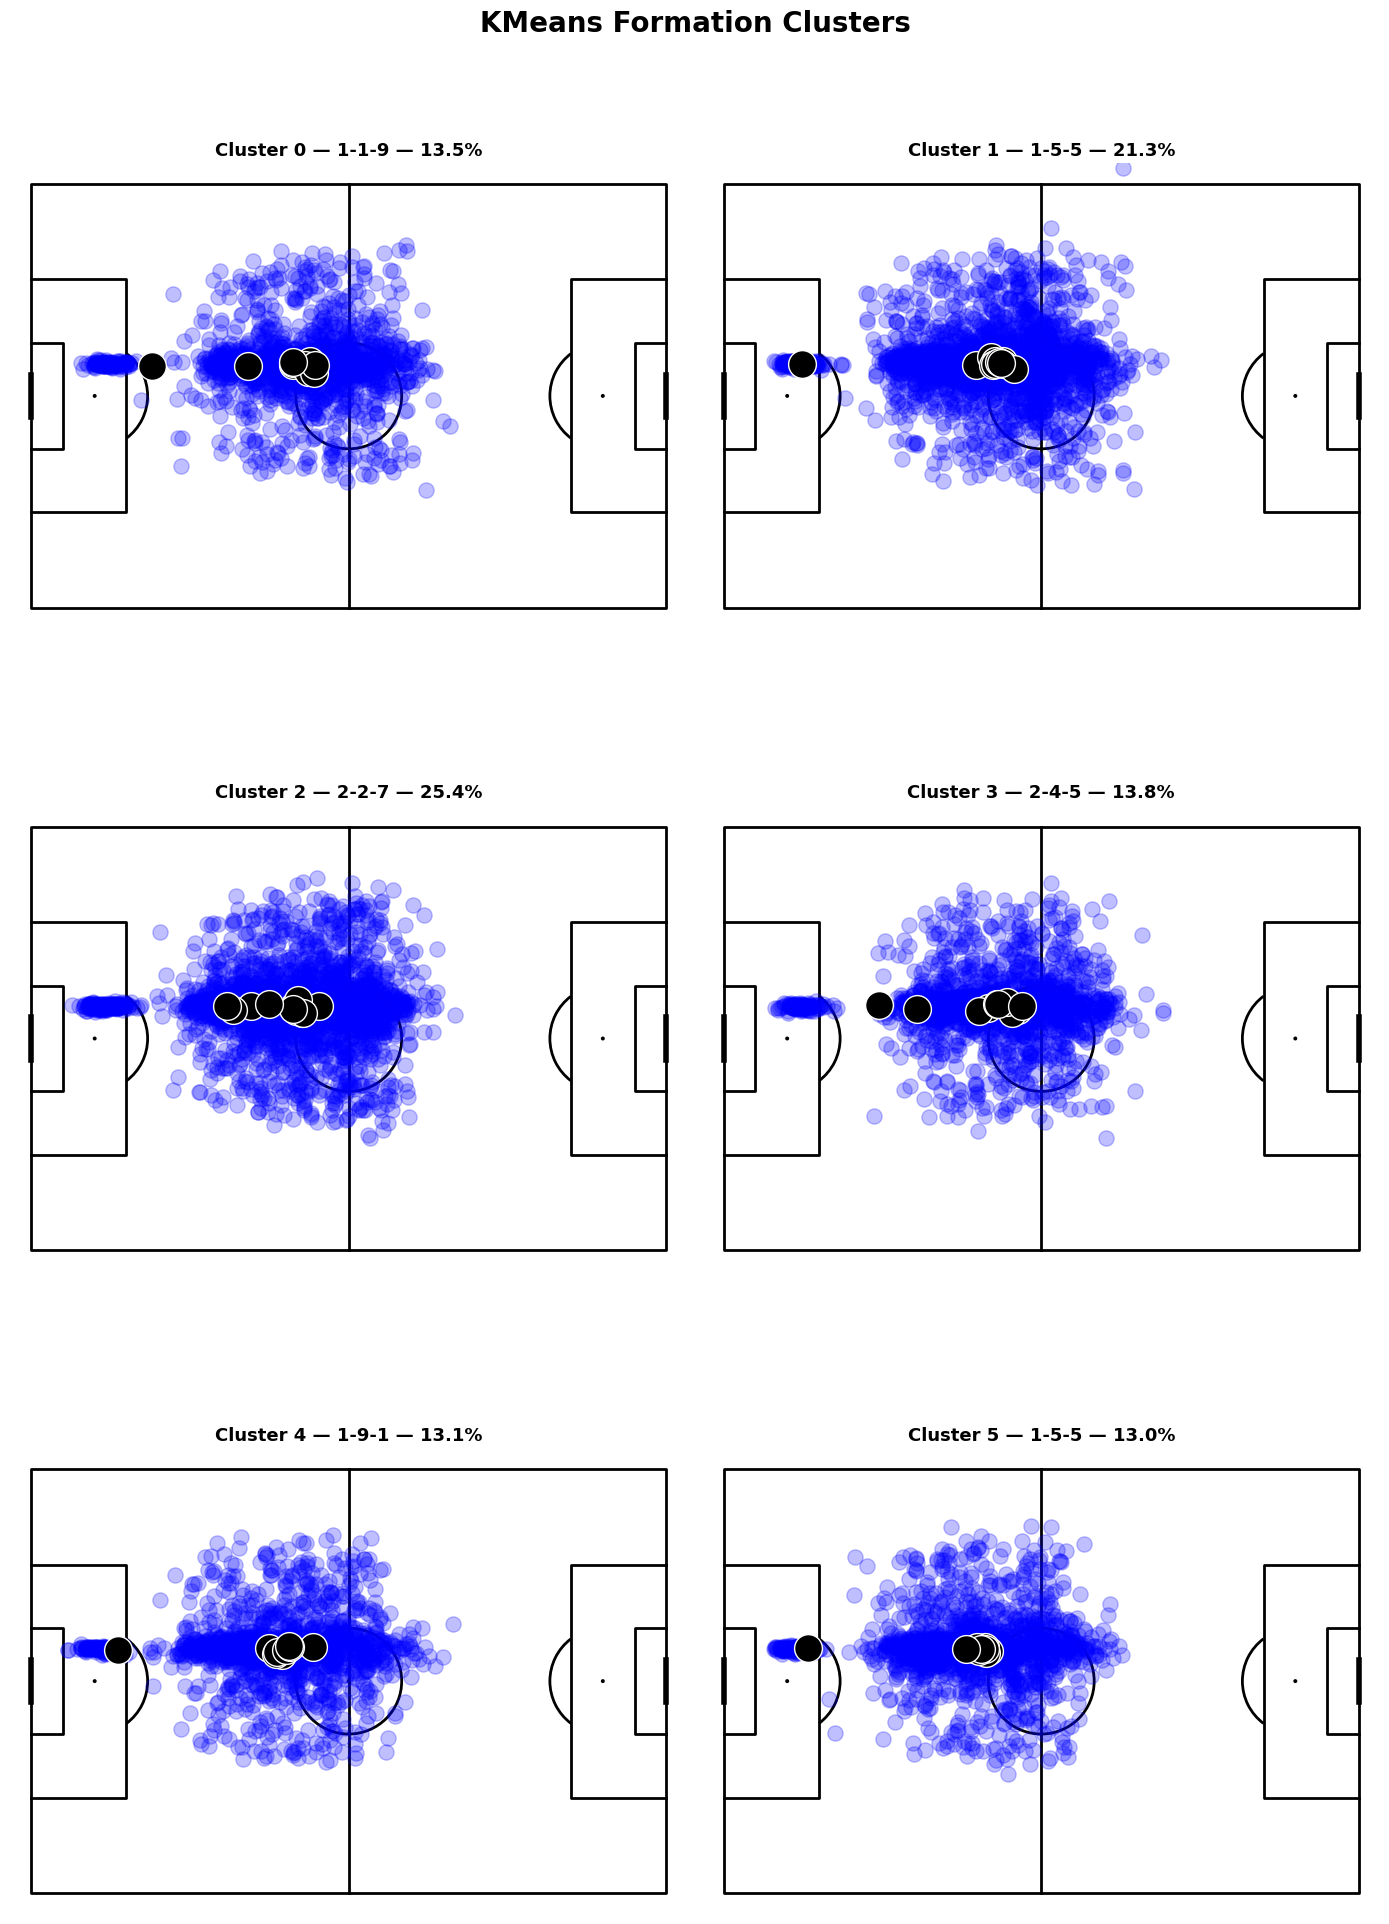

In [154]:
def plot_kmeans_formations(samples, kmeans, n_clusters, dot_size=120, alpha=0.25, cols=3):
    rows = int(np.ceil(n_clusters / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*7, rows*7))
    axes = axes.flatten()

    for cid, ax in enumerate(axes):
        if cid >= n_clusters:
            ax.axis("off")
            continue

        subset = [s for s in samples if s["cluster"] == cid]
        if not subset:
            ax.axis("off")
            continue

        pitch = Pitch(pitch_type='statsbomb', pitch_length=105, pitch_width=68,
                      pitch_color='white', line_color='black')
        pitch.draw(ax=ax)

        # Plot all samples (faded blue)
        for s in subset:
            xy = s["positions"].values
            pitch.scatter(xy[:,0], xy[:,1], s=dot_size, c="blue", alpha=alpha, ax=ax)

        # Cluster centroid (bold black)
        centroid = kmeans.cluster_centers_[cid].reshape(-1,2)
        pitch.scatter(centroid[:,0], centroid[:,1], s=400, c="black",
                      edgecolors="white", ax=ax, zorder=3)

        # Auto formation label
        formation_label = infer_formation_label(centroid)

        # Popularity
        pct = 100 * len(subset) / len(samples)
        ax.set_title(f"Cluster {cid} — {formation_label} — {pct:.1f}%", fontsize=13, weight="bold")

    plt.suptitle("KMeans Formation Clusters", fontsize=20, weight="bold")
    plt.tight_layout()
    plt.show()

# Example usage
plot_kmeans_formations(samples, kmeans, n_clusters, cols=2)
